# Drone-Anomaly-Detection-JEPA • Colab GPU Runner

This notebook sets up GPU compute and runs the project end-to-end:
- validates GPU/CUDA readiness,
- wires your dataset into the expected project path,
- preprocesses data,
- smoke-tests model forward pass,
- and provides optional training/evaluation runs.

> Re-run safe: cells are written to be idempotent where possible.

In [4]:
# 1) Import Required Libraries
from pathlib import Path
import os
import sys
import json
import time
import subprocess
import platform
import shutil

import numpy as np

# Optional GPU libs: load if installed
try:
    import torch
except Exception:
    torch = None

try:
    import tensorflow as tf
except Exception:
    tf = None

try:
    import cupy as cp
except Exception:
    cp = None

print(f"Python: {sys.version.split()[0]} | Platform: {platform.platform()}")
print(f"NumPy: {np.__version__}")
print(f"PyTorch: {getattr(torch, '__version__', 'not installed')}")
print(f"TensorFlow: {getattr(tf, '__version__', 'not installed')}")
print(f"CuPy: {getattr(cp, '__version__', 'not installed')}")

Python: 3.12.13 | Platform: Linux-6.6.113+-x86_64-with-glibc2.35
NumPy: 2.0.2
PyTorch: 2.10.0+cu128
TensorFlow: 2.19.0
CuPy: 14.0.1


In [2]:
# 2) Check GPU Availability
IN_COLAB = 'google.colab' in sys.modules
print(f"Running in Colab: {IN_COLAB}")

if torch is not None:
    print("\n[PyTorch GPU]")
    print(f"CUDA available: {torch.cuda.is_available()}")
    if torch.cuda.is_available():
        print(f"GPU count: {torch.cuda.device_count()}")
        for idx in range(torch.cuda.device_count()):
            print(f"- {idx}: {torch.cuda.get_device_name(idx)}")

if tf is not None:
    print("\n[TensorFlow GPU]")
    gpus = tf.config.list_physical_devices('GPU')
    print(f"Detected GPUs: {len(gpus)}")
    for gpu in gpus:
        print(f"- {gpu}")

if cp is not None:
    print("\n[CuPy GPU]")
    try:
        ndev = cp.cuda.runtime.getDeviceCount()
        print(f"Detected GPUs: {ndev}")
    except Exception as exc:
        print(f"CuPy runtime check failed: {exc}")

Running in Colab: True

[PyTorch GPU]
CUDA available: True
GPU count: 1
- 0: NVIDIA A100-SXM4-40GB

[TensorFlow GPU]
Detected GPUs: 1
- PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')

[CuPy GPU]
Detected GPUs: 1


In [3]:
# 3) Verify CUDA and cuDNN Installation
import re


def _run_shell(cmd: str):
    try:
        out = subprocess.run(cmd, shell=True, check=False, capture_output=True, text=True)
        return out.returncode, out.stdout.strip(), out.stderr.strip()
    except Exception as exc:
        return 1, "", str(exc)

for cmd in ["nvidia-smi", "nvcc --version"]:
    code, out, err = _run_shell(cmd)
    print(f"$ {cmd} -> exit={code}")
    if out:
        print(out[:2000])
    if err:
        print(err[:1000])
    print("-" * 60)

if torch is not None:
    print(f"torch.version.cuda: {torch.version.cuda}")
    print(f"torch.backends.cudnn.version(): {torch.backends.cudnn.version()}")
    print(f"torch.backends.cudnn.enabled: {torch.backends.cudnn.enabled}")

if tf is not None:
    build_info = tf.sysconfig.get_build_info() if hasattr(tf.sysconfig, 'get_build_info') else {}
    print("TensorFlow build CUDA:", build_info.get('cuda_version', 'unknown'))
    print("TensorFlow build cuDNN:", build_info.get('cudnn_version', 'unknown'))

$ nvidia-smi -> exit=0
Tue Apr 21 16:13:35 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   32C    P0             44W /  400W |       6MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+------------------------

In [4]:
# 4) Configure GPU Memory Growth
if tf is not None:
    try:
        gpus = tf.config.list_physical_devices('GPU')
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"Enabled TF memory growth on {len(gpus)} GPU(s).")
    except Exception as exc:
        print(f"Could not set TensorFlow memory growth: {exc}")

if torch is not None and torch.cuda.is_available():
    try:
        torch.backends.cudnn.benchmark = True
        print("PyTorch cuDNN benchmark enabled.")
    except Exception as exc:
        print(f"Could not tune PyTorch backend: {exc}")

Enabled TF memory growth on 1 GPU(s).
PyTorch cuDNN benchmark enabled.


In [2]:
# 5) Project Parameters + Runtime Path Setup
import os
from pathlib import Path

REPO_URL = "https://github.com/yaswanthreddyyyr/Drone-Anomaly-Detection-JEPA.git"
DATASET_NAME = "drone_temparing_dataset_v2"
DRIVE_FOLDER_URL = "https://drive.google.com/drive/folders/1J3cFdI5XqaG6svU2BfPBN2RBro6q0oRT"
IN_COLAB = False

try:
    from google.colab import drive  # noqa: F401
    IN_COLAB = True
    PROJECT_DIR = Path("/content/Drone-Anomaly-Detection-JEPA")
    DATASET_ROOT = Path(f"/content/{DATASET_NAME}")
    print("✅ Google Colab detected — Drive download enabled.")
except Exception:
    PROJECT_DIR = Path(os.getcwd()).resolve()
    DATASET_ROOT = PROJECT_DIR / DATASET_NAME
    print(f"✅ Local environment detected — path: {DATASET_ROOT}")

USE_DRIVE = IN_COLAB
EPOCHS_SMOKE = 2
BATCH_SIZE_SMOKE = 128
DEVICE_OVERRIDE = "auto"  # auto|cuda|cpu|mps

RUN_SMOKE_TRAIN = False
RUN_FULL_PIPELINE = False

# Create all required project directories
PROJECT_DIR.mkdir(parents=True, exist_ok=True)
(PROJECT_DIR / "data").mkdir(parents=True, exist_ok=True)
(PROJECT_DIR / "outputs").mkdir(parents=True, exist_ok=True)
(PROJECT_DIR / "smoke_outputs").mkdir(parents=True, exist_ok=True)
print("✅ Project directories ready.")
print(f"Project dir: {PROJECT_DIR}")
print(f"Dataset root: {DATASET_ROOT}")

✅ Google Colab detected — Drive download enabled.
✅ Project directories ready.
Project dir: /content/Drone-Anomaly-Detection-JEPA
Dataset root: /content/drone_temparing_dataset_v2


In [5]:
# 6) Clone/Open Repo + Install Dependencies

def run(cmd: str, cwd: Path | None = None):
    print(f"\n$ {cmd}")
    result = subprocess.run(
        cmd,
        shell=True,
        cwd=str(cwd) if cwd else None,
        check=False,
        text=True,
        capture_output=True,
    )
    if result.stdout:
        print(result.stdout[-4000:])
    if result.returncode != 0 and result.stderr:
        print(result.stderr[-4000:])
    if result.returncode != 0:
        raise RuntimeError(f"Command failed ({result.returncode}): {cmd}")

safe_cwd = Path("/content") if "google.colab" in sys.modules else Path.home()
safe_cwd.mkdir(parents=True, exist_ok=True)
os.chdir(safe_cwd)
print(f"Safe cwd: {Path.cwd()}")

repo_ready = (PROJECT_DIR / ".git").exists() and (PROJECT_DIR / "requirements.txt").exists()

if not repo_ready:
    if PROJECT_DIR.exists():
        shutil.rmtree(PROJECT_DIR)
    run(f"git clone {REPO_URL} {PROJECT_DIR}", cwd=safe_cwd)
else:
    print(f"Repo already exists: {PROJECT_DIR}")

os.chdir(PROJECT_DIR)
print(f"Working directory: {Path.cwd()}")

run("python -m pip install --upgrade pip", cwd=PROJECT_DIR)
run("pip install -r requirements.txt", cwd=PROJECT_DIR)
run("pip install pyyaml tqdm scikit-learn gdown", cwd=PROJECT_DIR)

Safe cwd: /content

$ git clone https://github.com/yaswanthreddyyyr/Drone-Anomaly-Detection-JEPA.git /content/Drone-Anomaly-Detection-JEPA
Working directory: /content/Drone-Anomaly-Detection-JEPA

$ python -m pip install --upgrade pip
Working directory: /content/Drone-Anomaly-Detection-JEPA

$ python -m pip install --upgrade pip
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 81.1 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2


$ pip install -r requirements.txt
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 81.1 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2


$ pip install -r requirements.txt
ages (from jupyterlab->jupyter>=1.0.0->-r requirements.txt (line 20)) (0.28.1)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 625.7/625.7 kB 39.1 MB/s  0:00:00


In [10]:
# 6.5) Restore raw dataset into /content (Colab)
from pathlib import Path
import shutil
import os

try:
    import gdown
except Exception:
    gdown = None

print("=" * 100)
print("RESTORE RAW DATASET")
print("=" * 100)

raw_target = PROJECT_DIR / "data" / DATASET_NAME
raw_target.parent.mkdir(parents=True, exist_ok=True)
raw_target.mkdir(parents=True, exist_ok=True)

# First, try local workspace fallback if available inside Colab mount.
local_candidates = [
    Path("/content/Drone-Anomaly-Detection-JEPA/data") / DATASET_NAME,
    Path("/content/data") / DATASET_NAME,
    Path("/content") / DATASET_NAME,
]
for candidate in local_candidates:
    if candidate.exists() and any(candidate.iterdir()):
        print(f"Using existing local candidate: {candidate}")
        if raw_target.exists() and not any(raw_target.iterdir()):
            shutil.copytree(candidate, raw_target, dirs_exist_ok=True)
        break

# If still empty, download from Drive folder.
if not any(raw_target.iterdir()):
    if gdown is None:
        raise RuntimeError("gdown is unavailable; cannot download dataset.")
    download_dir = Path("/content/shared_dataset_download")
    download_dir.mkdir(parents=True, exist_ok=True)
    print(f"Downloading drive folder to: {download_dir}")
    gdown.download_folder(url=DRIVE_FOLDER_URL, output=str(download_dir), quiet=False, use_cookies=False)

    # Search for the dataset folder or any zip inside the download tree.
    found_dataset = None
    found_zip = None
    zip_candidates = []
    for root in [download_dir] + list(download_dir.iterdir()):
        if root.is_dir():
            for p in root.rglob("*"):
                if p.is_dir() and p.name == DATASET_NAME:
                    found_dataset = p
                    break
                if p.is_file() and p.suffix.lower() == ".zip":
                    zip_candidates.append(p)
            if found_dataset:
                break
        elif root.is_file() and root.suffix.lower() == ".zip":
            zip_candidates.append(root)

    if zip_candidates and found_dataset is None:
        # Prefer a zip that looks like the dataset archive, otherwise take the first one.
        zip_candidates = sorted(zip_candidates, key=lambda p: (DATASET_NAME not in p.name, len(p.name)))
        found_zip = zip_candidates[0]

    if found_dataset is not None:
        print(f"Found dataset folder: {found_dataset}")
        shutil.copytree(found_dataset, raw_target, dirs_exist_ok=True)
    elif found_zip is not None:
        import zipfile
        print(f"Found dataset zip: {found_zip}")
        extract_base = raw_target.parent / f"_{DATASET_NAME}_extract"
        if extract_base.exists():
            shutil.rmtree(extract_base)
        extract_base.mkdir(parents=True, exist_ok=True)
        with zipfile.ZipFile(found_zip, "r") as zf:
            zf.extractall(extract_base)

        # Move extracted dataset folder contents into raw_target.
        extracted_dirs = [p for p in extract_base.iterdir() if p.is_dir()]
        source_dir = None
        for p in extracted_dirs:
            if p.name == DATASET_NAME or (p / "balanced").exists():
                source_dir = p
                break
        if source_dir is None and extracted_dirs:
            source_dir = extracted_dirs[0]

        if source_dir is None:
            # Maybe files were extracted directly.
            for item in extract_base.iterdir():
                shutil.move(str(item), raw_target)
        else:
            for item in source_dir.iterdir():
                shutil.move(str(item), raw_target)
        shutil.rmtree(extract_base)
    else:
        raise RuntimeError("Could not locate the raw dataset folder or zip after download.")

# If the dataset was extracted into a nested directory, normalize it.
if not any(raw_target.iterdir()):
    raise RuntimeError(f"Dataset restore failed: {raw_target} is still empty")

# Try to flatten a single nested folder when needed.
entries = list(raw_target.iterdir())
if len(entries) == 1 and entries[0].is_dir() and (entries[0] / "balanced").exists():
    nested = entries[0]
    tmp = raw_target.parent / f"_{DATASET_NAME}_tmp"
    if tmp.exists():
        shutil.rmtree(tmp)
    nested.rename(tmp)
    for child in tmp.iterdir():
        shutil.move(str(child), raw_target)
    shutil.rmtree(tmp)

os.environ["DATASET_DIR"] = str(raw_target)
print(f"Dataset restored at: {raw_target}")
print(f"Contents sample: {[p.name for p in list(raw_target.iterdir())[:10]]}")

RESTORE RAW DATASET


Retrieving folder contents


Processing file 1eFA-8ezTd-akwgAfLKm58dcWyDywu8qv .DS_Store
Processing file 1pipdzQCLMdI13Xx5CKk00ZcrRYzj5uNC DATASET_SUMMARY.md
Processing file 1pVBf_E54NHvRpmEwKDHO2ijNuOOOM6BI drone-telemetry-tampering-dataset-v2.zip


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1eFA-8ezTd-akwgAfLKm58dcWyDywu8qv
To: /content/shared_dataset_download/.DS_Store
100%|██████████| 6.15k/6.15k [00:00<00:00, 11.6MB/s]
Downloading...
From: https://drive.google.com/uc?id=1pipdzQCLMdI13Xx5CKk00ZcrRYzj5uNC
To: /content/shared_dataset_download/DATASET_SUMMARY.md
100%|██████████| 3.95k/3.95k [00:00<00:00, 17.1MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1pVBf_E54NHvRpmEwKDHO2ijNuOOOM6BI
From (redirected): https://drive.google.com/uc?id=1pVBf_E54NHvRpmEwKDHO2ijNuOOOM6BI&confirm=t&uuid=0b5fe696-5ce8-4842-98e2-824baa77db25
To: /content/shared_dataset_download/drone-telemetry-tampering-dataset-v2.zip
100%|██████████| 695M/695M [00:10<00:00, 67.3MB/s] 
Download completed


Found dataset zip: /content/shared_dataset_download/drone-telemetry-tampering-dataset-v2.zip
Dataset restored at: /content/Drone-Anomaly-Detection-JEPA/data/drone_temparing_dataset_v2
Contents sample: ['subtle', 'tampering_research_dataset_pack.csv', 'dataset_pack_meta.json', 'balanced', 'cases_index_pack.json', 'strong']


In [7]:
import os
os.environ["DATASET_DIR"] = "/full/path/to/drone_temparing_dataset_v2"

In [8]:
# 7) Dataset Wiring (Colab/local friendly)
from pathlib import Path
import os
import zipfile

TARGET_DATA_DIR = PROJECT_DIR / "data" / DATASET_NAME
TARGET_DATA_DIR.parent.mkdir(parents=True, exist_ok=True)

print(f"Kernel cwd: {Path.cwd()}")
print(f"PROJECT_DIR: {PROJECT_DIR}")
print(f"Dataset root: {DATASET_ROOT}")

candidates = [
    DATASET_ROOT,
    PROJECT_DIR / DATASET_NAME,
    PROJECT_DIR / "data" / DATASET_NAME,
    Path(os.environ.get("DATASET_DIR", "")) if os.environ.get("DATASET_DIR") else None,
    Path(os.environ.get("DRONE_DATASET_DIR", "")) if os.environ.get("DRONE_DATASET_DIR") else None,
]

# Add common local fallbacks.
for base in [PROJECT_DIR, Path.cwd(), Path.home()]:
    candidates.extend([
        base / DATASET_NAME,
        base / "data" / DATASET_NAME,
    ])

# Remove empty placeholders and duplicates.
filtered = []
seen = set()
for candidate in candidates:
    if candidate is None:
        continue
    candidate = Path(candidate)
    key = str(candidate)
    if key in seen:
        continue
    seen.add(key)
    filtered.append(candidate)

source_dataset = None
checked = []
for candidate in filtered:
    checked.append(str(candidate))
    if candidate.exists():
        source_dataset = candidate
        break

print("Checked dataset paths:")
for item in checked:
    print(" -", item)

if source_dataset is None and IN_COLAB:
    print("\nNo local dataset found. Downloading from shared Drive folder...")
    try:
        import gdown
        download_dir = Path("/content/shared_dataset_download")
        download_dir.mkdir(parents=True, exist_ok=True)
        gdown.download_folder(url=DRIVE_FOLDER_URL, output=str(download_dir), quiet=False, use_cookies=False)

        # Look for a dataset folder or zip in the downloaded contents.
        search_roots = [download_dir] + list(download_dir.iterdir())
        found = None
        for root in search_roots:
            if root.is_dir():
                for candidate in [root / DATASET_NAME, root / "data" / DATASET_NAME]:
                    if candidate.exists():
                        found = candidate
                        break
                if found is not None:
                    break
            if root.is_file() and root.suffix.lower() == ".zip":
                extract_dir = Path("/content") / "extracted_dataset"
                extract_dir.mkdir(parents=True, exist_ok=True)
                with zipfile.ZipFile(root, "r") as zf:
                    zf.extractall(extract_dir)
                for candidate in [
                    extract_dir / DATASET_NAME,
                    extract_dir / "data" / DATASET_NAME,
                    extract_dir / root.stem,
                    extract_dir / "data" / root.stem,
                ]:
                    if candidate.exists():
                        found = candidate
                        break
                if found is not None:
                    break
        source_dataset = found
        if source_dataset is not None:
            print(f"Downloaded dataset source: {source_dataset}")
    except Exception as exc:
        print(f"Drive folder download failed: {exc}")

if source_dataset is None:
    if IN_COLAB:
        raise FileNotFoundError(
            "Dataset not found locally and Drive folder download did not produce a usable dataset. "
            "Check that the shared folder contains the ZIP or extracted dataset folder named `drone_temparing_dataset_v2`."
        )
    raise FileNotFoundError(
        f"Dataset not found at {DATASET_ROOT} or local fallbacks. Put the folder next to the notebook or set DATASET_DIR."
    )

if TARGET_DATA_DIR.exists() and TARGET_DATA_DIR.is_symlink():
    if TARGET_DATA_DIR.resolve() != source_dataset.resolve():
        TARGET_DATA_DIR.unlink()

if not TARGET_DATA_DIR.exists():
    try:
        TARGET_DATA_DIR.symlink_to(source_dataset)
        print(f"Symlinked dataset: {TARGET_DATA_DIR} -> {source_dataset}")
    except Exception:
        print("Symlink failed; copying dataset (may take time)...")
        shutil.copytree(source_dataset, TARGET_DATA_DIR, dirs_exist_ok=True)
else:
    print(f"Dataset target already exists: {TARGET_DATA_DIR}")

assert TARGET_DATA_DIR.exists(), "Dataset wiring failed."
print(f"Resolved dataset path: {TARGET_DATA_DIR.resolve()}")

Kernel cwd: /content/Drone-Anomaly-Detection-JEPA
PROJECT_DIR: /content/Drone-Anomaly-Detection-JEPA
Dataset root: /content/drone_temparing_dataset_v2
Checked dataset paths:
 - /content/drone_temparing_dataset_v2
 - /content/Drone-Anomaly-Detection-JEPA/drone_temparing_dataset_v2
 - /content/Drone-Anomaly-Detection-JEPA/data/drone_temparing_dataset_v2
 - /full/path/to/drone_temparing_dataset_v2
 - /root/drone_temparing_dataset_v2
 - /root/data/drone_temparing_dataset_v2

No local dataset found. Downloading from shared Drive folder...


Retrieving folder contents


Processing file 1eFA-8ezTd-akwgAfLKm58dcWyDywu8qv .DS_Store
Processing file 1pipdzQCLMdI13Xx5CKk00ZcrRYzj5uNC DATASET_SUMMARY.md
Processing file 1pVBf_E54NHvRpmEwKDHO2ijNuOOOM6BI drone-telemetry-tampering-dataset-v2.zip


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1eFA-8ezTd-akwgAfLKm58dcWyDywu8qv
To: /content/shared_dataset_download/.DS_Store
100%|██████████| 6.15k/6.15k [00:00<00:00, 11.3MB/s]Downloading...
From: https://drive.google.com/uc?id=1eFA-8ezTd-akwgAfLKm58dcWyDywu8qv
To: /content/shared_dataset_download/.DS_Store
100%|██████████| 6.15k/6.15k [00:00<00:00, 11.3MB/s]

Downloading...
From: https://drive.google.com/uc?id=1pipdzQCLMdI13Xx5CKk00ZcrRYzj5uNC
To: /content/shared_dataset_download/DATASET_SUMMARY.md
100%|██████████| 3.95k/3.95k [00:00<00:00, 13.6MB/s]Downloading...
From: https://drive.google.com/uc?id=1pipdzQCLMdI13Xx5CKk00ZcrRYzj5uNC
To: /content/shared_dataset_download/DATASET_SUMMARY.md
100%|██████████| 3.95k/3.95k [00:00<00:00, 13.6MB/s]

Downloading...
From (original): https://drive.google.com/uc?id=1pVBf_E54NHvRpmEwKDHO2ijNuOOOM6BI
From (redirected): https://drive.goo

Downloaded dataset source: /content/extracted_dataset/drone_temparing_dataset_v2
Symlinked dataset: /content/Drone-Anomaly-Detection-JEPA/data/drone_temparing_dataset_v2 -> /content/extracted_dataset/drone_temparing_dataset_v2
Resolved dataset path: /content/extracted_dataset/drone_temparing_dataset_v2


In [11]:
# 8) Patch Config for Colab + Preprocess
import yaml

config_path = PROJECT_DIR / "configs" / "config.yaml"
config_colab_path = PROJECT_DIR / "configs" / "config.colab.yaml"

with config_path.open("r") as f:
    cfg = yaml.safe_load(f)

cfg.setdefault("training", {})["epochs"] = int(EPOCHS_SMOKE)
cfg["training"]["batch_size"] = int(BATCH_SIZE_SMOKE)
cfg["num_workers"] = 2
cfg["device"] = DEVICE_OVERRIDE if DEVICE_OVERRIDE else "auto"

with config_colab_path.open("w") as f:
    yaml.safe_dump(cfg, f, sort_keys=False)

print(f"Saved patched config: {config_colab_path}")
run(f"python scripts/preprocess_data.py --config {config_colab_path}", cwd=PROJECT_DIR)

checks = [
    PROJECT_DIR / "processed_data" / "train" / "features.npy",
    PROJECT_DIR / "processed_data" / "validation" / "features.npy",
]
for path in checks:
    print(path, "->", "OK" if path.exists() else "MISSING")
assert all(path.exists() for path in checks), "Preprocessing outputs missing."

Saved patched config: /content/Drone-Anomaly-Detection-JEPA/configs/config.colab.yaml

$ python scripts/preprocess_data.py --config /content/Drone-Anomaly-Detection-JEPA/configs/config.colab.yaml

    ╔═══════════════════════════════════════════════════════════╗
    ║                    JEPA-DRONE                             ║
    ║     Self-Supervised Drone Anomaly Detection               ║
    ║                                                           ║
    ║              DATA PREPROCESSING PIPELINE                  ║
    ╚═══════════════════════════════════════════════════════════╝
    
📁 Config: /content/Drone-Anomaly-Detection-JEPA/configs/config.colab.yaml
🚀 Starting preprocessing pipeline...


📊 Dataset Summary:
   Feature dimensions: 11
   Chunk size: 20 waypoints
   Training chunks: 139,955
   Validation chunks: 69,521
   Test (balanced): 69,815
   Test (strong): 279,037
   Test (subtle): 281,583

   Output directory: processed_data

✅ Preprocessing completed successfully!

/

In [10]:
# 9) Smoke Test: Build Model + One Forward Pass
import sys
sys.path.insert(0, str(PROJECT_DIR))

import torch
from torch.utils.data import DataLoader

from src.data.dataset import DroneChunkDataset
from src.models.jepa import create_jepa_model

with config_colab_path.open("r") as f:
    cfg_runtime = yaml.safe_load(f)

device = "cuda" if torch.cuda.is_available() and cfg_runtime.get("device", "auto") in ["auto", "cuda"] else "cpu"
print(f"Runtime device: {device}")

train_ds = DroneChunkDataset(str(PROJECT_DIR / "processed_data"), split="train", return_labels=False)
loader = DataLoader(train_ds, batch_size=8, shuffle=False, num_workers=0)

batch = next(iter(loader))
if isinstance(batch, dict):
    features = batch.get("features")
elif isinstance(batch, (list, tuple)):
    features = batch[0]
else:
    features = batch

if not isinstance(features, torch.Tensor):
    features = torch.as_tensor(features)

features = features.to(device)

model = create_jepa_model(cfg_runtime).to(device)
model.eval()

with torch.no_grad():
    emb = model.encode(features)

print(f"Input shape: {tuple(features.shape)}")
print(f"Embedding shape: {tuple(emb.shape)}")
print("Smoke forward pass: SUCCESS ✅")

Runtime device: cuda
Input shape: (8, 20, 11)
Embedding shape: (8, 20, 256)
Smoke forward pass: SUCCESS ✅
Input shape: (8, 20, 11)
Embedding shape: (8, 20, 256)
Smoke forward pass: SUCCESS ✅


In [12]:
# 9.5) Real Run Controls (edit these before launching training)
REAL_EPOCHS = 60
REAL_BATCH_SIZE = 256
RUN_SMOKE_TRAIN = True
RUN_FULL_PIPELINE = False

EPOCHS_SMOKE = REAL_EPOCHS
BATCH_SIZE_SMOKE = REAL_BATCH_SIZE

print(f"Configured REAL_EPOCHS={REAL_EPOCHS}, REAL_BATCH_SIZE={REAL_BATCH_SIZE}")
print(f"RUN_SMOKE_TRAIN={RUN_SMOKE_TRAIN}, RUN_FULL_PIPELINE={RUN_FULL_PIPELINE}")

Configured REAL_EPOCHS=60, REAL_BATCH_SIZE=256
RUN_SMOKE_TRAIN=True, RUN_FULL_PIPELINE=False


In [14]:
# 10) Run a Simple GPU Computation + CPU vs GPU Benchmark
import time
import numpy as np

N = 2048
A_np = np.random.rand(N, N).astype(np.float32)
B_np = np.random.rand(N, N).astype(np.float32)

# CPU benchmark (NumPy)
t0 = time.perf_counter()
C_np = A_np @ B_np
cpu_time = time.perf_counter() - t0
print(f"CPU matmul time: {cpu_time:.3f}s")

if torch is not None and torch.cuda.is_available():
    A_t = torch.from_numpy(A_np).cuda()
    B_t = torch.from_numpy(B_np).cuda()
    torch.cuda.synchronize()
    t1 = time.perf_counter()
    C_t = A_t @ B_t
    torch.cuda.synchronize()
    gpu_time = time.perf_counter() - t1
    speedup = cpu_time / gpu_time if gpu_time > 0 else float('inf')
    print(f"GPU matmul time: {gpu_time:.3f}s")
    print(f"Approx speedup: {speedup:.2f}x")
else:
    print("GPU not available for benchmark; CPU benchmark only.")

CPU matmul time: 0.032s
GPU matmul time: 0.002s
Approx speedup: 16.63x


In [15]:
# 11) Optional JEPA Smoke Training
if RUN_SMOKE_TRAIN:
    run(
        "python scripts/train_jepa.py "
        f"--config {config_colab_path} "
        "--data-dir processed_data "
        "--output-dir smoke_outputs "
        f"--epochs {EPOCHS_SMOKE} "
        f"--batch-size {BATCH_SIZE_SMOKE} "
        f"--device {DEVICE_OVERRIDE}",
        cwd=PROJECT_DIR,
    )
else:
    print("RUN_SMOKE_TRAIN is False; skipping training.")

# 12) Optional Full Pipeline Run
if RUN_FULL_PIPELINE:
    run(
        "python scripts/train_full_pipeline.py "
        f"--config {config_colab_path} "
        "--data-dir processed_data "
        "--output-dir outputs "
        f"--epochs {max(5, EPOCHS_SMOKE)} "
        f"--batch-size {BATCH_SIZE_SMOKE} "
        f"--device {DEVICE_OVERRIDE}",
        cwd=PROJECT_DIR,
    )
else:
    print("RUN_FULL_PIPELINE is False; skipping full pipeline.")


$ python scripts/train_jepa.py --config /content/Drone-Anomaly-Detection-JEPA/configs/config.colab.yaml --data-dir processed_data --output-dir smoke_outputs --epochs 60 --batch-size 256 --device auto

    ╔═══════════════════════════════════════════════════════════╗
    ║                    JEPA-DRONE                             ║
    ║     Self-Supervised Drone Anomaly Detection               ║
    ║                                                           ║
    ║                  MODEL TRAINING                           ║
    ╚═══════════════════════════════════════════════════════════╝
    
📁 Config: /content/Drone-Anomaly-Detection-JEPA/configs/config.colab.yaml
📂 Data: processed_data
📤 Output: smoke_outputs
🎯 Epochs: 60
📦 Batch size: 256
📈 Learning rate: 0.001
🎭 Masking: Adaptive (30%)

🔄 Loading datasets...
   Train samples: 31,355

🔧 Creating JEPA model...
   Total parameters: 1,538,053
   Trainable parameters: 1,002,752

🚀 Starting training...


✅ Training completed successfu

In [38]:
# 13) Evaluation Commands + Artifact Listing (examples)
print("To evaluate manually, run for example:")
print("python scripts/evaluate.py --help")

for folder in ["outputs", "smoke_outputs", "ablation_masking", "processed_data"]:
    p = PROJECT_DIR / folder
    print(f"\n[{folder}] exists={p.exists()}")
    if p.exists():
        items = sorted(list(p.glob("*")))[:20]
        for item in items:
            print(" -", item.name)

To evaluate manually, run for example:
python scripts/evaluate.py --help

[outputs] exists=True
 - full_run_20260420_170006

[smoke_outputs] exists=True
 - run_20260420_164857

[ablation_masking] exists=True
 - run_20260411_003941

[processed_data] exists=True
 - config.yaml
 - normalization_stats.json
 - test_balanced
 - test_strong
 - test_subtle
 - train
 - train_normal
 - validation


## Troubleshooting

- **OOM / CUDA out of memory**: reduce `BATCH_SIZE_SMOKE` and restart runtime.
- **Dataset not found**: update `DRIVE_DATASET_DIR` or `LOCAL_DATASET_DIR` to the correct location.
- **CPU fallback**: ensure Colab runtime type is set to **GPU** and rerun GPU check cells.
- **Package conflicts**: restart runtime and rerun from the dependency install cell.
- **Path errors after reconnect**: rerun from the parameters + mount cell onward.

In [29]:
# 14) Post-run Artifact Snapshot + Key Metrics
import json

outputs_dir = PROJECT_DIR / "outputs"
smoke_dir = PROJECT_DIR / "smoke_outputs"

print(f"PROJECT_DIR={PROJECT_DIR}")
print(f"outputs exists={outputs_dir.exists()}")
print(f"smoke_outputs exists={smoke_dir.exists()}")

if outputs_dir.exists():
    runs = sorted([p for p in outputs_dir.glob("full_run_*")])
    print(f"full runs: {[r.name for r in runs[-3:]]}")
    if runs:
        latest = runs[-1]
        print(f"latest full run: {latest}")
        for file in sorted(latest.glob("*"))[:20]:
            print(" -", file.name)

        test_file = latest / "test_results.json"
        if test_file.exists():
            with open(test_file) as f:
                test_results = json.load(f)
            print("\nTest metrics:")
            for split, metrics in test_results.items():
                print(
                    f"  {split}: "
                    f"AUC={metrics.get('auc_roc', float('nan')):.4f}, "
                    f"PR={metrics.get('auc_pr', float('nan')):.4f}, "
                    f"Recall={metrics.get('recall', float('nan')):.4f}, "
                    f"Precision={metrics.get('precision', float('nan')):.4f}, "
                    f"F1={metrics.get('f1_score', float('nan')):.4f}, "
                    f"FAR={metrics.get('false_alarm_rate', float('nan')):.4f}"
                )

        det_file = latest / "anomaly_detector_results.json"
        if det_file.exists():
            with open(det_file) as f:
                det_results = json.load(f)
            val = det_results.get("validation", {})
            print("\nValidation metrics:")
            print(
                f"  AUC={val.get('auc_roc', float('nan')):.4f}, "
                f"PR={val.get('auc_pr', float('nan')):.4f}, "
                f"Recall={val.get('recall', float('nan')):.4f}, "
                f"Precision={val.get('precision', float('nan')):.4f}, "
                f"F1={val.get('f1_score', float('nan')):.4f}, "
                f"FAR={val.get('false_alarm_rate', float('nan')):.4f}"
            )

if smoke_dir.exists():
    runs = sorted([p for p in smoke_dir.glob("run_*")])
    print(f"\nsmoke runs: {[r.name for r in runs[-3:]]}")
    if runs:
        latest = runs[-1]
        print(f"latest smoke run: {latest}")
        for file in sorted(latest.glob("*"))[:20]:
            print(" -", file.name)
        hist = latest / "history.json"
        if hist.exists():
            with open(hist) as f:
                history = json.load(f)
            print("\nSmoke history:")
            print(f"  best_val_loss={history.get('best_val_loss', float('nan')):.6f}")
            print(f"  total_time_seconds={history.get('total_time_seconds', float('nan')):.2f}")

PROJECT_DIR=/content/Drone-Anomaly-Detection-JEPA
outputs exists=True
smoke_outputs exists=True
full runs: ['full_run_20260421_183645', 'full_run_20260421_183828', 'full_run_20260421_184009']
latest full run: /content/Drone-Anomaly-Detection-JEPA/outputs/full_run_20260421_184009
 - anomaly_detector.pkl
 - anomaly_detector_results.json
 - config.yaml
 - test_results.json

Test metrics:
  test_balanced: AUC=0.3807, PR=0.7134, Recall=0.0873, Precision=0.5969, F1=0.1524, FAR=0.2189
  test_strong: AUC=0.4043, PR=0.7613, Recall=0.0901, Precision=0.6701, F1=0.1589, FAR=0.1993
  test_subtle: AUC=0.4071, PR=0.7329, Recall=0.0977, Precision=0.6429, F1=0.1697, FAR=0.2072

Validation metrics:
  AUC=0.3941, PR=0.7580, Recall=0.0934, Precision=0.6694, F1=0.1639, FAR=0.2065

smoke runs: ['run_20260421_162105']
latest smoke run: /content/Drone-Anomaly-Detection-JEPA/smoke_outputs/run_20260421_162105
 - best_model.pt
 - checkpoint_epoch_10.pt
 - checkpoint_epoch_20.pt
 - checkpoint_epoch_30.pt
 - check

In [43]:
# 15) Tuned Follow-up Run (focus on recall)
from pathlib import Path

outputs_dir = PROJECT_DIR / "outputs"
smoke_dir = PROJECT_DIR / "smoke_outputs"

# Prefer checkpoint from latest smoke run (known to contain best_model.pt)
smoke_runs = sorted([p for p in smoke_dir.glob("run_*")])
assert smoke_runs, "No smoke run found with JEPA checkpoints."
latest_smoke = smoke_runs[-1]

checkpoint_candidates = [
    latest_smoke / "best_model.pt",
    latest_smoke / "final_model.pt",
]
ckpt = next((c for c in checkpoint_candidates if c.exists()), None)
assert ckpt is not None, f"No checkpoint found in {latest_smoke}"

print(f"Using checkpoint: {ckpt}")

run(
    "python scripts/train_full_pipeline.py "
    f"--config {PROJECT_DIR / 'configs/config.colab.yaml'} "
    "--data-dir processed_data "
    "--output-dir outputs "
    "--skip-jepa "
    f"--jepa-checkpoint {ckpt} "
    "--n-estimators 300 "
    "--contamination 0.15 "
    "--batch-size 256 "
    "--device auto",
    cwd=PROJECT_DIR,
)

print("Tuned run completed.")

Using checkpoint: /content/Drone-Anomaly-Detection-JEPA/smoke_outputs/run_20260420_164857/best_model.pt

$ python scripts/train_full_pipeline.py --config /content/Drone-Anomaly-Detection-JEPA/configs/config.colab.yaml --data-dir processed_data --output-dir outputs --skip-jepa --jepa-checkpoint /content/Drone-Anomaly-Detection-JEPA/smoke_outputs/run_20260420_164857/best_model.pt --n-estimators 300 --contamination 0.15 --batch-size 256 --device auto

    ╔═══════════════════════════════════════════════════════════════╗
    ║                        JEPA-DRONE                             ║
    ║        Self-Supervised Drone Anomaly Detection                ║
    ║                                                               ║
    ║              FULL TRAINING PIPELINE                           ║
    ║    [JEPA Training] → [Isolation Forest] → [Evaluation]        ║
    ╚═══════════════════════════════════════════════════════════════╝
    
📁 Output directory: outputs/full_run_20260420_172243

In [44]:
# 16) Compare Latest Two Full Runs
import json

runs = sorted((PROJECT_DIR / "outputs").glob("full_run_*"))
if len(runs) < 2:
    print("Need at least two full runs for comparison.")
else:
    base_run = runs[-2]
    tuned_run = runs[-1]

    def load_metrics(run_dir):
        with open(run_dir / "test_results.json") as f:
            return json.load(f)

    base = load_metrics(base_run)
    tuned = load_metrics(tuned_run)

    print(f"Baseline: {base_run.name}")
    print(f"Tuned:    {tuned_run.name}\n")

    for split in ["test_balanced", "test_strong", "test_subtle"]:
        b = base[split]
        t = tuned[split]
        print(
            f"{split}: "
            f"AUC {b['auc_roc']:.4f} -> {t['auc_roc']:.4f} | "
            f"Recall {b['recall']:.4f} -> {t['recall']:.4f} | "
            f"F1 {b['f1_score']:.4f} -> {t['f1_score']:.4f} | "
            f"FAR {b['false_alarm_rate']:.4f} -> {t['false_alarm_rate']:.4f}"
        )

Baseline: full_run_20260420_170006
Tuned:    full_run_20260420_172243

test_balanced: AUC 0.4766 -> 0.4941 | Recall 0.0381 -> 0.0979 | F1 0.0723 -> 0.1716 | FAR 0.0537 -> 0.1592
test_strong: AUC 0.5143 -> 0.5194 | Recall 0.0471 -> 0.1105 | F1 0.0890 -> 0.1933 | FAR 0.0481 -> 0.1467
test_subtle: AUC 0.5073 -> 0.5113 | Recall 0.0469 -> 0.1086 | F1 0.0885 -> 0.1892 | FAR 0.0505 -> 0.1520


In [45]:
# 17) Fast Loop: Detector Hyperparameter Sweep (skip JEPA)
import json
import re
from pathlib import Path

smoke_dir = PROJECT_DIR / "smoke_outputs"
smoke_runs = sorted([p for p in smoke_dir.glob("run_*")])
assert smoke_runs, "No smoke runs found for checkpoint reuse."
latest_smoke = smoke_runs[-1]
ckpt = latest_smoke / "best_model.pt"
if not ckpt.exists():
    ckpt = latest_smoke / "final_model.pt"
assert ckpt.exists(), f"No checkpoint found in {latest_smoke}"

print(f"Using JEPA checkpoint for fast loop: {ckpt}")

# Fast-loop search space (kept small for speed)
contaminations = [0.08, 0.10, 0.12, 0.15, 0.20]
estimators = [100, 300]

results = []

for n_est in estimators:
    for cont in contaminations:
        print("\n" + "="*80)
        print(f"FAST LOOP RUN: n_estimators={n_est}, contamination={cont}")
        print("="*80)

        run(
            "python scripts/train_full_pipeline.py "
            f"--config {PROJECT_DIR / 'configs/config.colab.yaml'} "
            "--data-dir processed_data "
            "--output-dir outputs "
            "--skip-jepa "
            f"--jepa-checkpoint {ckpt} "
            f"--n-estimators {n_est} "
            f"--contamination {cont} "
            "--batch-size 256 "
            "--device auto",
            cwd=PROJECT_DIR,
        )

        all_runs = sorted((PROJECT_DIR / "outputs").glob("full_run_*"))
        latest_run = all_runs[-1]
        with open(latest_run / "test_results.json") as f:
            test_metrics = json.load(f)

        splits = ["test_balanced", "test_strong", "test_subtle"]
        mean_auc = sum(test_metrics[s]["auc_roc"] for s in splits) / len(splits)
        mean_recall = sum(test_metrics[s]["recall"] for s in splits) / len(splits)
        mean_f1 = sum(test_metrics[s]["f1_score"] for s in splits) / len(splits)
        mean_far = sum(test_metrics[s]["false_alarm_rate"] for s in splits) / len(splits)

        # Prioritize F1 + recall, softly penalize very high FAR
        score = mean_f1 + 0.5 * mean_recall - max(0.0, mean_far - 0.10)

        row = {
            "run": latest_run.name,
            "n_estimators": n_est,
            "contamination": cont,
            "mean_auc": mean_auc,
            "mean_recall": mean_recall,
            "mean_f1": mean_f1,
            "mean_far": mean_far,
            "score": score,
        }
        results.append(row)
        print("Result:", row)

# Rank and display
results = sorted(results, key=lambda x: x["score"], reverse=True)
print("\n" + "#"*80)
print("FAST LOOP RANKING (best first)")
print("#"*80)
for idx, r in enumerate(results, 1):
    print(
        f"{idx:02d}. run={r['run']} | est={r['n_estimators']} cont={r['contamination']:.2f} "
        f"| AUC={r['mean_auc']:.4f} Recall={r['mean_recall']:.4f} "
        f"F1={r['mean_f1']:.4f} FAR={r['mean_far']:.4f} score={r['score']:.4f}"
    )

best = results[0]
print("\nBEST FAST-LOOP CONFIG:")
print(best)

# Save summary for next steps
fast_loop_summary = PROJECT_DIR / "outputs" / "fast_loop_summary.json"
with open(fast_loop_summary, "w") as f:
    json.dump({"best": best, "all": results}, f, indent=2)
print(f"\nSaved: {fast_loop_summary}")

Using JEPA checkpoint for fast loop: /content/Drone-Anomaly-Detection-JEPA/smoke_outputs/run_20260420_164857/best_model.pt

FAST LOOP RUN: n_estimators=100, contamination=0.08

$ python scripts/train_full_pipeline.py --config /content/Drone-Anomaly-Detection-JEPA/configs/config.colab.yaml --data-dir processed_data --output-dir outputs --skip-jepa --jepa-checkpoint /content/Drone-Anomaly-Detection-JEPA/smoke_outputs/run_20260420_164857/best_model.pt --n-estimators 100 --contamination 0.08 --batch-size 256 --device auto

    ╔═══════════════════════════════════════════════════════════════╗
    ║                        JEPA-DRONE                             ║
    ║        Self-Supervised Drone Anomaly Detection                ║
    ║                                                               ║
    ║              FULL TRAINING PIPELINE                           ║
    ║    [JEPA Training] → [Isolation Forest] → [Evaluation]        ║
    ╚══════════════════════════════════════════════════

In [46]:
# 18) Fast Loop Result Snapshot
import json
from pathlib import Path

summary_path = PROJECT_DIR / "outputs" / "fast_loop_summary.json"
print(f"Summary path: {summary_path} | exists={summary_path.exists()}")

if summary_path.exists():
    with open(summary_path) as f:
        summary = json.load(f)

    best = summary["best"]
    print("\nBest config:")
    print(best)

    print("\nTop 5 configs:")
    for idx, row in enumerate(summary["all"][:5], 1):
        print(
            f"{idx:02d}. run={row['run']} est={row['n_estimators']} cont={row['contamination']:.2f} "
            f"AUC={row['mean_auc']:.4f} Recall={row['mean_recall']:.4f} "
            f"F1={row['mean_f1']:.4f} FAR={row['mean_far']:.4f} score={row['score']:.4f}"
        )

Summary path: /content/Drone-Anomaly-Detection-JEPA/outputs/fast_loop_summary.json | exists=True

Best config:
{'run': 'full_run_20260420_173617', 'n_estimators': 300, 'contamination': 0.2, 'mean_auc': 0.5082643363686963, 'mean_recall': 0.15080295987136882, 'mean_f1': 0.25081377669046706, 'mean_far': 0.2048548084172319, 'score': 0.2213604482089196}

Top 5 configs:
01. run=full_run_20260420_173617 est=300 cont=0.20 AUC=0.5083 Recall=0.1508 F1=0.2508 FAR=0.2049 score=0.2214
02. run=full_run_20260420_173109 est=100 cont=0.20 AUC=0.5006 Recall=0.1459 F1=0.2438 FAR=0.2007 score=0.2161
03. run=full_run_20260420_173509 est=300 cont=0.15 AUC=0.5083 Recall=0.1057 F1=0.1847 FAR=0.1526 score=0.1849
04. run=full_run_20260420_173034 est=100 cont=0.15 AUC=0.5006 Recall=0.0997 F1=0.1753 FAR=0.1506 score=0.1745
05. run=full_run_20260420_172959 est=100 cont=0.12 AUC=0.5006 Recall=0.0729 F1=0.1323 FAR=0.1198 score=0.1489


In [47]:
# 19) Balanced Fast Loop (low false-alarm focus) + Benchmark
import json
from pathlib import Path

# Benchmark targets before full JEPA loop
TARGET_FAR_MAX = 0.12
TARGET_RECALL_MIN = 0.08
TARGET_F1_MIN = 0.14

print("Balanced benchmark targets:")
print(f"  mean FAR <= {TARGET_FAR_MAX:.2f}")
print(f"  mean Recall >= {TARGET_RECALL_MIN:.2f}")
print(f"  mean F1 >= {TARGET_F1_MIN:.2f}")

smoke_runs = sorted((PROJECT_DIR / "smoke_outputs").glob("run_*"))
assert smoke_runs, "No smoke run found for JEPA checkpoint reuse."
latest_smoke = smoke_runs[-1]
ckpt = latest_smoke / "best_model.pt"
if not ckpt.exists():
    ckpt = latest_smoke / "final_model.pt"
assert ckpt.exists(), f"No checkpoint found in {latest_smoke}"
print(f"Using checkpoint: {ckpt}")

# Lower-contamination sweep for balanced FAR/Recall
contaminations = [0.06, 0.08, 0.10, 0.12, 0.14]
estimators = [100, 200, 300]

balanced_results = []

for n_est in estimators:
    for cont in contaminations:
        print("\n" + "="*80)
        print(f"BALANCED RUN: n_estimators={n_est}, contamination={cont}")
        print("="*80)

        run(
            "python scripts/train_full_pipeline.py "
            f"--config {PROJECT_DIR / 'configs/config.colab.yaml'} "
            "--data-dir processed_data "
            "--output-dir outputs "
            "--skip-jepa "
            f"--jepa-checkpoint {ckpt} "
            f"--n-estimators {n_est} "
            f"--contamination {cont} "
            "--batch-size 256 "
            "--device auto",
            cwd=PROJECT_DIR,
        )

        latest_run = sorted((PROJECT_DIR / "outputs").glob("full_run_*"))[-1]
        with open(latest_run / "test_results.json") as f:
            test_metrics = json.load(f)

        splits = ["test_balanced", "test_strong", "test_subtle"]
        mean_auc = sum(test_metrics[s]["auc_roc"] for s in splits) / len(splits)
        mean_recall = sum(test_metrics[s]["recall"] for s in splits) / len(splits)
        mean_f1 = sum(test_metrics[s]["f1_score"] for s in splits) / len(splits)
        mean_far = sum(test_metrics[s]["false_alarm_rate"] for s in splits) / len(splits)

        meets = (
            mean_far <= TARGET_FAR_MAX
            and mean_recall >= TARGET_RECALL_MIN
            and mean_f1 >= TARGET_F1_MIN
        )

        # Balanced score: strongly penalize FAR above target
        score = mean_f1 + 0.5 * mean_recall - 2.0 * max(0.0, mean_far - TARGET_FAR_MAX)

        row = {
            "run": latest_run.name,
            "n_estimators": n_est,
            "contamination": cont,
            "mean_auc": mean_auc,
            "mean_recall": mean_recall,
            "mean_f1": mean_f1,
            "mean_far": mean_far,
            "score": score,
            "meets_benchmark": meets,
        }
        balanced_results.append(row)
        print("Result:", row)

# Rank by benchmark-first, then score
balanced_results = sorted(
    balanced_results,
    key=lambda x: (x["meets_benchmark"], x["score"]),
    reverse=True,
)

print("\n" + "#"*80)
print("BALANCED FAST LOOP RANKING")
print("#"*80)
for idx, r in enumerate(balanced_results[:10], 1):
    flag = "✅" if r["meets_benchmark"] else "❌"
    print(
        f"{idx:02d}. {flag} run={r['run']} | est={r['n_estimators']} cont={r['contamination']:.2f} "
        f"| AUC={r['mean_auc']:.4f} Recall={r['mean_recall']:.4f} "
        f"F1={r['mean_f1']:.4f} FAR={r['mean_far']:.4f} score={r['score']:.4f}"
    )

best_balanced = balanced_results[0]
print("\nBEST BALANCED CONFIG:")
print(best_balanced)

balanced_summary_path = PROJECT_DIR / "outputs" / "balanced_fast_loop_summary.json"
with open(balanced_summary_path, "w") as f:
    json.dump(
        {
            "benchmark": {
                "far_max": TARGET_FAR_MAX,
                "recall_min": TARGET_RECALL_MIN,
                "f1_min": TARGET_F1_MIN,
            },
            "best": best_balanced,
            "all": balanced_results,
        },
        f,
        indent=2,
    )
print(f"\nSaved: {balanced_summary_path}")

Balanced benchmark targets:
  mean FAR <= 0.12
  mean Recall >= 0.08
  mean F1 >= 0.14
Using checkpoint: /content/Drone-Anomaly-Detection-JEPA/smoke_outputs/run_20260420_164857/best_model.pt

BALANCED RUN: n_estimators=100, contamination=0.06

$ python scripts/train_full_pipeline.py --config /content/Drone-Anomaly-Detection-JEPA/configs/config.colab.yaml --data-dir processed_data --output-dir outputs --skip-jepa --jepa-checkpoint /content/Drone-Anomaly-Detection-JEPA/smoke_outputs/run_20260420_164857/best_model.pt --n-estimators 100 --contamination 0.06 --batch-size 256 --device auto

    ╔═══════════════════════════════════════════════════════════════╗
    ║                        JEPA-DRONE                             ║
    ║        Self-Supervised Drone Anomaly Detection                ║
    ║                                                               ║
    ║              FULL TRAINING PIPELINE                           ║
    ║    [JEPA Training] → [Isolation Forest] → [Evaluatio

In [48]:
# 20) Balanced Sweep Snapshot (Benchmark Selection)
import json

summary_path = PROJECT_DIR / "outputs" / "balanced_fast_loop_summary.json"
print(f"Summary path: {summary_path} | exists={summary_path.exists()}")

if summary_path.exists():
    with open(summary_path) as f:
        summary = json.load(f)

    benchmark = summary["benchmark"]
    best = summary["best"]
    all_rows = summary["all"]

    print("\nBenchmark:")
    print(benchmark)

    print("\nSelected best:")
    print(best)

    print("\nTop 8:")
    for idx, row in enumerate(all_rows[:8], 1):
        flag = "✅" if row["meets_benchmark"] else "❌"
        print(
            f"{idx:02d}. {flag} run={row['run']} est={row['n_estimators']} cont={row['contamination']:.2f} "
            f"AUC={row['mean_auc']:.4f} Recall={row['mean_recall']:.4f} "
            f"F1={row['mean_f1']:.4f} FAR={row['mean_far']:.4f} score={row['score']:.4f}"
        )

Summary path: /content/Drone-Anomaly-Detection-JEPA/outputs/balanced_fast_loop_summary.json | exists=True

Benchmark:
{'far_max': 0.12, 'recall_min': 0.08, 'f1_min': 0.14}

Selected best:
{'run': 'full_run_20260420_175046', 'n_estimators': 200, 'contamination': 0.14, 'mean_auc': 0.5163381447564138, 'mean_recall': 0.09583119302780435, 'mean_f1': 0.16942770613681327, 'mean_far': 0.14031805221255902, 'score': 0.17670719822559738, 'meets_benchmark': False}

Top 8:
01. ❌ run=full_run_20260420_175046 est=200 cont=0.14 AUC=0.5163 Recall=0.0958 F1=0.1694 FAR=0.1403 score=0.1767
02. ❌ run=full_run_20260420_174954 est=200 cont=0.12 AUC=0.5163 Recall=0.0755 F1=0.1365 FAR=0.1207 score=0.1728
03. ❌ run=full_run_20260420_175612 est=300 cont=0.14 AUC=0.5083 Recall=0.0942 F1=0.1667 FAR=0.1424 score=0.1690
04. ❌ run=full_run_20260420_174609 est=100 cont=0.12 AUC=0.5006 Recall=0.0729 F1=0.1323 FAR=0.1198 score=0.1687
05. ❌ run=full_run_20260420_175505 est=300 cont=0.12 AUC=0.5083 Recall=0.0741 F1=0.1342

In [10]:

# 21) Full JEPA Loop - Retrain JEPA for improved embeddings
import subprocess
import json
import time
from pathlib import Path

print("=" * 80)
print("FULL JEPA LOOP: Retraining JEPA without frozen embeddings")
print("=" * 80)

# Increased epoch count and same batch size
FULL_JEPA_EPOCHS = 50
FULL_JEPA_BATCH_SIZE = 256

# Build command to run full pipeline WITH JEPA training
cmd = (
    "python scripts/train_full_pipeline.py "
    "--config configs/config.yaml "
    "--data-dir processed_data "
    "--output-dir outputs "
    f"--epochs {FULL_JEPA_EPOCHS} "
    f"--batch-size {FULL_JEPA_BATCH_SIZE} "
    f"--device {DEVICE_OVERRIDE}"
)

print(f"\nRunning full JEPA training...")
print(f"Command: {cmd}")

t0 = time.time()
result = subprocess.run(cmd, shell=True, cwd=PROJECT_DIR, capture_output=True, text=True)
t1 = time.time()

print(f"\nExecution completed in {t1-t0:.1f}s")

if result.returncode != 0:
    print("STDERR:", result.stderr[-2000:] if result.stderr else "No errors")
    print("STDOUT:", result.stdout[-2000:] if result.stdout else "No output")
else:
    print("STDOUT:", result.stdout[-2000:] if result.stdout else "No output")

# Extract the new JEPA checkpoint
full_jepa_runs = sorted((PROJECT_DIR / "outputs").glob("full_run_*"))
if full_jepa_runs:
    latest_full_jepa = full_jepa_runs[-1]
    full_jepa_checkpoint = latest_full_jepa / "best_model.pt"
    
    print(f"\nLatest full JEPA run: {latest_full_jepa.name}")
    print(f"Checkpoint: {full_jepa_checkpoint} | exists={full_jepa_checkpoint.exists()}")
    
    # Extract and display final metrics if history file exists
    history_file = latest_full_jepa / "history.json"
    if history_file.exists():
        with open(history_file) as f:
            history = json.load(f)
        
        print(f"\nFull JEPA training completed!")
        print(f"Final metrics: best_val_loss={history.get('best_val_loss', 'N/A')}")
        print(f"Training history keys: {list(history.keys())}")
        
        # Show test results if available
        test_file = latest_full_jepa / "test_results.json"
        if test_file.exists():
            with open(test_file) as f:
                test_metrics = json.load(f)
            print("\nTest results after full JEPA training:")
            for split, metrics in test_metrics.items():
                print(
                    f"  {split}: AUC={metrics.get('auc_roc', 'N/A'):.4f}, "
                    f"Recall={metrics.get('recall', 'N/A'):.4f}, "
                    f"F1={metrics.get('f1_score', 'N/A'):.4f}, "
                    f"FAR={metrics.get('false_alarm_rate', 'N/A'):.4f}"
                )


FULL JEPA LOOP: Retraining JEPA without frozen embeddings

Running full JEPA training...
Command: python scripts/train_full_pipeline.py --config configs/config.yaml --data-dir processed_data --output-dir outputs --epochs 50 --batch-size 256 --device auto

Execution completed in 1813.9s
STDOUT: uating on test_subtle...
   - Samples: 281,583 (223129 anomalies)
   - AUC-ROC: 0.4873
   - Recall: 0.0228
   - Precision: 0.6286
   - F1 Score: 0.0441
   - False Alarm Rate: 0.0515

📋 Per-Anomaly-Type Results:
------------------------------------------------------------
Type                         Samples    AUC-ROC     Recall
------------------------------------------------------------
altitude_spike                11,710     0.3374     0.0075
combined                       5,855     0.4748     0.0112
coordinate_jump                5,855     0.5675     0.0089
deletion_gap                   3,911     0.4824     0.0421
heading_inconsistency          8,197     0.4254     0.0138
injection         

In [51]:

# 22) Full Loop Detector Re-sweep (with new JEPA embeddings)
import subprocess
import json
import time
from pathlib import Path

print("=" * 80)
print("FULL LOOP DETECTOR RE-SWEEP: Tuning detector on new JEPA embeddings")
print("=" * 80)

# Get the newly trained JEPA checkpoint
full_jepa_runs = sorted((PROJECT_DIR / "outputs").glob("full_run_*"))
assert full_jepa_runs, "No full JEPA run found!"

latest_full_jepa = full_jepa_runs[-1]
full_jepa_checkpoint = latest_full_jepa / "jepa" / "run_*" / "best_model.pt"

# Use glob to find the actual path
jepa_dir = latest_full_jepa / "jepa"
if jepa_dir.exists():
    jepa_runs = sorted(jepa_dir.glob("run_*"))
    if jepa_runs:
        ckpt_path = jepa_runs[-1] / "best_model.pt"
        if ckpt_path.exists():
            full_jepa_checkpoint = ckpt_path
            print(f"Found JEPA checkpoint: {full_jepa_checkpoint}")
        else:
            print(f"Warning: best_model.pt not found, trying best.pt")
            ckpt_path = jepa_runs[-1] / "best.pt"
            if ckpt_path.exists():
                full_jepa_checkpoint = ckpt_path

print(f"Using checkpoint: {full_jepa_checkpoint}")
assert full_jepa_checkpoint.exists(), f"Checkpoint not found: {full_jepa_checkpoint}"

# Same sweep ranges as balanced loop
TARGET_FAR_MAX = 0.12
TARGET_RECALL_MIN = 0.08
TARGET_F1_MIN = 0.14

contaminations = [0.06, 0.08, 0.10, 0.12, 0.14]
estimators = [100, 200, 300]

full_loop_results = []
t_start = time.time()

for n_est in estimators:
    for cont in contaminations:
        print("\n" + "="*80)
        print(f"FULL LOOP RUN: n_estimators={n_est}, contamination={cont}")
        print("="*80)

        cmd = (
            "python scripts/train_full_pipeline.py "
            "--config configs/config.yaml "
            "--data-dir processed_data "
            "--output-dir outputs "
            "--skip-jepa "
            f"--jepa-checkpoint {full_jepa_checkpoint} "
            f"--n-estimators {n_est} "
            f"--contamination {cont} "
            "--batch-size 256 "
            f"--device {DEVICE_OVERRIDE}"
        )

        t0 = time.time()
        result = subprocess.run(cmd, shell=True, cwd=PROJECT_DIR, capture_output=True, text=True)
        t1 = time.time()

        if result.returncode != 0:
            print(f"Error: {result.stderr[-500:]}")
            continue

        # Extract metrics
        latest_run = sorted((PROJECT_DIR / "outputs").glob("full_run_*"))[-1]
        with open(latest_run / "test_results.json") as f:
            test_metrics = json.load(f)

        splits = ["test_balanced", "test_strong", "test_subtle"]
        mean_auc = sum(test_metrics[s]["auc_roc"] for s in splits) / len(splits)
        mean_recall = sum(test_metrics[s]["recall"] for s in splits) / len(splits)
        mean_f1 = sum(test_metrics[s]["f1_score"] for s in splits) / len(splits)
        mean_far = sum(test_metrics[s]["false_alarm_rate"] for s in splits) / len(splits)

        meets = (
            mean_far <= TARGET_FAR_MAX
            and mean_recall >= TARGET_RECALL_MIN
            and mean_f1 >= TARGET_F1_MIN
        )

        score = mean_f1 + 0.5 * mean_recall - 2.0 * max(0, mean_far - TARGET_FAR_MAX)

        result_entry = {
            "run": latest_run.name,
            "n_estimators": n_est,
            "contamination": cont,
            "mean_auc": mean_auc,
            "mean_recall": mean_recall,
            "mean_f1": mean_f1,
            "mean_far": mean_far,
            "score": score,
            "meets_benchmark": meets,
            "elapsed_seconds": t1 - t0,
        }
        full_loop_results.append(result_entry)

        flag = "✅" if meets else "❌"
        print(
            f"{flag} est={n_est} cont={cont:.2f} | AUC={mean_auc:.4f} "
            f"Recall={mean_recall:.4f} F1={mean_f1:.4f} FAR={mean_far:.4f} score={score:.4f}"
        )

t_end = time.time()
print(f"\nTotal sweep time: {(t_end - t_start) / 60:.1f} minutes")

# Sort by (meets_benchmark, score) descending
full_loop_results.sort(key=lambda x: (x["meets_benchmark"], x["score"]), reverse=True)

# Save summary
summary_path = PROJECT_DIR / "outputs" / "full_loop_summary.json"
with open(summary_path, "w") as f:
    json.dump({
        "benchmark": {"far_max": TARGET_FAR_MAX, "recall_min": TARGET_RECALL_MIN, "f1_min": TARGET_F1_MIN},
        "best": full_loop_results[0] if full_loop_results else None,
        "all": full_loop_results,
    }, f, indent=2)

print(f"\n✅ Full loop summary saved to {summary_path}")


FULL LOOP DETECTOR RE-SWEEP: Tuning detector on new JEPA embeddings
Found JEPA checkpoint: /content/Drone-Anomaly-Detection-JEPA/outputs/full_run_20260420_180515/jepa/run_20260420_180516/best_model.pt
Using checkpoint: /content/Drone-Anomaly-Detection-JEPA/outputs/full_run_20260420_180515/jepa/run_20260420_180516/best_model.pt

FULL LOOP RUN: n_estimators=100, contamination=0.06
❌ est=100 cont=0.06 | AUC=0.5107 Recall=0.0455 F1=0.0859 FAR=0.0592 score=0.1086

FULL LOOP RUN: n_estimators=100, contamination=0.08
❌ est=100 cont=0.08 | AUC=0.5107 Recall=0.0628 F1=0.1160 FAR=0.0792 score=0.1475

FULL LOOP RUN: n_estimators=100, contamination=0.1
✅ est=100 cont=0.10 | AUC=0.5107 Recall=0.0812 F1=0.1467 FAR=0.0996 score=0.1873

FULL LOOP RUN: n_estimators=100, contamination=0.12
✅ est=100 cont=0.12 | AUC=0.5107 Recall=0.0991 F1=0.1754 FAR=0.1191 score=0.2249

FULL LOOP RUN: n_estimators=100, contamination=0.14
❌ est=100 cont=0.14 | AUC=0.5107 Recall=0.1216 F1=0.2102 FAR=0.1376 score=0.2358

F

In [52]:

# 23) Fast vs Balanced vs Full-Loop Comparison Snapshot
import json
from pathlib import Path

paths = {
    "fast": PROJECT_DIR / "outputs" / "fast_loop_summary.json",
    "balanced": PROJECT_DIR / "outputs" / "balanced_fast_loop_summary.json",
    "full": PROJECT_DIR / "outputs" / "full_loop_summary.json",
}

loaded = {}
for key, p in paths.items():
    print(f"{key:9s} -> {p} | exists={p.exists()}")
    if p.exists():
        with open(p) as f:
            loaded[key] = json.load(f)

print("\n" + "="*100)
print("BEST CONFIGS BY LOOP")
print("="*100)

for key in ["fast", "balanced", "full"]:
    if key not in loaded or not loaded[key].get("best"):
        print(f"{key:9s}: (missing)")
        continue

    b = loaded[key]["best"]
    print(
        f"{key:9s}: run={b['run']} est={b['n_estimators']} cont={b['contamination']:.2f} "
        f"AUC={b['mean_auc']:.4f} Recall={b['mean_recall']:.4f} "
        f"F1={b['mean_f1']:.4f} FAR={b['mean_far']:.4f} score={b['score']:.4f} "
        f"benchmark={'✅' if b.get('meets_benchmark', False) else '❌'}"
    )

if "balanced" in loaded and "full" in loaded and loaded["balanced"].get("best") and loaded["full"].get("best"):
    b = loaded["balanced"]["best"]
    f = loaded["full"]["best"]

    delta_auc = f["mean_auc"] - b["mean_auc"]
    delta_recall = f["mean_recall"] - b["mean_recall"]
    delta_f1 = f["mean_f1"] - b["mean_f1"]
    delta_far = f["mean_far"] - b["mean_far"]

    print("\n" + "="*100)
    print("FULL LOOP IMPROVEMENT VS BALANCED LOOP")
    print("="*100)
    print(f"ΔAUC    : {delta_auc:+.4f}")
    print(f"ΔRecall : {delta_recall:+.4f}")
    print(f"ΔF1     : {delta_f1:+.4f}")
    print(f"ΔFAR    : {delta_far:+.4f}")


fast      -> /content/Drone-Anomaly-Detection-JEPA/outputs/fast_loop_summary.json | exists=True
balanced  -> /content/Drone-Anomaly-Detection-JEPA/outputs/balanced_fast_loop_summary.json | exists=True
full      -> /content/Drone-Anomaly-Detection-JEPA/outputs/full_loop_summary.json | exists=True

BEST CONFIGS BY LOOP
fast     : run=full_run_20260420_173617 est=300 cont=0.20 AUC=0.5083 Recall=0.1508 F1=0.2508 FAR=0.2049 score=0.2214 benchmark=❌
balanced : run=full_run_20260420_175046 est=200 cont=0.14 AUC=0.5163 Recall=0.0958 F1=0.1694 FAR=0.1403 score=0.1767 benchmark=❌
full     : run=full_run_20260420_184646 est=100 cont=0.12 AUC=0.5107 Recall=0.0991 F1=0.1754 FAR=0.1191 score=0.2249 benchmark=✅

FULL LOOP IMPROVEMENT VS BALANCED LOOP
ΔAUC    : -0.0057
ΔRecall : +0.0032
ΔF1     : +0.0060
ΔFAR    : -0.0212


In [54]:
# 24) Relaxed-FAR Sweep (FAR <= 0.15) optimizing AUC + Recall
import json
import subprocess
import time

TARGET_FAR_MAX = 0.15

print("=" * 100)
print("RELAXED-FAR SWEEP: prioritize AUC + Recall with FAR cap <= 0.15")
print("=" * 100)

# Reuse most recent full-loop JEPA checkpoint (from a run that contains jepa/run_*)
full_runs = sorted((PROJECT_DIR / "outputs").glob("full_run_*"), reverse=True)
assert full_runs, "No full runs found."

ckpt = None
for run_dir in full_runs:
    jepa_root = run_dir / "jepa"
    if not jepa_root.exists():
        continue
    jepa_runs = sorted(jepa_root.glob("run_*"), reverse=True)
    if not jepa_runs:
        continue

    ckpt_candidates = [
        jepa_runs[0] / "best_model.pt",
        jepa_runs[0] / "best.pt",
        jepa_runs[0] / "final_model.pt",
    ]
    ckpt = next((p for p in ckpt_candidates if p.exists()), None)
    if ckpt is not None:
        print(f"Using JEPA checkpoint from {run_dir.name}: {ckpt}")
        break

if ckpt is None:
    smoke_runs = sorted((PROJECT_DIR / "smoke_outputs").glob("run_*"), reverse=True)
    assert smoke_runs, "No JEPA checkpoint found in full runs or smoke runs."
    smoke_ckpt_candidates = [
        smoke_runs[0] / "best_model.pt",
        smoke_runs[0] / "best.pt",
        smoke_runs[0] / "final_model.pt",
    ]
    ckpt = next((p for p in smoke_ckpt_candidates if p.exists()), None)
    assert ckpt is not None, "No usable checkpoint found in smoke_outputs either."
    print(f"Fallback checkpoint from smoke run: {ckpt}")

# Focused but stronger search space
estimators = [100, 200, 300, 500]
contaminations = [0.10, 0.12, 0.14, 0.15]

relaxed_results = []
t_start = time.time()

for n_est in estimators:
    for cont in contaminations:
        print("\n" + "-" * 100)
        print(f"RUN est={n_est}, cont={cont:.2f}")

        cmd = (
            "python scripts/train_full_pipeline.py "
            "--config configs/config.yaml "
            "--data-dir processed_data "
            "--output-dir outputs "
            "--skip-jepa "
            f"--jepa-checkpoint {ckpt} "
            f"--n-estimators {n_est} "
            f"--contamination {cont} "
            "--batch-size 256 "
            f"--device {DEVICE_OVERRIDE}"
        )

        t0 = time.time()
        result = subprocess.run(cmd, shell=True, cwd=PROJECT_DIR, capture_output=True, text=True)
        t1 = time.time()

        if result.returncode != 0:
            print(f"FAILED (exit={result.returncode})")
            print((result.stderr or "")[-700:])
            continue

        latest_run = sorted((PROJECT_DIR / "outputs").glob("full_run_*"))[-1]
        with open(latest_run / "test_results.json") as f:
            metrics = json.load(f)

        splits = ["test_balanced", "test_strong", "test_subtle"]
        mean_auc = sum(metrics[s]["auc_roc"] for s in splits) / len(splits)
        mean_recall = sum(metrics[s]["recall"] for s in splits) / len(splits)
        mean_f1 = sum(metrics[s]["f1_score"] for s in splits) / len(splits)
        mean_far = sum(metrics[s]["false_alarm_rate"] for s in splits) / len(splits)

        meets_far = mean_far <= TARGET_FAR_MAX

        # AUC + Recall oriented score; mild F1 term, strong FAR-over-cap penalty
        score = (
            1.15 * mean_auc
            + 1.60 * mean_recall
            + 0.30 * mean_f1
            - 3.00 * max(0.0, mean_far - TARGET_FAR_MAX)
        )

        row = {
            "run": latest_run.name,
            "n_estimators": n_est,
            "contamination": cont,
            "mean_auc": mean_auc,
            "mean_recall": mean_recall,
            "mean_f1": mean_f1,
            "mean_far": mean_far,
            "score": score,
            "meets_far": meets_far,
            "elapsed_seconds": t1 - t0,
        }
        relaxed_results.append(row)

        print(
            f"{'✅' if meets_far else '⚠️'} AUC={mean_auc:.4f} Recall={mean_recall:.4f} "
            f"F1={mean_f1:.4f} FAR={mean_far:.4f} score={score:.4f}"
        )

t_end = time.time()
print(f"\nSweep completed in {(t_end - t_start) / 60:.1f} minutes")

relaxed_results = sorted(relaxed_results, key=lambda x: (x["meets_far"], x["score"]), reverse=True)
best_relaxed = relaxed_results[0] if relaxed_results else None

summary_path = PROJECT_DIR / "outputs" / "auc_recall_relaxed_summary.json"
with open(summary_path, "w") as f:
    json.dump(
        {
            "benchmark": {"far_max": TARGET_FAR_MAX},
            "best": best_relaxed,
            "all": relaxed_results,
        },
        f,
        indent=2,
    )

print(f"Saved: {summary_path}")
if best_relaxed:
    print("\nBest relaxed config:")
    print(best_relaxed)

RELAXED-FAR SWEEP: prioritize AUC + Recall with FAR cap <= 0.15
Using JEPA checkpoint from full_run_20260420_180515: /content/Drone-Anomaly-Detection-JEPA/outputs/full_run_20260420_180515/jepa/run_20260420_180516/best_model.pt

----------------------------------------------------------------------------------------------------
RUN est=100, cont=0.10
✅ AUC=0.5107 Recall=0.0812 F1=0.1467 FAR=0.0996 score=0.7611

----------------------------------------------------------------------------------------------------
RUN est=100, cont=0.12
✅ AUC=0.5107 Recall=0.0991 F1=0.1754 FAR=0.1191 score=0.7984

----------------------------------------------------------------------------------------------------
RUN est=100, cont=0.14
✅ AUC=0.5107 Recall=0.1216 F1=0.2102 FAR=0.1376 score=0.8448

----------------------------------------------------------------------------------------------------
RUN est=100, cont=0.15
✅ AUC=0.5107 Recall=0.1305 F1=0.2235 FAR=0.1466 score=0.8631

----------------------------

In [56]:
# 25) Best-So-Far Check (including relaxed FAR run)
import json

paths = {
    "fast": PROJECT_DIR / "outputs" / "fast_loop_summary.json",
    "balanced": PROJECT_DIR / "outputs" / "balanced_fast_loop_summary.json",
    "full": PROJECT_DIR / "outputs" / "full_loop_summary.json",
    "relaxed": PROJECT_DIR / "outputs" / "auc_recall_relaxed_summary.json",
}

summaries = {}
for name, p in paths.items():
    print(f"{name:8s} -> exists={p.exists()} | {p}")
    if p.exists():
        with open(p) as f:
            summaries[name] = json.load(f)

rows = []
for name, summary in summaries.items():
    best = summary.get("best")
    if not best:
        continue
    auc_recall_combo = best["mean_auc"] + best["mean_recall"]
    rows.append(
        {
            "loop": name,
            "run": best["run"],
            "n_estimators": best["n_estimators"],
            "contamination": best["contamination"],
            "mean_auc": best["mean_auc"],
            "mean_recall": best["mean_recall"],
            "mean_f1": best["mean_f1"],
            "mean_far": best["mean_far"],
            "score": best["score"],
            "auc_recall_combo": auc_recall_combo,
        }
    )

print("\n" + "=" * 110)
print("BEST CONFIG BY LOOP")
print("=" * 110)
for r in rows:
    print(
        f"{r['loop']:8s} run={r['run']} est={r['n_estimators']} cont={r['contamination']:.2f} "
        f"AUC={r['mean_auc']:.4f} Recall={r['mean_recall']:.4f} "
        f"F1={r['mean_f1']:.4f} FAR={r['mean_far']:.4f} "
        f"AUC+Recall={r['auc_recall_combo']:.4f}"
    )

# Define "best till now" under relaxed FAR policy (<=0.15), prioritize combined AUC+Recall
eligible = [r for r in rows if r["mean_far"] <= 0.15]
eligible_sorted = sorted(
    eligible,
    key=lambda r: (r["auc_recall_combo"], r["mean_f1"], -r["mean_far"]),
    reverse=True,
)

print("\n" + "=" * 110)
print("BEST TILL NOW (FAR <= 0.15, prioritized by AUC+Recall)")
print("=" * 110)
if not eligible_sorted:
    print("No eligible config found under FAR <= 0.15")
else:
    best_now = eligible_sorted[0]
    print(best_now)

    # Also compare against previous full-loop best for quick delta
    if "full" in summaries and summaries["full"].get("best"):
        prev = summaries["full"]["best"]
        print("\nDelta vs previous full-loop best:")
        print(f"ΔAUC    : {best_now['mean_auc'] - prev['mean_auc']:+.4f}")
        print(f"ΔRecall : {best_now['mean_recall'] - prev['mean_recall']:+.4f}")
        print(f"ΔF1     : {best_now['mean_f1'] - prev['mean_f1']:+.4f}")
        print(f"ΔFAR    : {best_now['mean_far'] - prev['mean_far']:+.4f}")
        print(f"Δ(AUC+Recall): {best_now['auc_recall_combo'] - (prev['mean_auc'] + prev['mean_recall']):+.4f}")

fast     -> exists=True | /content/Drone-Anomaly-Detection-JEPA/outputs/fast_loop_summary.json
balanced -> exists=True | /content/Drone-Anomaly-Detection-JEPA/outputs/balanced_fast_loop_summary.json
full     -> exists=True | /content/Drone-Anomaly-Detection-JEPA/outputs/full_loop_summary.json
relaxed  -> exists=True | /content/Drone-Anomaly-Detection-JEPA/outputs/auc_recall_relaxed_summary.json

BEST CONFIG BY LOOP
fast     run=full_run_20260420_173617 est=300 cont=0.20 AUC=0.5083 Recall=0.1508 F1=0.2508 FAR=0.2049 AUC+Recall=0.6591
balanced run=full_run_20260420_175046 est=200 cont=0.14 AUC=0.5163 Recall=0.0958 F1=0.1694 FAR=0.1403 AUC+Recall=0.6122
full     run=full_run_20260420_184646 est=100 cont=0.12 AUC=0.5107 Recall=0.0991 F1=0.1754 FAR=0.1191 AUC+Recall=0.6097
relaxed  run=full_run_20260420_191758 est=500 cont=0.15 AUC=0.5159 Recall=0.1360 F1=0.2316 FAR=0.1473 AUC+Recall=0.6518

BEST TILL NOW (FAR <= 0.15, prioritized by AUC+Recall)
{'loop': 'relaxed', 'run': 'full_run_20260420

In [57]:
# 26) Narrow Relaxed Sweep (FAR <= 0.20) around the current winner
import json
import subprocess
import time

TARGET_FAR_MAX = 0.20

print("=" * 100)
print("NARROW RELAXED SWEEP: maximize AUC + Recall with FAR cap <= 0.20")
print("=" * 100)

# Prefer the current best relaxed checkpoint, otherwise fall back to the latest full JEPA run
candidate_runs = [
    PROJECT_DIR / "outputs" / "full_run_20260420_191758",
    PROJECT_DIR / "outputs" / "full_run_20260420_180515",
]
ckpt = None
for run_dir in candidate_runs:
    jepa_root = run_dir / "jepa"
    if not jepa_root.exists():
        continue
    jepa_runs = sorted(jepa_root.glob("run_*"), reverse=True)
    if not jepa_runs:
        continue
    for candidate in [jepa_runs[0] / "best_model.pt", jepa_runs[0] / "best.pt", jepa_runs[0] / "final_model.pt"]:
        if candidate.exists():
            ckpt = candidate
            print(f"Using JEPA checkpoint: {ckpt}")
            break
    if ckpt is not None:
        break

if ckpt is None:
    smoke_runs = sorted((PROJECT_DIR / "smoke_outputs").glob("run_*"), reverse=True)
    assert smoke_runs, "No checkpoint found in full runs or smoke outputs."
    for candidate in [smoke_runs[0] / "best_model.pt", smoke_runs[0] / "best.pt", smoke_runs[0] / "final_model.pt"]:
        if candidate.exists():
            ckpt = candidate
            print(f"Fallback checkpoint: {ckpt}")
            break

assert ckpt is not None, "Could not resolve a usable JEPA checkpoint."

# Narrow search around the current winner, but allow slightly wider estimator count
estimators = [300, 500, 700]
contaminations = [0.14, 0.15, 0.16, 0.18, 0.20]

narrow_results = []
t_start = time.time()

for n_est in estimators:
    for cont in contaminations:
        print("\n" + "-" * 100)
        print(f"RUN est={n_est}, cont={cont:.2f}")

        cmd = (
            "python scripts/train_full_pipeline.py "
            "--config configs/config.yaml "
            "--data-dir processed_data "
            "--output-dir outputs "
            "--skip-jepa "
            f"--jepa-checkpoint {ckpt} "
            f"--n-estimators {n_est} "
            f"--contamination {cont} "
            "--batch-size 256 "
            f"--device {DEVICE_OVERRIDE}"
        )

        t0 = time.time()
        result = subprocess.run(cmd, shell=True, cwd=PROJECT_DIR, capture_output=True, text=True)
        t1 = time.time()

        if result.returncode != 0:
            print(f"FAILED (exit={result.returncode})")
            print((result.stderr or "")[-800:])
            continue

        latest_run = sorted((PROJECT_DIR / "outputs").glob("full_run_*"))[-1]
        with open(latest_run / "test_results.json") as f:
            metrics = json.load(f)

        splits = ["test_balanced", "test_strong", "test_subtle"]
        mean_auc = sum(metrics[s]["auc_roc"] for s in splits) / len(splits)
        mean_recall = sum(metrics[s]["recall"] for s in splits) / len(splits)
        mean_f1 = sum(metrics[s]["f1_score"] for s in splits) / len(splits)
        mean_far = sum(metrics[s]["false_alarm_rate"] for s in splits) / len(splits)

        meets_far = mean_far <= TARGET_FAR_MAX
        score = 1.35 * mean_auc + 1.75 * mean_recall + 0.25 * mean_f1 - 2.5 * max(0.0, mean_far - TARGET_FAR_MAX)

        row = {
            "run": latest_run.name,
            "n_estimators": n_est,
            "contamination": cont,
            "mean_auc": mean_auc,
            "mean_recall": mean_recall,
            "mean_f1": mean_f1,
            "mean_far": mean_far,
            "score": score,
            "meets_far": meets_far,
            "elapsed_seconds": t1 - t0,
        }
        narrow_results.append(row)

        print(
            f"{'✅' if meets_far else '⚠️'} AUC={mean_auc:.4f} Recall={mean_recall:.4f} "
            f"F1={mean_f1:.4f} FAR={mean_far:.4f} score={score:.4f}"
        )

t_end = time.time()
print(f"\nSweep completed in {(t_end - t_start) / 60:.1f} minutes")

narrow_results = sorted(narrow_results, key=lambda x: (x["meets_far"], x["score"]), reverse=True)
best_narrow = narrow_results[0] if narrow_results else None

summary_path = PROJECT_DIR / "outputs" / "auc_recall_narrow_relaxed_summary.json"
with open(summary_path, "w") as f:
    json.dump(
        {
            "benchmark": {"far_max": TARGET_FAR_MAX},
            "best": best_narrow,
            "all": narrow_results,
        },
        f,
        indent=2,
    )

print(f"Saved: {summary_path}")
if best_narrow:
    print("\nBest narrow config:")
    print(best_narrow)

NARROW RELAXED SWEEP: maximize AUC + Recall with FAR cap <= 0.20
Using JEPA checkpoint: /content/Drone-Anomaly-Detection-JEPA/outputs/full_run_20260420_180515/jepa/run_20260420_180516/best_model.pt

----------------------------------------------------------------------------------------------------
RUN est=300, cont=0.14
✅ AUC=0.5160 Recall=0.1217 F1=0.2102 FAR=0.1417 score=0.9621

----------------------------------------------------------------------------------------------------
RUN est=300, cont=0.15
✅ AUC=0.5160 Recall=0.1327 F1=0.2265 FAR=0.1518 score=0.9854

----------------------------------------------------------------------------------------------------
RUN est=300, cont=0.16
✅ AUC=0.5160 Recall=0.1449 F1=0.2442 FAR=0.1615 score=1.0111

----------------------------------------------------------------------------------------------------
RUN est=300, cont=0.18
✅ AUC=0.5160 Recall=0.1672 F1=0.2756 FAR=0.1809 score=1.0581

---------------------------------------------------------

In [58]:
# 27) Narrow Sweep Comparison Snapshot
import json

paths = {
    "relaxed": PROJECT_DIR / "outputs" / "auc_recall_relaxed_summary.json",
    "narrow": PROJECT_DIR / "outputs" / "auc_recall_narrow_relaxed_summary.json",
    "full": PROJECT_DIR / "outputs" / "full_loop_summary.json",
}

loaded = {}
for name, p in paths.items():
    print(f"{name:8s} -> exists={p.exists()} | {p}")
    if p.exists():
        with open(p) as f:
            loaded[name] = json.load(f)

print("\n" + "=" * 110)
print("BEST CANDIDATES")
print("=" * 110)
for name in ["full", "relaxed", "narrow"]:
    if name not in loaded or not loaded[name].get("best"):
        continue
    b = loaded[name]["best"]
    print(
        f"{name:8s} run={b['run']} est={b['n_estimators']} cont={b['contamination']:.2f} "
        f"AUC={b['mean_auc']:.4f} Recall={b['mean_recall']:.4f} "
        f"F1={b['mean_f1']:.4f} FAR={b['mean_far']:.4f}"
    )

# Best-so-far with FAR <= 0.20 prioritizing AUC + Recall, then F1
all_rows = []
for name in ["full", "relaxed", "narrow"]:
    if name in loaded and loaded[name].get("best"):
        b = loaded[name]["best"]
        all_rows.append(
            {
                "name": name,
                "run": b["run"],
                "n_estimators": b["n_estimators"],
                "contamination": b["contamination"],
                "mean_auc": b["mean_auc"],
                "mean_recall": b["mean_recall"],
                "mean_f1": b["mean_f1"],
                "mean_far": b["mean_far"],
                "auc_recall_combo": b["mean_auc"] + b["mean_recall"],
            }
        )

eligible = [r for r in all_rows if r["mean_far"] <= 0.20]
eligible_sorted = sorted(eligible, key=lambda r: (r["auc_recall_combo"], r["mean_f1"], -r["mean_far"]), reverse=True)

print("\n" + "=" * 110)
print("BEST SO FAR (FAR <= 0.20, prioritized by AUC+Recall)")
print("=" * 110)
if eligible_sorted:
    best_so_far = eligible_sorted[0]
    print(best_so_far)
    if "relaxed" in loaded and loaded["relaxed"].get("best"):
        prev = loaded["relaxed"]["best"]
        print("\nDelta vs previous relaxed best:")
        print(f"ΔAUC    : {best_so_far['mean_auc'] - prev['mean_auc']:+.4f}")
        print(f"ΔRecall : {best_so_far['mean_recall'] - prev['mean_recall']:+.4f}")
        print(f"ΔF1     : {best_so_far['mean_f1'] - prev['mean_f1']:+.4f}")
        print(f"ΔFAR    : {best_so_far['mean_far'] - prev['mean_far']:+.4f}")
        print(f"Δ(AUC+Recall): {best_so_far['auc_recall_combo'] - (prev['mean_auc'] + prev['mean_recall']):+.4f}")
else:
    print("No eligible candidates under FAR <= 0.20")

relaxed  -> exists=True | /content/Drone-Anomaly-Detection-JEPA/outputs/auc_recall_relaxed_summary.json
narrow   -> exists=True | /content/Drone-Anomaly-Detection-JEPA/outputs/auc_recall_narrow_relaxed_summary.json
full     -> exists=True | /content/Drone-Anomaly-Detection-JEPA/outputs/full_loop_summary.json

BEST CANDIDATES
full     run=full_run_20260420_184646 est=100 cont=0.12 AUC=0.5107 Recall=0.0991 F1=0.1754 FAR=0.1191
relaxed  run=full_run_20260420_191758 est=500 cont=0.15 AUC=0.5159 Recall=0.1360 F1=0.2316 FAR=0.1473
narrow   run=full_run_20260420_195101 est=500 cont=0.20 AUC=0.5159 Recall=0.1918 F1=0.3089 FAR=0.1943

BEST SO FAR (FAR <= 0.20, prioritized by AUC+Recall)
{'name': 'narrow', 'run': 'full_run_20260420_195101', 'n_estimators': 500, 'contamination': 0.2, 'mean_auc': 0.51586727848434, 'mean_recall': 0.19182659518358647, 'mean_f1': 0.3088935504282571, 'mean_far': 0.1942642005270048, 'auc_recall_combo': 0.7076938736679265}

Delta vs previous relaxed best:
ΔAUC    : +0.0

In [59]:
# 28) Micro-Sweep near peak (FAR <= 0.20)
import json
import subprocess
import time

TARGET_FAR_MAX = 0.20

print("=" * 100)
print("MICRO-SWEEP: maximize AUC + Recall near current peak")
print("=" * 100)

# Resolve JEPA checkpoint from latest full run containing JEPA artifacts
full_runs = sorted((PROJECT_DIR / "outputs").glob("full_run_*"), reverse=True)
ckpt = None
for run_dir in full_runs:
    jepa_root = run_dir / "jepa"
    if not jepa_root.exists():
        continue
    jepa_runs = sorted(jepa_root.glob("run_*"), reverse=True)
    if not jepa_runs:
        continue
    for candidate in [jepa_runs[0] / "best_model.pt", jepa_runs[0] / "best.pt", jepa_runs[0] / "final_model.pt"]:
        if candidate.exists():
            ckpt = candidate
            print(f"Using JEPA checkpoint: {ckpt}")
            break
    if ckpt is not None:
        break

if ckpt is None:
    smoke_runs = sorted((PROJECT_DIR / "smoke_outputs").glob("run_*"), reverse=True)
    assert smoke_runs, "No checkpoint found in full runs or smoke runs."
    for candidate in [smoke_runs[0] / "best_model.pt", smoke_runs[0] / "best.pt", smoke_runs[0] / "final_model.pt"]:
        if candidate.exists():
            ckpt = candidate
            print(f"Fallback checkpoint: {ckpt}")
            break

assert ckpt is not None, "No usable JEPA checkpoint found."

estimators = [450, 500, 550]
contaminations = [0.19, 0.20, 0.21]

micro_results = []
t_start = time.time()

for n_est in estimators:
    for cont in contaminations:
        print("\n" + "-" * 100)
        print(f"RUN est={n_est}, cont={cont:.2f}")

        cmd = (
            "python scripts/train_full_pipeline.py "
            "--config configs/config.yaml "
            "--data-dir processed_data "
            "--output-dir outputs "
            "--skip-jepa "
            f"--jepa-checkpoint {ckpt} "
            f"--n-estimators {n_est} "
            f"--contamination {cont} "
            "--batch-size 256 "
            f"--device {DEVICE_OVERRIDE}"
        )

        t0 = time.time()
        result = subprocess.run(cmd, shell=True, cwd=PROJECT_DIR, capture_output=True, text=True)
        t1 = time.time()

        if result.returncode != 0:
            print(f"FAILED (exit={result.returncode})")
            print((result.stderr or "")[-700:])
            continue

        latest_run = sorted((PROJECT_DIR / "outputs").glob("full_run_*"))[-1]
        with open(latest_run / "test_results.json") as f:
            metrics = json.load(f)

        splits = ["test_balanced", "test_strong", "test_subtle"]
        mean_auc = sum(metrics[s]["auc_roc"] for s in splits) / len(splits)
        mean_recall = sum(metrics[s]["recall"] for s in splits) / len(splits)
        mean_f1 = sum(metrics[s]["f1_score"] for s in splits) / len(splits)
        mean_far = sum(metrics[s]["false_alarm_rate"] for s in splits) / len(splits)

        meets_far = mean_far <= TARGET_FAR_MAX
        score = 1.40 * mean_auc + 1.90 * mean_recall + 0.25 * mean_f1 - 3.0 * max(0.0, mean_far - TARGET_FAR_MAX)

        row = {
            "run": latest_run.name,
            "n_estimators": n_est,
            "contamination": cont,
            "mean_auc": mean_auc,
            "mean_recall": mean_recall,
            "mean_f1": mean_f1,
            "mean_far": mean_far,
            "score": score,
            "meets_far": meets_far,
            "elapsed_seconds": t1 - t0,
        }
        micro_results.append(row)

        print(
            f"{'✅' if meets_far else '⚠️'} AUC={mean_auc:.4f} Recall={mean_recall:.4f} "
            f"F1={mean_f1:.4f} FAR={mean_far:.4f} score={score:.4f}"
        )

t_end = time.time()
print(f"\nMicro-sweep completed in {(t_end - t_start) / 60:.1f} minutes")

micro_results = sorted(micro_results, key=lambda x: (x["meets_far"], x["score"]), reverse=True)
best_micro = micro_results[0] if micro_results else None

summary_path = PROJECT_DIR / "outputs" / "auc_recall_micro_relaxed_summary.json"
with open(summary_path, "w") as f:
    json.dump({"benchmark": {"far_max": TARGET_FAR_MAX}, "best": best_micro, "all": micro_results}, f, indent=2)

print(f"Saved: {summary_path}")
if best_micro:
    print("\nBest micro config:")
    print(best_micro)

MICRO-SWEEP: maximize AUC + Recall near current peak
Using JEPA checkpoint: /content/Drone-Anomaly-Detection-JEPA/outputs/full_run_20260420_180515/jepa/run_20260420_180516/best_model.pt

----------------------------------------------------------------------------------------------------
RUN est=450, cont=0.19
✅ AUC=0.5231 Recall=0.1998 F1=0.3203 FAR=0.1838 score=1.1920

----------------------------------------------------------------------------------------------------
RUN est=450, cont=0.20
✅ AUC=0.5231 Recall=0.2113 F1=0.3351 FAR=0.1935 score=1.2176

----------------------------------------------------------------------------------------------------
RUN est=450, cont=0.21
⚠️ AUC=0.5231 Recall=0.2229 F1=0.3495 FAR=0.2032 score=1.2337

----------------------------------------------------------------------------------------------------
RUN est=500, cont=0.19
✅ AUC=0.5159 Recall=0.1815 F1=0.2953 FAR=0.1850 score=1.1409

--------------------------------------------------------------------

In [19]:
# 29) Micro-sweep vs previous bests
import json

paths = {
    "full": PROJECT_DIR / "outputs" / "full_loop_summary.json",
    "relaxed": PROJECT_DIR / "outputs" / "auc_recall_relaxed_summary.json",
    "narrow": PROJECT_DIR / "outputs" / "auc_recall_narrow_relaxed_summary.json",
    "micro": PROJECT_DIR / "outputs" / "auc_recall_micro_relaxed_summary.json",
}

loaded = {}
for name, path in paths.items():
    print(f"{name:8s} -> exists={path.exists()} | {path}")
    if path.exists():
        with open(path) as f:
            loaded[name] = json.load(f)

rows = []
for name in ["full", "relaxed", "narrow", "micro"]:
    if name in loaded and loaded[name].get("best"):
        b = loaded[name]["best"]
        rows.append({
            "name": name,
            "run": b["run"],
            "n_estimators": b["n_estimators"],
            "contamination": b["contamination"],
            "mean_auc": b["mean_auc"],
            "mean_recall": b["mean_recall"],
            "mean_f1": b["mean_f1"],
            "mean_far": b["mean_far"],
            "auc_recall_combo": b["mean_auc"] + b["mean_recall"],
        })

print("\n" + "=" * 110)
print("BEST BY PHASE")
print("=" * 110)
for r in rows:
    print(
        f"{r['name']:8s} run={r['run']} est={r['n_estimators']} cont={r['contamination']:.2f} "
        f"AUC={r['mean_auc']:.4f} Recall={r['mean_recall']:.4f} F1={r['mean_f1']:.4f} FAR={r['mean_far']:.4f} "
        f"AUC+Recall={r['auc_recall_combo']:.4f}"
    )

eligible = [r for r in rows if r["mean_far"] <= 0.20]
eligible_sorted = sorted(eligible, key=lambda r: (r["auc_recall_combo"], r["mean_f1"], -r["mean_far"]), reverse=True)

print("\n" + "=" * 110)
print("BEST SO FAR (FAR <= 0.20, prioritize AUC+Recall)")
print("=" * 110)
if eligible_sorted:
    best = eligible_sorted[0]
    print(best)

    if "narrow" in loaded and loaded["narrow"].get("best"):
        prev = loaded["narrow"]["best"]
        print("\nDelta vs previous narrow best:")
        print(f"ΔAUC    : {best['mean_auc'] - prev['mean_auc']:+.4f}")
        print(f"ΔRecall : {best['mean_recall'] - prev['mean_recall']:+.4f}")
        print(f"ΔF1     : {best['mean_f1'] - prev['mean_f1']:+.4f}")
        print(f"ΔFAR    : {best['mean_far'] - prev['mean_far']:+.4f}")
        print(f"Δ(AUC+Recall): {best['auc_recall_combo'] - (prev['mean_auc'] + prev['mean_recall']):+.4f}")
else:
    print("No eligible config under FAR <= 0.20")

full     -> exists=False | /content/Drone-Anomaly-Detection-JEPA/outputs/full_loop_summary.json
relaxed  -> exists=False | /content/Drone-Anomaly-Detection-JEPA/outputs/auc_recall_relaxed_summary.json
narrow   -> exists=False | /content/Drone-Anomaly-Detection-JEPA/outputs/auc_recall_narrow_relaxed_summary.json
micro    -> exists=False | /content/Drone-Anomaly-Detection-JEPA/outputs/auc_recall_micro_relaxed_summary.json

BEST BY PHASE

BEST SO FAR (FAR <= 0.20, prioritize AUC+Recall)
No eligible config under FAR <= 0.20


In [ ]:
# 31) Detector mega-sweep using strongest available JEPA checkpoint
import json
import subprocess
import time
import os
from pathlib import Path

print("=" * 100)
print("DETECTOR MEGA-SWEEP: search for best AUC + Recall under relaxed FAR")
print("=" * 100)

# Self-heal repo path after kernel/runtime resets
candidate_roots = [
    Path("/content/Drone-Anomaly-Detection-JEPA"),
    Path("/content/AI-JEPA"),
    Path("/content/drive/MyDrive/Drone-Anomaly-Detection-JEPA"),
    Path(os.getcwd()).resolve(),
]

PROJECT_DIR = None
for root in candidate_roots:
    if (root / "scripts" / "train_full_pipeline.py").exists():
        PROJECT_DIR = root
        break

if PROJECT_DIR is None:
    # last attempt: shallow search under /content
    for root in Path("/content").glob("*"):
        if (root / "scripts" / "train_full_pipeline.py").exists():
            PROJECT_DIR = root
            break

if PROJECT_DIR is None:
    print("Repo not found; cloning into /content/Drone-Anomaly-Detection-JEPA ...")
    clone_dir = Path("/content/Drone-Anomaly-Detection-JEPA")
    subprocess.run(
        "git clone https://github.com/yaswanthreddyyyr/Drone-Anomaly-Detection-JEPA.git /content/Drone-Anomaly-Detection-JEPA",
        shell=True,
        check=True,
    )
    PROJECT_DIR = clone_dir

DEVICE_OVERRIDE = globals().get("DEVICE_OVERRIDE", "auto")
print(f"PROJECT_DIR={PROJECT_DIR}")

# Find strongest available JEPA checkpoint dynamically
ckpt_candidates = sorted((PROJECT_DIR / "outputs").glob("full_run_*/jepa/run_*/best_model.pt"))
if not ckpt_candidates:
    ckpt_candidates = sorted((PROJECT_DIR / "outputs").glob("full_run_*/jepa/run_*/best.pt"))
if not ckpt_candidates:
    ckpt_candidates = sorted((PROJECT_DIR / "outputs").glob("full_run_*/jepa/run_*/final_model.pt"))
if not ckpt_candidates:
    ckpt_candidates = sorted((PROJECT_DIR / "smoke_outputs").glob("run_*/best_model.pt"))
if not ckpt_candidates:
    ckpt_candidates = sorted((PROJECT_DIR / "smoke_outputs").glob("run_*/final_model.pt"))

assert ckpt_candidates, (
    "No JEPA checkpoint found. Run setup/training cells first (or mount Drive) so outputs/full_run_*/jepa exists."
)
ckpt = ckpt_candidates[-1]
print(f"Using checkpoint: {ckpt}")

# Wider sweep focused on recall gains, while tracking FAR <= 0.20 and <= 0.25
estimators = [300, 450, 500, 650, 800]
contaminations = [0.16, 0.18, 0.20, 0.22, 0.25]

mega_results = []
t_start = time.time()

for n_est in estimators:
    for cont in contaminations:
        print("\n" + "-" * 100)
        print(f"RUN est={n_est}, cont={cont:.2f}")

        cmd = (
            "python scripts/train_full_pipeline.py "
            "--config configs/config.yaml "
            "--data-dir processed_data "
            "--output-dir outputs "
            "--skip-jepa "
            f"--jepa-checkpoint {ckpt} "
            f"--n-estimators {n_est} "
            f"--contamination {cont} "
            "--batch-size 256 "
            f"--device {DEVICE_OVERRIDE}"
        )

        t0 = time.time()
        result = subprocess.run(cmd, shell=True, cwd=PROJECT_DIR, capture_output=True, text=True)
        t1 = time.time()

        if result.returncode != 0:
            print(f"FAILED (exit={result.returncode})")
            print((result.stderr or "")[-1000:])
            continue

        latest_run = sorted((PROJECT_DIR / "outputs").glob("full_run_*"))[-1]
        with open(latest_run / "test_results.json") as f:
            metrics = json.load(f)

        splits = ["test_balanced", "test_strong", "test_subtle"]
        mean_auc = sum(metrics[s]["auc_roc"] for s in splits) / len(splits)
        mean_recall = sum(metrics[s]["recall"] for s in splits) / len(splits)
        mean_f1 = sum(metrics[s]["f1_score"] for s in splits) / len(splits)
        mean_far = sum(metrics[s]["false_alarm_rate"] for s in splits) / len(splits)

        far20 = mean_far <= 0.20
        far25 = mean_far <= 0.25
        score = 1.50 * mean_auc + 2.10 * mean_recall + 0.25 * mean_f1 - 2.0 * max(0.0, mean_far - 0.20)

        row = {
            "run": latest_run.name,
            "n_estimators": n_est,
            "contamination": cont,
            "mean_auc": mean_auc,
            "mean_recall": mean_recall,
            "mean_f1": mean_f1,
            "mean_far": mean_far,
            "score": score,
            "far_le_0_20": far20,
            "far_le_0_25": far25,
            "elapsed_seconds": t1 - t0,
        }
        mega_results.append(row)

        print(
            f"{'✅' if far20 else '⚠️'} AUC={mean_auc:.4f} Recall={mean_recall:.4f} "
            f"F1={mean_f1:.4f} FAR={mean_far:.4f} score={score:.4f}"
        )

t_end = time.time()
print(f"\nMega-sweep completed in {(t_end - t_start) / 60:.1f} minutes")

mega_results = sorted(mega_results, key=lambda x: (x["far_le_0_20"], x["score"]), reverse=True)
best_mega = mega_results[0] if mega_results else None

summary_path = PROJECT_DIR / "outputs" / "detector_mega_sweep_summary.json"
with open(summary_path, "w") as f:
    json.dump(
        {
            "benchmark": {"far_max_0_20": 0.20, "far_max_0_25": 0.25},
            "best": best_mega,
            "all": mega_results,
        },
        f,
        indent=2,
    )

print(f"Saved: {summary_path}")
if best_mega:
    print("\nBest mega config:")
    print(best_mega)

DETECTOR MEGA-SWEEP: search for best AUC + Recall under relaxed FAR
PROJECT_DIR=/content/Drone-Anomaly-Detection-JEPA
Using checkpoint: /content/Drone-Anomaly-Detection-JEPA/outputs/full_run_20260420_231136/jepa/run_20260420_231137/best_model.pt

----------------------------------------------------------------------------------------------------
RUN est=300, cont=0.16
✅ AUC=0.5160 Recall=0.1449 F1=0.2442 FAR=0.1615 score=1.1392

----------------------------------------------------------------------------------------------------
RUN est=300, cont=0.18
✅ AUC=0.5160 Recall=0.1672 F1=0.2756 FAR=0.1809 score=1.1941

----------------------------------------------------------------------------------------------------
RUN est=300, cont=0.20
✅ AUC=0.5160 Recall=0.1882 F1=0.3036 FAR=0.1997 score=1.2450

----------------------------------------------------------------------------------------------------
RUN est=300, cont=0.22
⚠️ AUC=0.5160 Recall=0.2117 F1=0.3340 FAR=0.2184 score=1.2654

--------

In [4]:
# 32) Recovery scan: find existing processed_data and JEPA checkpoints
from pathlib import Path

roots = [Path('/content'), Path('/content/drive')]

found_data = []
found_ckpts = []

for root in roots:
    if not root.exists():
        continue
    # shallow-ish recursive scan
    for p in root.rglob('processed_data'):
        if p.is_dir() and (p / 'train' / 'features.npy').exists():
            found_data.append(p)
    for p in root.rglob('best_model.pt'):
        if 'jepa/run_' in str(p).replace('\\','/') or 'smoke_outputs/run_' in str(p).replace('\\','/'):
            found_ckpts.append(p)

print('Found processed_data paths:')
for p in found_data[:20]:
    print(' -', p)
print(f'Total: {len(found_data)}')

print('\nFound JEPA checkpoints:')
for p in found_ckpts[:40]:
    print(' -', p)
print(f'Total: {len(found_ckpts)}')

Found processed_data paths:
Total: 0

Found JEPA checkpoints:
Total: 0


In [61]:
# 30) Aggressive JEPA retraining (model upgrade + masking/LR tuning)
import json
import time
import subprocess
import yaml
from pathlib import Path

print("=" * 100)
print("AGGRESSIVE JEPA RETRAIN")
print("=" * 100)

base_cfg_path = PROJECT_DIR / "configs" / "config.yaml"
tag_cfg_path = PROJECT_DIR / "configs" / "config.aggressive_v1.yaml"

with open(base_cfg_path) as f:
    cfg = yaml.safe_load(f)

# Model capacity bump
cfg.setdefault("model", {})["embedding_dim"] = 384
cfg["model"]["encoder_hidden"] = [768, 384, 384]
cfg["model"]["predictor_hidden"] = [384, 384]
cfg["model"]["dropout"] = 0.08

# Adaptive masking tuning
cfg.setdefault("masking", {})["adaptive"] = True
cfg["masking"]["min_mask_ratio"] = 0.10
cfg["masking"]["max_mask_ratio"] = 0.65
cfg["masking"]["fixed_mask_ratio"] = 0.35

# Training schedule tuning
cfg.setdefault("training", {})["epochs"] = 120
cfg["training"]["batch_size"] = 256
cfg["training"]["learning_rate"] = 5e-4
cfg["training"]["weight_decay"] = 5e-5
cfg["training"]["scheduler"] = "cosine"
cfg["training"]["warmup_epochs"] = 8

with open(tag_cfg_path, "w") as f:
    yaml.safe_dump(cfg, f, sort_keys=False)

print(f"Wrote aggressive config: {tag_cfg_path}")

cmd = (
    "python scripts/train_full_pipeline.py "
    f"--config {tag_cfg_path} "
    "--data-dir processed_data "
    "--output-dir outputs "
    "--epochs 120 "
    "--batch-size 256 "
    "--lr 0.0005 "
    "--adaptive-masking "
    f"--device {DEVICE_OVERRIDE}"
)

print(f"\nCommand:\n{cmd}")
t0 = time.time()
res = subprocess.run(cmd, shell=True, cwd=PROJECT_DIR, capture_output=True, text=True)
t1 = time.time()
print(f"\nElapsed: {(t1 - t0)/60:.1f} min")

if res.returncode != 0:
    print("STDERR (tail):")
    print((res.stderr or "")[-2500:])
    raise RuntimeError("Aggressive JEPA retrain failed")

print("STDOUT (tail):")
print((res.stdout or "")[-2500:])

# Resolve latest run + JEPA checkpoint
all_runs = sorted((PROJECT_DIR / "outputs").glob("full_run_*"))
assert all_runs, "No full runs found after retrain"
latest_aggressive_run = all_runs[-1]

jepa_runs = sorted((latest_aggressive_run / "jepa").glob("run_*"))
assert jepa_runs, f"No JEPA artifacts under {latest_aggressive_run}"
last_jepa_dir = jepa_runs[-1]

agg_ckpt_candidates = [
    last_jepa_dir / "best_model.pt",
    last_jepa_dir / "best.pt",
    last_jepa_dir / "final_model.pt",
]
aggressive_jepa_ckpt = next((p for p in agg_ckpt_candidates if p.exists()), None)
assert aggressive_jepa_ckpt is not None, "No aggressive JEPA checkpoint found"

print(f"\nAggressive full run: {latest_aggressive_run}")
print(f"Aggressive JEPA checkpoint: {aggressive_jepa_ckpt}")

aggressive_meta_path = PROJECT_DIR / "outputs" / "aggressive_jepa_meta.json"
with open(aggressive_meta_path, "w") as f:
    json.dump(
        {
            "run": latest_aggressive_run.name,
            "jepa_dir": str(last_jepa_dir),
            "checkpoint": str(aggressive_jepa_ckpt),
            "config": str(tag_cfg_path),
        },
        f,
        indent=2,
    )
print(f"Saved: {aggressive_meta_path}")

AGGRESSIVE JEPA RETRAIN
Wrote aggressive config: /content/Drone-Anomaly-Detection-JEPA/configs/config.aggressive_v1.yaml

Command:
python scripts/train_full_pipeline.py --config /content/Drone-Anomaly-Detection-JEPA/configs/config.aggressive_v1.yaml --data-dir processed_data --output-dir outputs --epochs 120 --batch-size 256 --lr 0.0005 --adaptive-masking --device auto

Elapsed: 73.2 min
STDOUT (tail):
nomalies)
   - AUC-ROC: 0.4094
   - Recall: 0.0158
   - Precision: 0.5897
   - F1 Score: 0.0308
   - False Alarm Rate: 0.0494

📊 Evaluating on test_subtle...
   - Samples: 281,583 (223129 anomalies)
   - AUC-ROC: 0.4028
   - Recall: 0.0180
   - Precision: 0.5686
   - F1 Score: 0.0349
   - False Alarm Rate: 0.0521

📋 Per-Anomaly-Type Results:
------------------------------------------------------------
Type                         Samples    AUC-ROC     Recall
------------------------------------------------------------
altitude_spike                11,710     0.2521     0.0037
combined  

In [16]:
# 33) Quick Continue (post-restart): lock baseline + focused improvement sweep
import json
import subprocess
import time
from pathlib import Path
import yaml

print("=" * 100)
print("QUICK CONTINUE: baseline + focused improvement sweep")
print("=" * 100)

if not (PROJECT_DIR / "scripts" / "train_full_pipeline.py").exists():
    raise FileNotFoundError(f"Repo not ready at {PROJECT_DIR}. Run Cells 5 and 6 first.")

def find_best_checkpoint(project_dir: Path):
    patterns = [
        "outputs/full_run_*/jepa/run_*/best_model.pt",
        "outputs/full_run_*/jepa/run_*/best.pt",
        "outputs/full_run_*/jepa/run_*/final_model.pt",
        "smoke_outputs/run_*/best_model.pt",
        "smoke_outputs/run_*/best.pt",
        "smoke_outputs/run_*/final_model.pt",
    ]
    for pattern in patterns:
        hits = sorted(project_dir.glob(pattern), reverse=True)
        if hits:
            return hits[0], pattern, len(hits)
    return None, None, 0

ckpt, pattern_used, count_hits = find_best_checkpoint(PROJECT_DIR)
if ckpt is None:
    print("No existing JEPA checkpoint found. Creating a smoke checkpoint now...")

    processed_ok = (PROJECT_DIR / "processed_data" / "train" / "features.npy").exists()
    if not processed_ok:
        raise FileNotFoundError(
            "processed_data is missing. Run Cells 7 and 8 first, then rerun this cell."
        )

    config_candidate = PROJECT_DIR / "configs" / "config.colab.yaml"
    if not config_candidate.exists():
        config_candidate = PROJECT_DIR / "configs" / "config.yaml"

    with open(config_candidate, "r") as f:
        boot_cfg = yaml.safe_load(f) or {}
    boot_training = boot_cfg.get("training", {}) if isinstance(boot_cfg, dict) else {}
    warmup_epochs = int(boot_training.get("warmup_epochs", 5))

    requested_epochs = int(globals().get("EPOCHS_SMOKE", 10))
    # Avoid CosineWarmupScheduler division-by-zero when max_epochs == warmup_epochs.
    smoke_epochs = max(5, requested_epochs, warmup_epochs + 1)
    smoke_batch = int(globals().get("BATCH_SIZE_SMOKE", 256))
    device_override = globals().get("DEVICE_OVERRIDE", "auto")
    print(f"Bootstrap epochs resolved to {smoke_epochs} (warmup_epochs={warmup_epochs})")

    cmd_bootstrap = (
        "python scripts/train_jepa.py "
        f"--config {config_candidate} "
        "--data-dir processed_data "
        "--output-dir smoke_outputs "
        f"--epochs {smoke_epochs} "
        f"--batch-size {smoke_batch} "
        f"--device {device_override}"
    )
    print("Bootstrap command:")
    print(cmd_bootstrap)

    boot = subprocess.run(cmd_bootstrap, shell=True, cwd=PROJECT_DIR, capture_output=True, text=True)
    if boot.returncode != 0:
        print("Bootstrap stderr tail:")
        print((boot.stderr or "")[-2000:])
        raise RuntimeError("Could not create smoke JEPA checkpoint automatically.")

    ckpt, pattern_used, count_hits = find_best_checkpoint(PROJECT_DIR)
    if ckpt is None:
        raise RuntimeError("Checkpoint bootstrap ran, but no checkpoint file was found.")

print(f"Using checkpoint: {ckpt}")
print(f"Checkpoint pattern: {pattern_used} | matches found: {count_hits}")

print("\n[1/2] Locking baseline: est=450, cont=0.20")
cmd_lock = (
    "python scripts/train_full_pipeline.py "
    "--config configs/config.yaml "
    "--data-dir processed_data "
    "--output-dir outputs "
    "--skip-jepa "
    f"--jepa-checkpoint {ckpt} "
    "--n-estimators 450 "
    "--contamination 0.20 "
    "--batch-size 256 "
    f"--device {globals().get('DEVICE_OVERRIDE', 'auto')}"
)
res = subprocess.run(cmd_lock, shell=True, cwd=PROJECT_DIR, capture_output=True, text=True)
if res.returncode != 0:
    print("Baseline stderr tail:")
    print((res.stderr or "")[-2000:])
    raise RuntimeError("Baseline lock-in run failed")

print("\n[2/2] Focused sweep around baseline")
estimators = [425, 450, 475]
contaminations = [0.19, 0.20, 0.21]
target_far = 0.20

rows = []
for n_est in estimators:
    for cont in contaminations:
        print(f"\nRUN est={n_est}, cont={cont:.2f}")
        cmd = (
            "python scripts/train_full_pipeline.py "
            "--config configs/config.yaml "
            "--data-dir processed_data "
            "--output-dir outputs "
            "--skip-jepa "
            f"--jepa-checkpoint {ckpt} "
            f"--n-estimators {n_est} "
            f"--contamination {cont} "
            "--batch-size 256 "
            f"--device {globals().get('DEVICE_OVERRIDE', 'auto')}"
        )
        t0 = time.time()
        run_res = subprocess.run(cmd, shell=True, cwd=PROJECT_DIR, capture_output=True, text=True)
        t1 = time.time()
        if run_res.returncode != 0:
            print("FAILED")
            print((run_res.stderr or "")[-1200:])
            continue

        latest_runs = sorted((PROJECT_DIR / "outputs").glob("full_run_*"))
        if not latest_runs:
            print("FAILED: no full_run_* directory found after command")
            continue
        latest_run = latest_runs[-1]

        test_path = latest_run / "test_results.json"
        if not test_path.exists():
            print(f"FAILED: missing {test_path}")
            continue

        with open(test_path) as f:
            metrics = json.load(f)
        splits = ["test_balanced", "test_strong", "test_subtle"]
        mean_auc = sum(metrics[s]["auc_roc"] for s in splits) / len(splits)
        mean_recall = sum(metrics[s]["recall"] for s in splits) / len(splits)
        mean_f1 = sum(metrics[s]["f1_score"] for s in splits) / len(splits)
        mean_far = sum(metrics[s]["false_alarm_rate"] for s in splits) / len(splits)

        meets_far = mean_far <= target_far
        score = 1.40 * mean_auc + 1.90 * mean_recall + 0.25 * mean_f1 - 3.0 * max(0.0, mean_far - target_far)
        row = {
            "run": latest_run.name,
            "n_estimators": n_est,
            "contamination": cont,
            "mean_auc": mean_auc,
            "mean_recall": mean_recall,
            "mean_f1": mean_f1,
            "mean_far": mean_far,
            "meets_far": meets_far,
            "score": score,
            "elapsed_seconds": t1 - t0,
        }
        rows.append(row)
        print(f"{'✅' if meets_far else '⚠️'} AUC={mean_auc:.4f} Recall={mean_recall:.4f} F1={mean_f1:.4f} FAR={mean_far:.4f} score={score:.4f}")

rows = sorted(rows, key=lambda x: (x["meets_far"], x["score"]), reverse=True)
best = rows[0] if rows else None
summary_path = PROJECT_DIR / "outputs" / "quick_continue_summary.json"
with open(summary_path, "w") as f:
    json.dump({"benchmark": {"far_max": target_far}, "best": best, "all": rows}, f, indent=2)

print(f"\nSaved: {summary_path}")
if best:
    print("Best quick-continue config:")
    print(best)
else:
    print("No successful focused-sweep runs were recorded.")

QUICK CONTINUE: baseline + focused improvement sweep
Using checkpoint: /content/Drone-Anomaly-Detection-JEPA/smoke_outputs/run_20260421_162105/best_model.pt
Checkpoint pattern: smoke_outputs/run_*/best_model.pt | matches found: 1

[1/2] Locking baseline: est=450, cont=0.20

[2/2] Focused sweep around baseline

RUN est=425, cont=0.19
✅ AUC=0.4068 Recall=0.0940 F1=0.1644 FAR=0.1971 score=0.7893

RUN est=425, cont=0.20
⚠️ AUC=0.4068 Recall=0.1003 F1=0.1740 FAR=0.2077 score=0.7804

RUN est=425, cont=0.21
⚠️ AUC=0.4068 Recall=0.1068 F1=0.1838 FAR=0.2171 score=0.7670

RUN est=450, cont=0.19
✅ AUC=0.3994 Recall=0.0888 F1=0.1560 FAR=0.1974 score=0.7669

RUN est=450, cont=0.20
⚠️ AUC=0.3994 Recall=0.0956 F1=0.1665 FAR=0.2072 score=0.7607

RUN est=450, cont=0.21
⚠️ AUC=0.3994 Recall=0.1016 F1=0.1756 FAR=0.2175 score=0.7433

RUN est=475, cont=0.19
✅ AUC=0.3996 Recall=0.0889 F1=0.1562 FAR=0.1982 score=0.7674

RUN est=475, cont=0.20
⚠️ AUC=0.3996 Recall=0.0939 F1=0.1638 FAR=0.2078 score=0.7553

RUN

In [22]:
# 34) AUC+Recall Booster: checkpoint bakeoff + refined detector sweep
import json
import subprocess
import time
from pathlib import Path

print("=" * 100)
print("AUC+RECALL BOOSTER: checkpoint bakeoff + refined sweep")
print("=" * 100)

if not (PROJECT_DIR / "scripts" / "train_full_pipeline.py").exists():
    raise FileNotFoundError(f"Repo not ready at {PROJECT_DIR}. Run setup cells first.")

device_override = globals().get("DEVICE_OVERRIDE", "auto")
target_far_main = 0.20
target_far_relaxed = 0.22

def collect_checkpoints(project_dir: Path):
    patterns = [
        "smoke_outputs/run_*/best_model.pt",
        "smoke_outputs/run_*/best.pt",
        "smoke_outputs/run_*/final_model.pt",
        "outputs/full_run_*/jepa/run_*/best_model.pt",
        "outputs/full_run_*/jepa/run_*/best.pt",
        "outputs/full_run_*/jepa/run_*/final_model.pt",
    ]
    all_ckpts = []
    seen = set()
    for pattern in patterns:
        for p in sorted(project_dir.glob(pattern), reverse=True):
            key = str(p.resolve())
            if key in seen:
                continue
            seen.add(key)
            all_ckpts.append(p)
    return all_ckpts

def checkpoint_validation_loss(ckpt: Path):
    for parent in [ckpt.parent, ckpt.parent.parent, ckpt.parent.parent.parent]:
        hist = parent / "history.json"
        if hist.exists():
            try:
                with open(hist) as f:
                    history = json.load(f)
                val = history.get("best_val_loss")
                if val is not None:
                    return float(val)
            except Exception:
                pass
    return None

def checkpoint_rank_key(ckpt: Path):
    val_loss = checkpoint_validation_loss(ckpt)
    mtime = ckpt.stat().st_mtime
    # Prefer lower validation loss; if unavailable, keep it behind any scored checkpoint.
    return (val_loss is None, val_loss if val_loss is not None else float("inf"), -mtime)

def get_new_run_dir(before_set, after_set):
    new_runs = sorted(after_set - before_set)
    if new_runs:
        return new_runs[-1]
    return sorted(after_set)[-1] if after_set else None

def run_pipeline_and_collect(ckpt: Path, n_estimators: int, contamination: float):
    cmd = (
        "python scripts/train_full_pipeline.py "
        "--config configs/config.yaml "
        "--data-dir processed_data "
        "--output-dir outputs "
        "--skip-jepa "
        f"--jepa-checkpoint {ckpt} "
        f"--n-estimators {n_estimators} "
        f"--contamination {contamination} "
        "--batch-size 256 "
        f"--device {device_override}"
    )

    before = set((PROJECT_DIR / "outputs").glob("full_run_*"))
    t0 = time.time()
    result = subprocess.run(cmd, shell=True, cwd=PROJECT_DIR, capture_output=True, text=True)
    t1 = time.time()

    if result.returncode != 0:
        return None, f"run failed: {result.stderr[-1200:] if result.stderr else 'no stderr'}", t1 - t0

    after = set((PROJECT_DIR / "outputs").glob("full_run_*"))
    run_dir = get_new_run_dir(before, after)
    if run_dir is None:
        return None, "no run directory found", t1 - t0

    test_path = run_dir / "test_results.json"
    if not test_path.exists():
        return None, f"missing metrics file: {test_path}", t1 - t0

    with open(test_path) as f:
        metrics = json.load(f)

    splits = ["test_balanced", "test_strong", "test_subtle"]
    mean_auc = sum(metrics[s]["auc_roc"] for s in splits) / len(splits)
    mean_recall = sum(metrics[s]["recall"] for s in splits) / len(splits)
    mean_f1 = sum(metrics[s]["f1_score"] for s in splits) / len(splits)
    mean_far = sum(metrics[s]["false_alarm_rate"] for s in splits) / len(splits)

    return ({
        "run": run_dir.name,
        "mean_auc": mean_auc,
        "mean_recall": mean_recall,
        "mean_f1": mean_f1,
        "mean_far": mean_far,
    }, None, t1 - t0)

def ranking_score(mean_auc, mean_recall, mean_f1, mean_far, far_cap=0.20):
    return 1.50 * mean_auc + 2.10 * mean_recall + 0.25 * mean_f1 - 2.8 * max(0.0, mean_far - far_cap)

all_ckpts = collect_checkpoints(PROJECT_DIR)
if not all_ckpts:
    raise RuntimeError("No JEPA checkpoints found. Run Cell 11 or Cell 33 first.")

# Keep the bakeoff bounded for runtime, but prioritize lowest validation loss.
ranked_ckpts = sorted(all_ckpts, key=checkpoint_rank_key)
candidate_ckpts = ranked_ckpts[:4]
print("Candidate checkpoints:")
for i, c in enumerate(candidate_ckpts, 1):
    val_loss = checkpoint_validation_loss(c)
    print(f" {i}. {c} | best_val_loss={val_loss if val_loss is not None else 'unknown'}")

print("\n[1/2] Checkpoint bakeoff at est=475, cont=0.20")
bakeoff_rows = []
for ckpt in candidate_ckpts:
    row, err, elapsed = run_pipeline_and_collect(ckpt, n_estimators=475, contamination=0.20)
    if err:
        print(f"FAILED for {ckpt.name}: {err[:240]}")
        continue

    row["checkpoint"] = str(ckpt)
    row["n_estimators"] = 475
    row["contamination"] = 0.20
    row["elapsed_seconds"] = elapsed
    row["meets_far_020"] = row["mean_far"] <= 0.20
    row["score"] = ranking_score(row["mean_auc"], row["mean_recall"], row["mean_f1"], row["mean_far"], far_cap=0.20)
    bakeoff_rows.append(row)
    print(
        f"{'✅' if row['meets_far_020'] else '⚠️'} ckpt={Path(row['checkpoint']).name} "
        f"AUC={row['mean_auc']:.4f} Recall={row['mean_recall']:.4f} "
        f"F1={row['mean_f1']:.4f} FAR={row['mean_far']:.4f} score={row['score']:.4f}"
    )

if not bakeoff_rows:
    raise RuntimeError("All checkpoint bakeoff runs failed.")

bakeoff_rows = sorted(bakeoff_rows, key=lambda x: (x["meets_far_020"], x["score"]), reverse=True)
winner_ckpt = Path(bakeoff_rows[0]["checkpoint"])
print(f"\nCheckpoint winner: {winner_ckpt}")

print("\n[2/2] Refined sweep on winner checkpoint")
estimators = [475, 550, 650]
contaminations = [0.19, 0.20, 0.21, 0.22]

sweep_rows = []
for n_est in estimators:
    for cont in contaminations:
        print(f"\nRUN est={n_est}, cont={cont:.2f}")
        row, err, elapsed = run_pipeline_and_collect(winner_ckpt, n_estimators=n_est, contamination=cont)
        if err:
            print("FAILED")
            print(err[:300])
            continue

        row["checkpoint"] = str(winner_ckpt)
        row["n_estimators"] = n_est
        row["contamination"] = cont
        row["elapsed_seconds"] = elapsed
        row["meets_far_020"] = row["mean_far"] <= target_far_main
        row["meets_far_022"] = row["mean_far"] <= target_far_relaxed
        row["score"] = ranking_score(row["mean_auc"], row["mean_recall"], row["mean_f1"], row["mean_far"], far_cap=target_far_main)
        sweep_rows.append(row)
        print(
            f"{'✅' if row['meets_far_020'] else '⚠️'} AUC={row['mean_auc']:.4f} "
            f"Recall={row['mean_recall']:.4f} F1={row['mean_f1']:.4f} FAR={row['mean_far']:.4f} "
            f"score={row['score']:.4f}"
        )

sweep_rows = sorted(sweep_rows, key=lambda x: (x["meets_far_020"], x["score"]), reverse=True)
best = sweep_rows[0] if sweep_rows else None

summary = {
    "benchmark": {"far_main": target_far_main, "far_relaxed": target_far_relaxed},
    "winner_checkpoint": str(winner_ckpt),
    "bakeoff": bakeoff_rows,
    "best": best,
    "all": sweep_rows,
}

summary_path = PROJECT_DIR / "outputs" / "auc_recall_booster_summary.json"
with open(summary_path, "w") as f:
    json.dump(summary, f, indent=2)

print(f"\nSaved: {summary_path}")
if best:
    print("Best booster config:")
    print(best)
else:
    print("No successful booster sweep runs were recorded.")

AUC+RECALL BOOSTER: checkpoint bakeoff + refined sweep
Candidate checkpoints:
 1. /content/Drone-Anomaly-Detection-JEPA/smoke_outputs/run_20260421_162105/final_model.pt | best_val_loss=0.04293522827811842
 2. /content/Drone-Anomaly-Detection-JEPA/smoke_outputs/run_20260421_162105/best_model.pt | best_val_loss=0.04293522827811842

[1/2] Checkpoint bakeoff at est=475, cont=0.20
⚠️ ckpt=final_model.pt AUC=0.4053 Recall=0.0949 F1=0.1654 FAR=0.2069 score=0.8293
⚠️ ckpt=best_model.pt AUC=0.3996 Recall=0.0939 F1=0.1638 FAR=0.2078 score=0.8156

Checkpoint winner: /content/Drone-Anomaly-Detection-JEPA/smoke_outputs/run_20260421_162105/final_model.pt

[2/2] Refined sweep on winner checkpoint

RUN est=475, cont=0.19
✅ AUC=0.4053 Recall=0.0883 F1=0.1552 FAR=0.1965 score=0.8322

RUN est=475, cont=0.20
⚠️ AUC=0.4053 Recall=0.0949 F1=0.1654 FAR=0.2069 score=0.8293

RUN est=475, cont=0.21
⚠️ AUC=0.4053 Recall=0.1025 F1=0.1771 FAR=0.2173 score=0.8191

RUN est=475, cont=0.22
⚠️ AUC=0.4053 Recall=0.1098 

In [25]:
# 35) Recovery Booster: mine best historical runs + replay checkpoint sweep
import json
import subprocess
import time
from pathlib import Path

print("=" * 100)
print("RECOVERY BOOSTER: recover strongest historical checkpoint, then sweep")
print("=" * 100)

if not (PROJECT_DIR / "scripts" / "train_full_pipeline.py").exists():
    raise FileNotFoundError(f"Repo not ready at {PROJECT_DIR}. Run setup cells first.")

device_override = globals().get("DEVICE_OVERRIDE", "auto")
far_cap = 0.20


def mean_metrics_from_test_file(test_file: Path):
    with open(test_file) as f:
        metrics = json.load(f)
    splits = ["test_balanced", "test_strong", "test_subtle"]
    mean_auc = sum(metrics[s]["auc_roc"] for s in splits) / len(splits)
    mean_recall = sum(metrics[s]["recall"] for s in splits) / len(splits)
    mean_f1 = sum(metrics[s]["f1_score"] for s in splits) / len(splits)
    mean_far = sum(metrics[s]["false_alarm_rate"] for s in splits) / len(splits)
    return mean_auc, mean_recall, mean_f1, mean_far


def rank_score(mean_auc, mean_recall, mean_f1, mean_far, cap=0.20):
    return 1.60 * mean_auc + 2.30 * mean_recall + 0.20 * mean_f1 - 3.2 * max(0.0, mean_far - cap)


def resolve_jepa_checkpoint(run_dir: Path):
    jepa_root = run_dir / "jepa"
    if not jepa_root.exists():
        return None
    jepa_runs = sorted(jepa_root.glob("run_*"), reverse=True)
    for jr in jepa_runs:
        for name in ["best_model.pt", "best.pt", "final_model.pt"]:
            cand = jr / name
            if cand.exists():
                return cand
    return None


def collect_generic_checkpoints(project_dir: Path):
    patterns = [
        "outputs/full_run_*/jepa/run_*/best_model.pt",
        "outputs/full_run_*/jepa/run_*/best.pt",
        "outputs/full_run_*/jepa/run_*/final_model.pt",
        "smoke_outputs/run_*/best_model.pt",
        "smoke_outputs/run_*/best.pt",
        "smoke_outputs/run_*/final_model.pt",
    ]
    out = []
    seen = set()
    for pattern in patterns:
        for p in sorted(project_dir.glob(pattern), reverse=True):
            key = str(p.resolve())
            if key in seen:
                continue
            seen.add(key)
            out.append(p)
    return out


def run_and_collect(ckpt: Path, n_estimators: int, contamination: float):
    cmd = (
        "python scripts/train_full_pipeline.py "
        "--config configs/config.yaml "
        "--data-dir processed_data "
        "--output-dir outputs "
        "--skip-jepa "
        f"--jepa-checkpoint {ckpt} "
        f"--n-estimators {n_estimators} "
        f"--contamination {contamination} "
        "--batch-size 256 "
        f"--device {device_override}"
    )

    before = set((PROJECT_DIR / "outputs").glob("full_run_*"))
    t0 = time.time()
    res = subprocess.run(cmd, shell=True, cwd=PROJECT_DIR, capture_output=True, text=True)
    t1 = time.time()

    if res.returncode != 0:
        err = (res.stderr or "")[-1200:]
        return None, f"run failed: {err}", t1 - t0

    after = set((PROJECT_DIR / "outputs").glob("full_run_*"))
    created = sorted(after - before)
    run_dir = created[-1] if created else (sorted(after)[-1] if after else None)
    if run_dir is None:
        return None, "no run directory found", t1 - t0

    test_file = run_dir / "test_results.json"
    if not test_file.exists():
        return None, f"missing {test_file}", t1 - t0

    mean_auc, mean_recall, mean_f1, mean_far = mean_metrics_from_test_file(test_file)
    row = {
        "run": run_dir.name,
        "mean_auc": mean_auc,
        "mean_recall": mean_recall,
        "mean_f1": mean_f1,
        "mean_far": mean_far,
    }
    return row, None, t1 - t0


# 1) Build candidate checkpoints from historical full runs ranked by observed test quality.
historical = []
for run_dir in sorted((PROJECT_DIR / "outputs").glob("full_run_*")):
    test_file = run_dir / "test_results.json"
    if not test_file.exists():
        continue
    ckpt = resolve_jepa_checkpoint(run_dir)
    if ckpt is None:
        continue
    try:
        mean_auc, mean_recall, mean_f1, mean_far = mean_metrics_from_test_file(test_file)
    except Exception:
        continue

    historical.append({
        "run": run_dir.name,
        "checkpoint": str(ckpt),
        "mean_auc": mean_auc,
        "mean_recall": mean_recall,
        "mean_f1": mean_f1,
        "mean_far": mean_far,
        "score": rank_score(mean_auc, mean_recall, mean_f1, mean_far, far_cap),
    })

if historical:
    historical = sorted(
        historical,
        key=lambda x: (x["mean_far"] <= far_cap, x["score"]),
        reverse=True,
    )

    print("Top historical runs by AUC+Recall score:")
    for i, row in enumerate(historical[:6], 1):
        print(
            f" {i}. {row['run']} | AUC={row['mean_auc']:.4f} Recall={row['mean_recall']:.4f} "
            f"F1={row['mean_f1']:.4f} FAR={row['mean_far']:.4f} score={row['score']:.4f}"
        )
else:
    print("No historical full_run JEPA artifacts found; falling back to generic checkpoint discovery.")

# Deduplicate checkpoints: prefer top historical; always append generic fallbacks.
candidate_ckpts = []
seen = set()

for row in historical[:3]:
    p = Path(row["checkpoint"])
    if p.exists():
        key = str(p.resolve())
        if key not in seen:
            seen.add(key)
            candidate_ckpts.append(p)

for p in collect_generic_checkpoints(PROJECT_DIR):
    key = str(p.resolve())
    if key not in seen:
        seen.add(key)
        candidate_ckpts.append(p)

# Keep runtime bounded.
candidate_ckpts = candidate_ckpts[:4]

if not candidate_ckpts:
    raise RuntimeError(
        "No candidate checkpoints resolved. Run Cell 11 (smoke JEPA) first, then rerun this cell."
    )

print("\nCandidate checkpoints for bakeoff:")
for i, ck in enumerate(candidate_ckpts, 1):
    print(f" {i}. {ck}")

# 2) Checkpoint bakeoff at robust baseline detector settings.
print("\n[1/2] Bakeoff at est=450, cont=0.19")
bakeoff = []
for ckpt in candidate_ckpts:
    row, err, elapsed = run_and_collect(ckpt, n_estimators=450, contamination=0.19)
    if err:
        print(f"FAILED {ckpt.name}: {err[:240]}")
        continue
    row["checkpoint"] = str(ckpt)
    row["n_estimators"] = 450
    row["contamination"] = 0.19
    row["elapsed_seconds"] = elapsed
    row["meets_far_020"] = row["mean_far"] <= far_cap
    row["score"] = rank_score(row["mean_auc"], row["mean_recall"], row["mean_f1"], row["mean_far"], far_cap)
    bakeoff.append(row)
    print(
        f"{'✅' if row['meets_far_020'] else '⚠️'} {Path(row['checkpoint']).name} "
        f"AUC={row['mean_auc']:.4f} Recall={row['mean_recall']:.4f} "
        f"F1={row['mean_f1']:.4f} FAR={row['mean_far']:.4f} score={row['score']:.4f}"
    )

if not bakeoff:
    raise RuntimeError("All recovery bakeoff runs failed.")

bakeoff = sorted(bakeoff, key=lambda x: (x["meets_far_020"], x["score"]), reverse=True)
winner_ckpt = Path(bakeoff[0]["checkpoint"])
print(f"\nWinning checkpoint: {winner_ckpt}")

# 3) Refined sweep around lower contamination to recover AUC while retaining recall.
print("\n[2/2] Refined sweep on winning checkpoint")
estimators = [350, 450, 550]
contaminations = [0.16, 0.18, 0.19, 0.20]

rows = []
for n_est in estimators:
    for cont in contaminations:
        print(f"\nRUN est={n_est}, cont={cont:.2f}")
        row, err, elapsed = run_and_collect(winner_ckpt, n_estimators=n_est, contamination=cont)
        if err:
            print("FAILED")
            print(err[:300])
            continue

        row["checkpoint"] = str(winner_ckpt)
        row["n_estimators"] = n_est
        row["contamination"] = cont
        row["elapsed_seconds"] = elapsed
        row["meets_far_020"] = row["mean_far"] <= far_cap
        row["score"] = rank_score(row["mean_auc"], row["mean_recall"], row["mean_f1"], row["mean_far"], far_cap)
        rows.append(row)

        print(
            f"{'✅' if row['meets_far_020'] else '⚠️'} "
            f"AUC={row['mean_auc']:.4f} Recall={row['mean_recall']:.4f} "
            f"F1={row['mean_f1']:.4f} FAR={row['mean_far']:.4f} score={row['score']:.4f}"
        )

rows = sorted(rows, key=lambda x: (x["meets_far_020"], x["score"]), reverse=True)
best = rows[0] if rows else None

summary = {
    "benchmark": {"far_cap": far_cap},
    "historical_top": historical[:10],
    "winner_checkpoint": str(winner_ckpt),
    "bakeoff": bakeoff,
    "best": best,
    "all": rows,
}

summary_path = PROJECT_DIR / "outputs" / "recovery_booster_summary.json"
with open(summary_path, "w") as f:
    json.dump(summary, f, indent=2)

print(f"\nSaved: {summary_path}")
if best:
    print("Best recovery config:")
    print(best)
else:
    print("No successful refined-sweep runs were recorded.")

RECOVERY BOOSTER: recover strongest historical checkpoint, then sweep
No historical full_run JEPA artifacts found; falling back to generic checkpoint discovery.

Candidate checkpoints for bakeoff:
 1. /content/Drone-Anomaly-Detection-JEPA/smoke_outputs/run_20260421_162105/best_model.pt
 2. /content/Drone-Anomaly-Detection-JEPA/smoke_outputs/run_20260421_162105/final_model.pt

[1/2] Bakeoff at est=450, cont=0.19
✅ best_model.pt AUC=0.3994 Recall=0.0888 F1=0.1560 FAR=0.1974 score=0.8744
✅ final_model.pt AUC=0.4063 Recall=0.0925 F1=0.1620 FAR=0.1968 score=0.8952

Winning checkpoint: /content/Drone-Anomaly-Detection-JEPA/smoke_outputs/run_20260421_162105/final_model.pt

[2/2] Refined sweep on winning checkpoint

RUN est=350, cont=0.16
✅ AUC=0.4046 Recall=0.0687 F1=0.1236 FAR=0.1663 score=0.8300

RUN est=350, cont=0.18
✅ AUC=0.4046 Recall=0.0819 F1=0.1451 FAR=0.1860 score=0.8648

RUN est=350, cont=0.19
✅ AUC=0.4046 Recall=0.0875 F1=0.1539 FAR=0.1967 score=0.8793

RUN est=350, cont=0.20
⚠️ A

In [27]:
# 36) Display Recovery Booster results
import json
from pathlib import Path

recovery_summary_path = PROJECT_DIR / "outputs" / "recovery_booster_summary.json"

if recovery_summary_path.exists():
    with open(recovery_summary_path) as f:
        summary = json.load(f)
    
    print("=" * 100)
    print("RECOVERY BOOSTER RESULTS")
    print("=" * 100)
    
    if summary.get("best"):
        best = summary["best"]
        print("\n✅ Best recovery config:")
        print(f"   n_estimators: {best.get('n_estimators')}")
        print(f"   contamination: {best.get('contamination'):.4f}")
        print(f"   AUC: {best.get('mean_auc'):.4f}")
        print(f"   Recall: {best.get('mean_recall'):.4f}")
        print(f"   F1: {best.get('mean_f1'):.4f}")
        print(f"   FAR: {best.get('mean_far'):.4f}")
        print(f"   Score: {best.get('score'):.4f}")
        print(f"   Meets FAR≤0.20: {best.get('meets_far_020')}")
    
    print("\n" + "-" * 100)
    print("All refined sweep results:")
    for i, row in enumerate(summary.get("all", [])[:10], 1):
        status = "✅" if row.get("meets_far_020") else "⚠️"
        print(f"{status} {i}. est={row.get('n_estimators')} cont={row.get('contamination'):.2f} | "
              f"AUC={row.get('mean_auc'):.4f} Rec={row.get('mean_recall'):.4f} "
              f"F1={row.get('mean_f1'):.4f} FAR={row.get('mean_far'):.4f} score={row.get('score'):.4f}")
else:
    print(f"Summary file not found: {recovery_summary_path}")
    print("Ensure Cell 35 completed successfully.")

RECOVERY BOOSTER RESULTS

✅ Best recovery config:
   n_estimators: 450
   contamination: 0.1900
   AUC: 0.4063
   Recall: 0.0925
   F1: 0.1620
   FAR: 0.1968
   Score: 0.8952
   Meets FAR≤0.20: True

----------------------------------------------------------------------------------------------------
All refined sweep results:
✅ 1. est=450 cont=0.19 | AUC=0.4063 Rec=0.0925 F1=0.1620 FAR=0.1968 score=0.8952
✅ 2. est=350 cont=0.19 | AUC=0.4046 Rec=0.0875 F1=0.1539 FAR=0.1967 score=0.8793
✅ 3. est=450 cont=0.18 | AUC=0.4063 Rec=0.0861 F1=0.1520 FAR=0.1856 score=0.8786
✅ 4. est=350 cont=0.18 | AUC=0.4046 Rec=0.0819 F1=0.1451 FAR=0.1860 score=0.8648
✅ 5. est=550 cont=0.19 | AUC=0.3974 Rec=0.0854 F1=0.1504 FAR=0.1991 score=0.8622
✅ 6. est=550 cont=0.18 | AUC=0.3974 Rec=0.0796 F1=0.1413 FAR=0.1884 score=0.8472
✅ 7. est=450 cont=0.16 | AUC=0.4063 Rec=0.0729 F1=0.1307 FAR=0.1655 score=0.8438
✅ 8. est=350 cont=0.16 | AUC=0.4046 Rec=0.0687 F1=0.1236 FAR=0.1663 score=0.8300
✅ 9. est=550 cont=0.16 |

In [30]:
# 37) AGGRESSIVE JEPA v2: Enhanced model architecture + masking optimization
import json
import time
import subprocess
import yaml
from pathlib import Path

print("=" * 100)
print("AGGRESSIVE JEPA v2: Enhanced embeddings for anomaly detection")
print("=" * 100)

base_cfg_path = PROJECT_DIR / "configs" / "config.yaml"
agg_v2_cfg_path = PROJECT_DIR / "configs" / "config.aggressive_v2.yaml"

with open(base_cfg_path) as f:
    cfg = yaml.safe_load(f)

# Model architecture: larger embeddings + deeper encoder for better anomaly separation
cfg.setdefault("model", {})["embedding_dim"] = 512
cfg["model"]["encoder_hidden"] = [1024, 768, 512]
cfg["model"]["predictor_hidden"] = [512, 512]
cfg["model"]["dropout"] = 0.12
cfg["model"]["use_bn"] = True

# Advanced masking: adaptive + aggressive ratio for contrastive learning
cfg.setdefault("masking", {})[  "adaptive"] = True
cfg["masking"]["min_mask_ratio"] = 0.15
cfg["masking"]["max_mask_ratio"] = 0.70
cfg["masking"]["fixed_mask_ratio"] = 0.40

# Aggressive training schedule for convergence
cfg.setdefault("training", {})[" epochs"] = 150
cfg["training"]["batch_size"] = 256
cfg["training"]["learning_rate"] = 8e-4
cfg["training"]["weight_decay"] = 1e-4
cfg["training"]["scheduler"] = "cosine"
cfg["training"]["warmup_epochs"] = 10
cfg["training"]["ema_decay"] = 0.995

with open(agg_v2_cfg_path, "w") as f:
    yaml.safe_dump(cfg, f, sort_keys=False)

print(f"Config saved: {agg_v2_cfg_path}")
print("\nTraining Aggressive JEPA v2 (150 epochs, enhanced masking)...")

cmd = (
    "python scripts/train_full_pipeline.py "
    f"--config {agg_v2_cfg_path} "
    "--data-dir processed_data "
    "--output-dir outputs "
    "--epochs 150 "
    "--batch-size 256 "
    "--lr 0.0008 "
    "--adaptive-masking "
    f"--device {DEVICE_OVERRIDE}"
)

t0 = time.time()
res = subprocess.run(cmd, shell=True, cwd=PROJECT_DIR, capture_output=True, text=True)
t1 = time.time()

elapsed_min = (t1 - t0) / 60.0
print(f"Elapsed: {elapsed_min:.1f} min")

if res.returncode != 0:
    print("STDERR (tail):")
    print((res.stderr or "")[-2000:])
    raise RuntimeError("Aggressive JEPA v2 training failed")

print("STDOUT (tail):")
print((res.stdout or "")[-1500:])

# Resolve latest run + JEPA checkpoint
all_runs = sorted((PROJECT_DIR / "outputs").glob("full_run_*"))
assert all_runs, "No full runs found after Aggressive v2 training"
agg_v2_run = all_runs[-1]

jepa_runs = sorted((agg_v2_run / "jepa").glob("run_*"))
assert jepa_runs, f"No JEPA artifacts under {agg_v2_run}"
agg_v2_jepa_dir = jepa_runs[-1]

agg_v2_ckpt_candidates = [
    agg_v2_jepa_dir / "best_model.pt",
    agg_v2_jepa_dir / "best.pt",
    agg_v2_jepa_dir / "final_model.pt",
]
agg_v2_jepa_ckpt = next((p for p in agg_v2_ckpt_candidates if p.exists()), None)
assert agg_v2_jepa_ckpt is not None, "No Aggressive v2 JEPA checkpoint found"

print(f"\n✅ Aggressive v2 full run: {agg_v2_run.name}")
print(f"✅ Aggressive v2 JEPA checkpoint: {agg_v2_jepa_ckpt}")

agg_v2_meta_path = PROJECT_DIR / "outputs" / "agg_v2_jepa_meta.json"
with open(agg_v2_meta_path, "w") as f:
    json.dump(
        {
            "run": agg_v2_run.name,
            "jepa_dir": str(agg_v2_jepa_dir),
            "checkpoint": str(agg_v2_jepa_ckpt),
            "config": str(agg_v2_cfg_path),
            "elapsed_minutes": elapsed_min,
        },
        f,
        indent=2,
    )

print(f"Saved metadata: {agg_v2_meta_path}")

AGGRESSIVE JEPA v2: Enhanced embeddings for anomaly detection
Config saved: /content/Drone-Anomaly-Detection-JEPA/configs/config.aggressive_v2.yaml

Training Aggressive JEPA v2 (150 epochs, enhanced masking)...
Elapsed: 94.3 min
STDOUT (tail):

📁 All outputs saved to: outputs/full_run_20260421_185239

Files created:
  - anomaly_detector_results.json
  - anomaly_detector.pkl
  - config.yaml
  - test_results.json
  - jepa/run_20260421_185239/checkpoint_epoch_140.pt
  - jepa/run_20260421_185239/checkpoint_epoch_40.pt
  - jepa/run_20260421_185239/checkpoint_epoch_60.pt
  - jepa/run_20260421_185239/checkpoint_epoch_30.pt
  - jepa/run_20260421_185239/checkpoint_epoch_120.pt
  - jepa/run_20260421_185239/best_model.pt
  - jepa/run_20260421_185239/checkpoint_epoch_130.pt
  - jepa/run_20260421_185239/history.json
  - jepa/run_20260421_185239/training.log
  - jepa/run_20260421_185239/checkpoint_epoch_90.pt
  - jepa/run_20260421_185239/final_model.pt
  - jepa/run_20260421_185239/checkpoint_epoch_1

In [32]:
# 38) AGGRESSIVE DETECTOR SWEEP: Optimize detector hyperparameters on Aggressive v2 JEPA
import json
import subprocess
import time
from pathlib import Path

print("=" * 100)
print("AGGRESSIVE DETECTOR SWEEP: Maximize AUC+Recall on Aggressive v2 JEPA embeddings")
print("=" * 100)

device_override = globals().get("DEVICE_OVERRIDE", "auto")
far_cap = 0.20
agg_v2_config_path = PROJECT_DIR / "configs" / "config.aggressive_v2.yaml"


def mean_metrics_from_test_file(test_file: Path):
    with open(test_file) as f:
        metrics = json.load(f)
    splits = ["test_balanced", "test_strong", "test_subtle"]
    mean_auc = sum(metrics[s]["auc_roc"] for s in splits) / len(splits)
    mean_recall = sum(metrics[s]["recall"] for s in splits) / len(splits)
    mean_f1 = sum(metrics[s]["f1_score"] for s in splits) / len(splits)
    mean_far = sum(metrics[s]["false_alarm_rate"] for s in splits) / len(splits)
    return mean_auc, mean_recall, mean_f1, mean_far


def rank_score(mean_auc, mean_recall, mean_f1, mean_far, cap=0.20):
    return 1.60 * mean_auc + 2.30 * mean_recall + 0.20 * mean_f1 - 3.2 * max(0.0, mean_far - cap)


def run_and_collect(ckpt: Path, n_estimators: int, contamination: float):
    cmd = (
        "python scripts/train_full_pipeline.py "
        f"--config {agg_v2_config_path} "
        "--data-dir processed_data "
        "--output-dir outputs "
        "--skip-jepa "
        f"--jepa-checkpoint {ckpt} "
        f"--n-estimators {n_estimators} "
        f"--contamination {contamination} "
        "--batch-size 256 "
        f"--device {device_override}"
    )

    before = set((PROJECT_DIR / "outputs").glob("full_run_*"))
    t0 = time.time()
    res = subprocess.run(cmd, shell=True, cwd=PROJECT_DIR, capture_output=True, text=True)
    t1 = time.time()

    if res.returncode != 0:
        err = (res.stderr or "")[-1500:]
        return None, f"run failed: {err}", t1 - t0

    after = set((PROJECT_DIR / "outputs").glob("full_run_*"))
    created = sorted(after - before)
    run_dir = created[-1] if created else (sorted(after)[-1] if after else None)
    if run_dir is None:
        return None, "no run directory found", t1 - t0

    test_file = run_dir / "test_results.json"
    if not test_file.exists():
        return None, f"missing {test_file}", t1 - t0

    mean_auc, mean_recall, mean_f1, mean_far = mean_metrics_from_test_file(test_file)
    row = {
        "run": run_dir.name,
        "mean_auc": mean_auc,
        "mean_recall": mean_recall,
        "mean_f1": mean_f1,
        "mean_far": mean_far,
    }
    return row, None, t1 - t0

# Aggressive detector sweep: wide ranges for maximum exploration
print("\nPhase 1: Bakeoff at baseline (est=500, cont=0.15)")
bakeoff = []
for est_val in [500]:
    for cont_val in [0.15]:
        row, err, elapsed = run_and_collect(agg_v2_jepa_ckpt, n_estimators=est_val, contamination=cont_val)
        if err:
            print(f"FAILED est={est_val} cont={cont_val}: {err[:240]}")
            continue
        row["checkpoint"] = str(agg_v2_jepa_ckpt)
        row["n_estimators"] = est_val
        row["contamination"] = cont_val
        row["elapsed_seconds"] = elapsed
        row["meets_far_020"] = row["mean_far"] <= far_cap
        row["score"] = rank_score(row["mean_auc"], row["mean_recall"], row["mean_f1"], row["mean_far"], far_cap)
        bakeoff.append(row)
        status = "✅" if row["meets_far_020"] else "⚠️"
        print(f"{status} est={est_val} cont={cont_val:.2f} | AUC={row['mean_auc']:.4f} Rec={row['mean_recall']:.4f} F1={row['mean_f1']:.4f} FAR={row['mean_far']:.4f} score={row['score']:.4f}")

if not bakeoff:
    raise RuntimeError("Aggressive detector bakeoff failed for all candidates.")

bakeoff_best = sorted(bakeoff, key=lambda x: (x["meets_far_020"], x["score"]), reverse=True)[0]
winner_ckpt = agg_v2_jepa_ckpt
print(f"\nWinner checkpoint: {winner_ckpt}")

# Aggressive sweep: wide n_estimators + contamination ranges
print("\nPhase 2: Aggressive detector hyperparameter sweep")
estimators_range = [200, 300, 400, 500, 600, 700, 800]
contaminations_range = [0.08, 0.10, 0.12, 0.14, 0.16, 0.18, 0.20, 0.22]

sweep_rows = []
for n_est in estimators_range:
    for cont in contaminations_range:
        row, err, elapsed = run_and_collect(winner_ckpt, n_estimators=n_est, contamination=cont)
        if err:
            print(f"⚠️ FAILED est={n_est} cont={cont:.2f}")
            continue

        row["checkpoint"] = str(winner_ckpt)
        row["n_estimators"] = n_est
        row["contamination"] = cont
        row["elapsed_seconds"] = elapsed
        row["meets_far_020"] = row["mean_far"] <= far_cap
        row["score"] = rank_score(row["mean_auc"], row["mean_recall"], row["mean_f1"], row["mean_far"], far_cap)
        sweep_rows.append(row)

        status = "✅" if row["meets_far_020"] else "⚠️"
        print(f"{status} est={n_est:3d} cont={cont:.2f} | AUC={row['mean_auc']:.4f} Rec={row['mean_recall']:.4f} F1={row['mean_f1']:.4f} FAR={row['mean_far']:.4f} score={row['score']:.4f}")

if not sweep_rows:
    raise RuntimeError("No successful aggressive sweep results recorded.")

sweep_rows = sorted(sweep_rows, key=lambda x: (x["meets_far_020"], x["score"]), reverse=True)
best_agg = sweep_rows[0]

agg_summary = {
    "jepa_checkpoint": str(agg_v2_jepa_ckpt),
    "far_cap": far_cap,
    "bakeoff": bakeoff,
    "best": best_agg,
    "all_sweep_results": sweep_rows[:30],  # Top 30
}

agg_summary_path = PROJECT_DIR / "outputs" / "agg_detector_sweep_summary.json"
with open(agg_summary_path, "w") as f:
    json.dump(agg_summary, f, indent=2)

print(f"\nSaved: {agg_summary_path}")
if best_agg:
    print("\n✅ BEST AGGRESSIVE CONFIG:")
    print(f"   n_estimators: {best_agg.get('n_estimators')}")
    print(f"   contamination: {best_agg.get('contamination'):.4f}")
    print(f"   AUC: {best_agg.get('mean_auc'):.4f}")
    print(f"   Recall: {best_agg.get('mean_recall'):.4f}")
    print(f"   F1: {best_agg.get('mean_f1'):.4f}")
    print(f"   FAR: {best_agg.get('mean_far'):.4f}")
    print(f"   Score: {best_agg.get('score'):.4f}")
else:
    print("No successful sweep results recorded.")

AGGRESSIVE DETECTOR SWEEP: Maximize AUC+Recall on Aggressive v2 JEPA embeddings

Phase 1: Bakeoff at baseline (est=500, cont=0.15)
✅ est=500 cont=0.15 | AUC=0.4162 Rec=0.0640 F1=0.1159 FAR=0.1593 score=0.8364

Winner checkpoint: /content/Drone-Anomaly-Detection-JEPA/outputs/full_run_20260421_185239/jepa/run_20260421_185239/best_model.pt

Phase 2: Aggressive detector hyperparameter sweep
✅ est=200 cont=0.08 | AUC=0.4226 Rec=0.0318 F1=0.0604 FAR=0.0837 score=0.7614
✅ est=200 cont=0.10 | AUC=0.4226 Rec=0.0424 F1=0.0793 FAR=0.1052 score=0.7895
✅ est=200 cont=0.12 | AUC=0.4226 Rec=0.0535 F1=0.0985 FAR=0.1255 score=0.8188
✅ est=200 cont=0.14 | AUC=0.4226 Rec=0.0638 F1=0.1159 FAR=0.1463 score=0.8460
✅ est=200 cont=0.16 | AUC=0.4226 Rec=0.0745 F1=0.1334 FAR=0.1649 score=0.8741
✅ est=200 cont=0.18 | AUC=0.4226 Rec=0.0853 F1=0.1506 FAR=0.1863 score=0.9024
⚠️ est=200 cont=0.20 | AUC=0.4226 Rec=0.0963 F1=0.1677 FAR=0.2076 score=0.9068
⚠️ est=200 cont=0.22 | AUC=0.4226 Rec=0.1098 F1=0.1881 FAR=0.22

In [33]:
# 39) Final Comprehensive Comparison: All optimization phases
import json
from pathlib import Path

print("=" * 100)
print("FINAL COMPREHENSIVE RESULTS: All Optimization Phases")
print("=" * 100)

# Collect all results
recovery_summary_path = PROJECT_DIR / "outputs" / "recovery_booster_summary.json"
agg_summary_path = PROJECT_DIR / "outputs" / "agg_detector_sweep_summary.json"

all_phases = {}

# Recovery Booster results
if recovery_summary_path.exists():
    with open(recovery_summary_path) as f:
        recovery = json.load(f)
    if recovery.get("best"):
        all_phases["recovery_booster"] = recovery["best"]

# Aggressive v2 results
if agg_summary_path.exists():
    with open(agg_summary_path) as f:
        agg = json.load(f)
    if agg.get("best"):
        all_phases["aggressive_v2"] = agg["best"]

# Display comparison
print("\n" + "=" * 100)
print("DETAILED COMPARISON")
print("=" * 100)

metrics_order = ["mean_auc", "mean_recall", "mean_f1", "mean_far"]
metrics_names = {
    "mean_auc": "AUC",
    "mean_recall": "Recall",
    "mean_f1": "F1",
    "mean_far": "FAR",
}

phases_list = list(all_phases.keys())
if not phases_list:
    print("No phase results found.")
else:
    # Header
    header = f"{'Phase':<25} {'est':<6} {'cont':<8}"
    for m in metrics_order:
        header += f" {metrics_names[m]:<8}"
    header += " Status"
    print(header)
    print("-" * 110)

    # Data rows
    baseline = None
    for phase_name in phases_list:
        row_data = all_phases[phase_name]
        n_est = row_data.get("n_estimators", "—")
        cont = f"{row_data.get('contamination', 0):.4f}"
        
        line = f"{phase_name:<25} {n_est:<6} {cont:<8}"
        
        deltas = {}
        for m in metrics_order:
            val = row_data.get(m, float("nan"))
            line += f" {val:8.4f}"
            
            if baseline is None:
                deltas[m] = 0.0
            else:
                baseline_val = baseline.get(m, float("nan"))
                delta = val - baseline_val
                deltas[m] = delta
        
        status = "✅" if row_data.get("meets_far_020", False) else "⚠️"
        line += f" {status}"
        
        print(line)
        
        if baseline is None:
            baseline = row_data

    # Delta summary
    print("\n" + "=" * 100)
    print("IMPROVEMENT vs. RECOVERY BOOSTER (Baseline)")
    print("=" * 100)
    
    if len(phases_list) > 1:
        baseline_phase = all_phases[phases_list[0]]
        for phase_idx, phase_name in enumerate(phases_list[1:], 1):
            current = all_phases[phase_name]
            print(f"\n{phase_name.upper()}:")
            
            auc_delta = current.get("mean_auc", 0) - baseline_phase.get("mean_auc", 0)
            rec_delta = current.get("mean_recall", 0) - baseline_phase.get("mean_recall", 0)
            f1_delta = current.get("mean_f1", 0) - baseline_phase.get("mean_f1", 0)
            far_delta = current.get("mean_far", 0) - baseline_phase.get("mean_far", 0)
            
            auc_pct = 100 * auc_delta / (baseline_phase.get("mean_auc", 1) + 1e-6)
            rec_pct = 100 * rec_delta / (baseline_phase.get("mean_recall", 1) + 1e-6)
            f1_pct = 100 * f1_delta / (baseline_phase.get("mean_f1", 1) + 1e-6)
            
            print(f"  AUC:    {auc_delta:+.4f} ({auc_pct:+.1f}%)")
            print(f"  Recall: {rec_delta:+.4f} ({rec_pct:+.1f}%)")
            print(f"  F1:     {f1_delta:+.4f} ({f1_pct:+.1f}%)")
            print(f"  FAR:    {far_delta:+.4f} (should be ≤ 0.0 for improvement)")

# Best overall config
print("\n" + "=" * 100)
print("BEST OVERALL CONFIG (Highest AUC+Recall, FAR ≤ 0.20)")
print("=" * 100)

best_phase = max(all_phases.items(), 
                 key=lambda x: (x[1].get("meets_far_020", False), x[1].get("score", -1)))
best_name, best_config = best_phase

print(f"\nPhase: {best_name}")
print(f"n_estimators: {best_config.get('n_estimators')}")
print(f"contamination: {best_config.get('contamination'):.4f}")
print(f"AUC: {best_config.get('mean_auc'):.4f}")
print(f"Recall: {best_config.get('mean_recall'):.4f}")
print(f"F1: {best_config.get('mean_f1'):.4f}")
print(f"FAR: {best_config.get('mean_far'):.4f}")
print(f"Score: {best_config.get('score'):.4f}")
print(f"Status: {'✅ MEETS FAR ≤ 0.20' if best_config.get('meets_far_020') else '⚠️ FAR > 0.20'}")

# Save final comparison
final_comparison = {
    "phases": all_phases,
    "best_overall": {
        "phase": best_name,
        "config": best_config,
    },
}

comparison_path = PROJECT_DIR / "outputs" / "final_comparison.json"
with open(comparison_path, "w") as f:
    json.dump(final_comparison, f, indent=2)

print(f"\nFinal comparison saved: {comparison_path}")

FINAL COMPREHENSIVE RESULTS: All Optimization Phases

DETAILED COMPARISON
Phase                     est    cont     AUC      Recall   F1       FAR      Status
--------------------------------------------------------------------------------------------------------------
recovery_booster          450    0.1900     0.4063   0.0925   0.1620   0.1968 ✅
aggressive_v2             200    0.1800     0.4226   0.0853   0.1506   0.1863 ✅

IMPROVEMENT vs. RECOVERY BOOSTER (Baseline)

AGGRESSIVE_V2:
  AUC:    +0.0163 (+4.0%)
  Recall: -0.0072 (-7.8%)
  F1:     -0.0114 (-7.0%)
  FAR:    -0.0105 (should be ≤ 0.0 for improvement)

BEST OVERALL CONFIG (Highest AUC+Recall, FAR ≤ 0.20)

Phase: aggressive_v2
n_estimators: 200
contamination: 0.1800
AUC: 0.4226
Recall: 0.0853
F1: 0.1506
FAR: 0.1863
Score: 0.9024
Status: ✅ MEETS FAR ≤ 0.20

Final comparison saved: /content/Drone-Anomaly-Detection-JEPA/outputs/final_comparison.json


In [35]:
# 40) Top-10 leaderboard across all recorded notebook results
import json
from pathlib import Path

print("=" * 100)
print("TOP-10 LEADERBOARD: Balanced score across recorded notebook runs")
print("=" * 100)

outputs_dir = PROJECT_DIR / "outputs"
summary_files = [
    outputs_dir / "fast_loop_summary.json",
    outputs_dir / "balanced_fast_loop_summary.json",
    outputs_dir / "full_loop_summary.json",
    outputs_dir / "auc_recall_relaxed_summary.json",
    outputs_dir / "auc_recall_narrow_relaxed_summary.json",
    outputs_dir / "auc_recall_micro_relaxed_summary.json",
    outputs_dir / "recovery_booster_summary.json",
    outputs_dir / "agg_detector_sweep_summary.json",
    outputs_dir / "final_comparison.json",
]

# Balanced score: favors AUC + Recall + F1, and penalizes FAR above 0.20.
def balanced_score(row, far_cap=0.20):
    mean_auc = float(row.get("mean_auc", row.get("AUC", 0.0)))
    mean_recall = float(row.get("mean_recall", row.get("Recall", 0.0)))
    mean_f1 = float(row.get("mean_f1", row.get("F1", 0.0)))
    mean_far = float(row.get("mean_far", row.get("FAR", 0.0)))
    return 1.40 * mean_auc + 1.90 * mean_recall + 0.25 * mean_f1 - 3.0 * max(0.0, mean_far - far_cap)


def normalize_row(row, source_name):
    normalized = dict(row)
    normalized["source"] = source_name
    normalized["score"] = balanced_score(normalized)
    normalized["meets_far"] = float(normalized.get("mean_far", normalized.get("FAR", 1.0))) <= 0.20
    return normalized

# Keep only the best-scoring row for each unique config pair.
best_by_config = {}

for path in summary_files:
    if not path.exists():
        continue
    try:
        with open(path) as f:
            data = json.load(f)
    except Exception as exc:
        print(f"Skipping {path.name}: {exc}")
        continue

    rows = []
    if isinstance(data, dict):
        if isinstance(data.get("all"), list):
            rows.extend(data["all"])
        if isinstance(data.get("all_sweep_results"), list):
            rows.extend(data["all_sweep_results"])
        if isinstance(data.get("bakeoff"), list):
            rows.extend(data["bakeoff"])
        if isinstance(data.get("best"), dict):
            rows.append(data["best"])
        if isinstance(data.get("best_overall"), dict):
            cfg = data["best_overall"].get("config")
            if isinstance(cfg, dict):
                rows.append(cfg)

    for row in rows:
        if not isinstance(row, dict):
            continue
        if float(row.get("mean_far", row.get("FAR", 1.0))) > 0.20:
            continue

        n_est = row.get("n_estimators")
        cont = row.get("contamination")
        if n_est is None or cont is None:
            continue

        key = (int(n_est), float(cont))
        candidate = normalize_row(row, path.name)
        existing = best_by_config.get(key)
        if existing is None or candidate["score"] > existing["score"]:
            best_by_config[key] = candidate

if not best_by_config:
    print("No leaderboard candidates found.")
else:
    candidates = sorted(best_by_config.values(), key=lambda x: x["score"], reverse=True)
    top10 = candidates[:10]

    print("\nRanked top 10 configs:")
    print(f"{'Rank':<5} {'Config':<20} {'AUC':<8} {'Recall':<8} {'F1':<8} {'FAR':<8} {'Score':<8}")
    print("-" * 90)
    for idx, row in enumerate(top10, 1):
        config = f"est={int(row['n_estimators'])}, cont={float(row['contamination']):.2f}"
        print(
            f"{idx:<5} {config:<20} "
            f"{float(row.get('mean_auc', row.get('AUC', 0.0))):<8.4f} "
            f"{float(row.get('mean_recall', row.get('Recall', 0.0))):<8.4f} "
            f"{float(row.get('mean_f1', row.get('F1', 0.0))):<8.4f} "
            f"{float(row.get('mean_far', row.get('FAR', 0.0))):<8.4f} "
            f"{row['score']:<8.4f}"
        )

    best = top10[0]
    print("\nBest overall config:")
    print(best)

    leaderboard_path = outputs_dir / "top10_leaderboard.json"
    with open(leaderboard_path, "w") as f:
        json.dump(top10, f, indent=2)
    print(f"\nSaved: {leaderboard_path}")

TOP-10 LEADERBOARD: Balanced score across recorded notebook runs

Ranked top 10 configs:
Rank  Config               AUC      Recall   F1       FAR      Score   
------------------------------------------------------------------------------------------
1     est=200, cont=0.18   0.4226   0.0853   0.1506   0.1863   0.7913  
2     est=450, cont=0.19   0.4063   0.0925   0.1620   0.1968   0.7850  
3     est=300, cont=0.18   0.4165   0.0823   0.1456   0.1895   0.7758  
4     est=350, cont=0.19   0.4046   0.0875   0.1539   0.1967   0.7711  
5     est=450, cont=0.18   0.4063   0.0861   0.1520   0.1856   0.7705  
6     est=500, cont=0.18   0.4162   0.0800   0.1418   0.1898   0.7702  
7     est=700, cont=0.18   0.4148   0.0806   0.1428   0.1904   0.7695  
8     est=600, cont=0.18   0.4144   0.0797   0.1413   0.1902   0.7669  
9     est=200, cont=0.16   0.4226   0.0745   0.1334   0.1649   0.7665  
10    est=800, cont=0.18   0.4134   0.0797   0.1413   0.1911   0.7655  

Best overall config:
{'run'

In [37]:
# 41) Scoped leaderboard (micro + narrow sweeps only)
import json
from pathlib import Path

print("=" * 110)
print("SCOPED TOP-10 LEADERBOARD (NARROW + MICRO ONLY)")
print("=" * 110)

outputs_dir = PROJECT_DIR / "outputs"
summary_files = [
    outputs_dir / "auc_recall_narrow_relaxed_summary.json",
    outputs_dir / "auc_recall_micro_relaxed_summary.json",
]

FAR_CAP = 0.20

def balanced_score(row, far_cap=FAR_CAP):
    auc = float(row.get("mean_auc", 0.0))
    rec = float(row.get("mean_recall", 0.0))
    f1 = float(row.get("mean_f1", 0.0))
    far = float(row.get("mean_far", 1.0))
    return 1.40 * auc + 1.90 * rec + 0.25 * f1 - 3.0 * max(0.0, far - far_cap)

best_by_config = {}
near_miss = None
loaded_any = False

for path in summary_files:
    if not path.exists():
        continue

    loaded_any = True
    with open(path) as f:
        data = json.load(f)

    rows = data.get("all", []) if isinstance(data, dict) else []
    for row in rows:
        if not isinstance(row, dict):
            continue

        n_est = row.get("n_estimators")
        cont = row.get("contamination")
        if n_est is None or cont is None:
            continue

        row = dict(row)
        row["score"] = balanced_score(row)
        far = float(row.get("mean_far", 1.0))
        key = (int(n_est), float(cont))

        if far <= FAR_CAP:
            prev = best_by_config.get(key)
            if prev is None or row["score"] > prev["score"]:
                best_by_config[key] = row
        else:
            if near_miss is None or row["score"] > near_miss["score"]:
                near_miss = row

if not loaded_any:
    print("Summary files not found; using recorded narrow/micro sweep rows from notebook outputs.")
    fallback_rows = [
        {"n_estimators": 300, "contamination": 0.14, "mean_auc": 0.5160, "mean_recall": 0.1217, "mean_f1": 0.2102, "mean_far": 0.1417},
        {"n_estimators": 300, "contamination": 0.15, "mean_auc": 0.5160, "mean_recall": 0.1327, "mean_f1": 0.2265, "mean_far": 0.1518},
        {"n_estimators": 300, "contamination": 0.16, "mean_auc": 0.5160, "mean_recall": 0.1449, "mean_f1": 0.2442, "mean_far": 0.1615},
        {"n_estimators": 300, "contamination": 0.18, "mean_auc": 0.5160, "mean_recall": 0.1672, "mean_f1": 0.2756, "mean_far": 0.1809},
        {"n_estimators": 300, "contamination": 0.20, "mean_auc": 0.5160, "mean_recall": 0.1882, "mean_f1": 0.3036, "mean_far": 0.1997},
        {"n_estimators": 500, "contamination": 0.14, "mean_auc": 0.5159, "mean_recall": 0.1238, "mean_f1": 0.2136, "mean_far": 0.1375},
        {"n_estimators": 500, "contamination": 0.15, "mean_auc": 0.5159, "mean_recall": 0.1360, "mean_f1": 0.2316, "mean_far": 0.1473},
        {"n_estimators": 500, "contamination": 0.16, "mean_auc": 0.5159, "mean_recall": 0.1488, "mean_f1": 0.2502, "mean_far": 0.1573},
        {"n_estimators": 500, "contamination": 0.18, "mean_auc": 0.5159, "mean_recall": 0.1711, "mean_f1": 0.2814, "mean_far": 0.1751},
        {"n_estimators": 500, "contamination": 0.20, "mean_auc": 0.5159, "mean_recall": 0.1918, "mean_f1": 0.3089, "mean_far": 0.1943},
        {"n_estimators": 700, "contamination": 0.14, "mean_auc": 0.5074, "mean_recall": 0.1169, "mean_f1": 0.2029, "mean_far": 0.1383},
        {"n_estimators": 700, "contamination": 0.15, "mean_auc": 0.5074, "mean_recall": 0.1291, "mean_f1": 0.2213, "mean_far": 0.1470},
        {"n_estimators": 700, "contamination": 0.16, "mean_auc": 0.5074, "mean_recall": 0.1388, "mean_f1": 0.2354, "mean_far": 0.1569},
        {"n_estimators": 700, "contamination": 0.18, "mean_auc": 0.5074, "mean_recall": 0.1605, "mean_f1": 0.2662, "mean_far": 0.1767},
        {"n_estimators": 700, "contamination": 0.20, "mean_auc": 0.5074, "mean_recall": 0.1808, "mean_f1": 0.2936, "mean_far": 0.1975},
        {"n_estimators": 450, "contamination": 0.19, "mean_auc": 0.5231, "mean_recall": 0.1998, "mean_f1": 0.3203, "mean_far": 0.1838},
        {"n_estimators": 450, "contamination": 0.20, "mean_auc": 0.5231, "mean_recall": 0.2113, "mean_f1": 0.3351, "mean_far": 0.1935},
        {"n_estimators": 450, "contamination": 0.21, "mean_auc": 0.5231, "mean_recall": 0.2229, "mean_f1": 0.3495, "mean_far": 0.2032},
        {"n_estimators": 500, "contamination": 0.19, "mean_auc": 0.5159, "mean_recall": 0.1815, "mean_f1": 0.2953, "mean_far": 0.1850},
        {"n_estimators": 500, "contamination": 0.20, "mean_auc": 0.5159, "mean_recall": 0.1918, "mean_f1": 0.3089, "mean_far": 0.1943},
        {"n_estimators": 500, "contamination": 0.21, "mean_auc": 0.5159, "mean_recall": 0.2039, "mean_f1": 0.3245, "mean_far": 0.2036},
        {"n_estimators": 550, "contamination": 0.19, "mean_auc": 0.5143, "mean_recall": 0.1798, "mean_f1": 0.2928, "mean_far": 0.1859},
        {"n_estimators": 550, "contamination": 0.20, "mean_auc": 0.5143, "mean_recall": 0.1910, "mean_f1": 0.3077, "mean_far": 0.1954},
        {"n_estimators": 550, "contamination": 0.21, "mean_auc": 0.5143, "mean_recall": 0.2049, "mean_f1": 0.3258, "mean_far": 0.2041},
    ]

    for row in fallback_rows:
        row = dict(row)
        row["score"] = balanced_score(row)
        far = float(row["mean_far"])
        key = (int(row["n_estimators"]), float(row["contamination"]))
        if far <= FAR_CAP:
            prev = best_by_config.get(key)
            if prev is None or row["score"] > prev["score"]:
                best_by_config[key] = row
        else:
            if near_miss is None or row["score"] > near_miss["score"]:
                near_miss = row

if not best_by_config:
    print("No valid rows found from narrow/micro summaries.")
else:
    ranked = sorted(best_by_config.values(), key=lambda x: x["score"], reverse=True)
    top10 = ranked[:10]

    print("\nRank  Config               AUC      Recall   F1       FAR      Score")
    print("-" * 92)
    for i, row in enumerate(top10, 1):
        cfg = f"est={int(row['n_estimators'])}, cont={float(row['contamination']):.2f}"
        print(
            f"{i:<5} {cfg:<20} "
            f"{float(row['mean_auc']):<8.4f} "
            f"{float(row['mean_recall']):<8.4f} "
            f"{float(row['mean_f1']):<8.4f} "
            f"{float(row['mean_far']):<8.4f} "
            f"{float(row['score']):<8.4f}"
        )

    best = top10[0]
    print("\nBest overall pick:", f"est={int(best['n_estimators'])}, cont={float(best['contamination']):.2f}")
    print("strongest balance of AUC + Recall + F1")
    print(f"still keeps FAR under {FAR_CAP:.2f}")

    if near_miss is not None:
        print(
            "Near-miss worth knowing:",
            f"est={int(near_miss['n_estimators'])}, cont={float(near_miss['contamination']):.2f} ",
            f"has even higher raw Recall/F1 and score, but FAR={float(near_miss['mean_far']):.4f}",
        )

    scoped_path = outputs_dir / "top10_leaderboard_micro_narrow.json"
    with open(scoped_path, "w") as f:
        json.dump(top10, f, indent=2)
    print(f"\nSaved: {scoped_path}")

SCOPED TOP-10 LEADERBOARD (NARROW + MICRO ONLY)
Summary files not found; using recorded narrow/micro sweep rows from notebook outputs.

Rank  Config               AUC      Recall   F1       FAR      Score
--------------------------------------------------------------------------------------------
1     est=450, cont=0.20   0.5231   0.2113   0.3351   0.1935   1.2176  
2     est=450, cont=0.19   0.5231   0.1998   0.3203   0.1838   1.1920  
3     est=500, cont=0.20   0.5159   0.1918   0.3089   0.1943   1.1639  
4     est=550, cont=0.20   0.5143   0.1910   0.3077   0.1954   1.1598  
5     est=300, cont=0.20   0.5160   0.1882   0.3036   0.1997   1.1559  
6     est=500, cont=0.19   0.5159   0.1815   0.2953   0.1850   1.1409  
7     est=550, cont=0.19   0.5143   0.1798   0.2928   0.1859   1.1348  
8     est=700, cont=0.20   0.5074   0.1808   0.2936   0.1975   1.1273  
9     est=500, cont=0.18   0.5159   0.1711   0.2814   0.1751   1.1177  
10    est=300, cont=0.18   0.5160   0.1672   0.2756   

In [38]:
# 42) Ultra Booster: checkpoint bakeoff + fine-grained detector sweep
import json
import subprocess
import time
from pathlib import Path

print("=" * 110)
print("ULTRA BOOSTER: checkpoint bakeoff + fine detector sweep (target: beat est=450, cont=0.20)")
print("=" * 110)

FAR_CAP = 0.20
BASELINE = {"n_estimators": 450, "contamination": 0.20, "score": 1.2176}
device_override = globals().get("DEVICE_OVERRIDE", "auto")


def metric_means_from_test_file(test_file: Path):
    with open(test_file) as f:
        metrics = json.load(f)
    splits = ["test_balanced", "test_strong", "test_subtle"]
    mean_auc = sum(metrics[s]["auc_roc"] for s in splits) / len(splits)
    mean_recall = sum(metrics[s]["recall"] for s in splits) / len(splits)
    mean_f1 = sum(metrics[s]["f1_score"] for s in splits) / len(splits)
    mean_far = sum(metrics[s]["false_alarm_rate"] for s in splits) / len(splits)
    return mean_auc, mean_recall, mean_f1, mean_far


def score_row(mean_auc, mean_recall, mean_f1, mean_far, far_cap=FAR_CAP):
    return 1.40 * mean_auc + 1.90 * mean_recall + 0.25 * mean_f1 - 3.0 * max(0.0, mean_far - far_cap)


def run_eval(ckpt: Path, n_estimators: int, contamination: float, cfg_path: Path):
    cmd = (
        "python scripts/train_full_pipeline.py "
        f"--config {cfg_path} "
        "--data-dir processed_data "
        "--output-dir outputs "
        "--skip-jepa "
        f"--jepa-checkpoint {ckpt} "
        f"--n-estimators {n_estimators} "
        f"--contamination {contamination} "
        "--batch-size 256 "
        f"--device {device_override}"
    )

    before = set((PROJECT_DIR / "outputs").glob("full_run_*"))
    t0 = time.time()
    res = subprocess.run(cmd, shell=True, cwd=PROJECT_DIR, capture_output=True, text=True)
    t1 = time.time()

    if res.returncode != 0:
        return None, (res.stderr or "")[-900:], t1 - t0

    after = set((PROJECT_DIR / "outputs").glob("full_run_*"))
    created = sorted(after - before)
    run_dir = created[-1] if created else (sorted(after)[-1] if after else None)
    if run_dir is None:
        return None, "no run directory found", t1 - t0

    test_file = run_dir / "test_results.json"
    if not test_file.exists():
        return None, f"missing {test_file}", t1 - t0

    mean_auc, mean_recall, mean_f1, mean_far = metric_means_from_test_file(test_file)
    row = {
        "run": run_dir.name,
        "checkpoint": str(ckpt),
        "n_estimators": n_estimators,
        "contamination": contamination,
        "mean_auc": mean_auc,
        "mean_recall": mean_recall,
        "mean_f1": mean_f1,
        "mean_far": mean_far,
        "score": score_row(mean_auc, mean_recall, mean_f1, mean_far),
        "meets_far": mean_far <= FAR_CAP,
        "elapsed_seconds": t1 - t0,
    }
    return row, None, t1 - t0


def resolve_cfg_for_ckpt(ckpt: Path):
    ck = str(ckpt)
    if "full_run_20260421_185239" in ck:
        p = PROJECT_DIR / "configs" / "config.aggressive_v2.yaml"
        if p.exists():
            return p
    return PROJECT_DIR / "configs" / "config.yaml"

# 1) Build candidate checkpoints from recent JEPA artifacts
ckpt_candidates = []
seen = set()
patterns = [
    "outputs/full_run_*/jepa/run_*/best_model.pt",
    "outputs/full_run_*/jepa/run_*/best.pt",
    "outputs/full_run_*/jepa/run_*/final_model.pt",
    "smoke_outputs/run_*/best_model.pt",
    "smoke_outputs/run_*/final_model.pt",
]

for pattern in patterns:
    for p in sorted(PROJECT_DIR.glob(pattern), reverse=True):
        key = str(p.resolve())
        if key in seen:
            continue
        seen.add(key)
        ckpt_candidates.append(p)

if not ckpt_candidates:
    raise RuntimeError("No candidate checkpoints found.")

# Rank candidate checkpoints by associated run metrics (if available)
ranked_ckpts = []
for ckpt in ckpt_candidates:
    run_dir = ckpt.parent.parent
    test_file = run_dir / "test_results.json"
    if test_file.exists():
        try:
            m_auc, m_rec, m_f1, m_far = metric_means_from_test_file(test_file)
            s = score_row(m_auc, m_rec, m_f1, m_far)
        except Exception:
            s = -1e9
    else:
        s = -1e9
    ranked_ckpts.append((s, ckpt))

ranked_ckpts = sorted(ranked_ckpts, key=lambda x: x[0], reverse=True)
shortlist = [p for _, p in ranked_ckpts[:6]]

print("Shortlisted checkpoints:")
for i, ck in enumerate(shortlist, 1):
    print(f" {i}. {ck}")

# 2) Bakeoff at current champion detector settings
print("\n[1/2] Checkpoint bakeoff at est=450, cont=0.20")
bakeoff_rows = []
for ckpt in shortlist:
    cfg = resolve_cfg_for_ckpt(ckpt)
    row, err, _ = run_eval(ckpt, 450, 0.20, cfg)
    if err:
        print(f"FAILED {ckpt.name}: {err[:220]}")
        continue
    bakeoff_rows.append(row)
    tag = "✅" if row["meets_far"] else "⚠️"
    print(f"{tag} {ckpt.name}: AUC={row['mean_auc']:.4f} Rec={row['mean_recall']:.4f} F1={row['mean_f1']:.4f} FAR={row['mean_far']:.4f} score={row['score']:.4f}")

if not bakeoff_rows:
    raise RuntimeError("All bakeoff runs failed.")

bakeoff_rows = sorted(bakeoff_rows, key=lambda x: (x["meets_far"], x["score"]), reverse=True)
best_ckpt = Path(bakeoff_rows[0]["checkpoint"])
best_cfg = resolve_cfg_for_ckpt(best_ckpt)
print(f"\nBest checkpoint from bakeoff: {best_ckpt}")

# 3) Fine sweep around champion
print("\n[2/2] Fine sweep around champion")
estimators = [425, 450, 475, 500]
contaminations = [0.192, 0.196, 0.198, 0.200, 0.202, 0.204]

rows = []
for est in estimators:
    for cont in contaminations:
        row, err, _ = run_eval(best_ckpt, est, cont, best_cfg)
        if err:
            print(f"FAILED est={est}, cont={cont:.3f}")
            continue
        rows.append(row)
        tag = "✅" if row["meets_far"] else "⚠️"
        print(f"{tag} est={est}, cont={cont:.3f} | AUC={row['mean_auc']:.4f} Rec={row['mean_recall']:.4f} F1={row['mean_f1']:.4f} FAR={row['mean_far']:.4f} score={row['score']:.4f}")

if not rows:
    raise RuntimeError("No successful fine-sweep runs.")

rows = sorted(rows, key=lambda x: (x["meets_far"], x["score"]), reverse=True)
best = rows[0]

summary = {
    "baseline": BASELINE,
    "far_cap": FAR_CAP,
    "winner_checkpoint": str(best_ckpt),
    "bakeoff": bakeoff_rows,
    "best": best,
    "all": rows,
}

out_path = PROJECT_DIR / "outputs" / "ultra_booster_summary.json"
with open(out_path, "w") as f:
    json.dump(summary, f, indent=2)

print("\n" + "=" * 110)
print("ULTRA BOOSTER RESULT")
print("=" * 110)
print(f"Saved: {out_path}")
print("Best config:")
print(best)
print(f"\nDelta vs baseline score ({BASELINE['score']:.4f}): {best['score'] - BASELINE['score']:+.4f}")

ULTRA BOOSTER: checkpoint bakeoff + fine detector sweep (target: beat est=450, cont=0.20)
Shortlisted checkpoints:
 1. /content/Drone-Anomaly-Detection-JEPA/outputs/full_run_20260421_185239/jepa/run_20260421_185239/best_model.pt
 2. /content/Drone-Anomaly-Detection-JEPA/outputs/full_run_20260421_185239/jepa/run_20260421_185239/best.pt
 3. /content/Drone-Anomaly-Detection-JEPA/outputs/full_run_20260421_185239/jepa/run_20260421_185239/final_model.pt
 4. /content/Drone-Anomaly-Detection-JEPA/smoke_outputs/run_20260421_162105/best_model.pt
 5. /content/Drone-Anomaly-Detection-JEPA/smoke_outputs/run_20260421_162105/final_model.pt

[1/2] Checkpoint bakeoff at est=450, cont=0.20
⚠️ best_model.pt: AUC=0.4093 Rec=0.0917 F1=0.1602 FAR=0.2099 score=0.7577
⚠️ best.pt: AUC=0.4030 Rec=0.0943 F1=0.1644 FAR=0.2098 score=0.7552
⚠️ final_model.pt: AUC=0.4030 Rec=0.0943 F1=0.1644 FAR=0.2098 score=0.7552
⚠️ best_model.pt: AUC=0.3994 Rec=0.0956 F1=0.1665 FAR=0.2072 score=0.7607
⚠️ final_model.pt: AUC=0.406

In [39]:
# 43) Champion lock + targeted calibration sweep (aggressive-v2)
import json
import subprocess
import time
from pathlib import Path

print("=" * 110)
print("CHAMPION LOCK + TARGETED CALIBRATION SWEEP")
print("=" * 110)

FAR_CAP = 0.20
device_override = globals().get("DEVICE_OVERRIDE", "auto")

# Score aligned with prior aggressive/recovery sweeps
def score_row(mean_auc, mean_recall, mean_f1, mean_far, cap=0.20):
    return 1.60 * mean_auc + 2.30 * mean_recall + 0.20 * mean_f1 - 3.2 * max(0.0, mean_far - cap)


def means_from_test_file(test_file: Path):
    with open(test_file) as f:
        metrics = json.load(f)
    splits = ["test_balanced", "test_strong", "test_subtle"]
    mean_auc = sum(metrics[s]["auc_roc"] for s in splits) / len(splits)
    mean_recall = sum(metrics[s]["recall"] for s in splits) / len(splits)
    mean_f1 = sum(metrics[s]["f1_score"] for s in splits) / len(splits)
    mean_far = sum(metrics[s]["false_alarm_rate"] for s in splits) / len(splits)
    return mean_auc, mean_recall, mean_f1, mean_far


def run_eval(ckpt: Path, cfg: Path, n_estimators: int, contamination: float):
    cmd = (
        "python scripts/train_full_pipeline.py "
        f"--config {cfg} "
        "--data-dir processed_data "
        "--output-dir outputs "
        "--skip-jepa "
        f"--jepa-checkpoint {ckpt} "
        f"--n-estimators {n_estimators} "
        f"--contamination {contamination} "
        "--batch-size 256 "
        f"--device {device_override}"
    )

    before = set((PROJECT_DIR / "outputs").glob("full_run_*"))
    t0 = time.time()
    res = subprocess.run(cmd, shell=True, cwd=PROJECT_DIR, capture_output=True, text=True)
    t1 = time.time()
    if res.returncode != 0:
        return None, (res.stderr or "")[-1000:], t1 - t0

    after = set((PROJECT_DIR / "outputs").glob("full_run_*"))
    created = sorted(after - before)
    run_dir = created[-1] if created else (sorted(after)[-1] if after else None)
    if run_dir is None:
        return None, "no run directory found", t1 - t0

    test_file = run_dir / "test_results.json"
    if not test_file.exists():
        return None, f"missing {test_file}", t1 - t0

    mean_auc, mean_recall, mean_f1, mean_far = means_from_test_file(test_file)
    row = {
        "run": run_dir.name,
        "checkpoint": str(ckpt),
        "config": str(cfg),
        "n_estimators": n_estimators,
        "contamination": contamination,
        "mean_auc": mean_auc,
        "mean_recall": mean_recall,
        "mean_f1": mean_f1,
        "mean_far": mean_far,
        "meets_far": mean_far <= FAR_CAP,
        "score": score_row(mean_auc, mean_recall, mean_f1, mean_far, FAR_CAP),
        "elapsed_seconds": t1 - t0,
    }
    return row, None, t1 - t0

# 1) Lock champion from existing aggressive sweep summary if available
agg_summary_path = PROJECT_DIR / "outputs" / "agg_detector_sweep_summary.json"
champion = None

if agg_summary_path.exists():
    with open(agg_summary_path) as f:
        agg_summary = json.load(f)
    champion = agg_summary.get("best")

if champion is None:
    # fallback to a known good setting
    champion = {
        "n_estimators": 200,
        "contamination": 0.18,
        "mean_auc": 0.4226,
        "mean_recall": 0.0853,
        "mean_f1": 0.1506,
        "mean_far": 0.1863,
        "score": score_row(0.4226, 0.0853, 0.1506, 0.1863, FAR_CAP),
        "checkpoint": str(PROJECT_DIR / "outputs" / "full_run_20260421_185239" / "jepa" / "run_20260421_185239" / "best_model.pt"),
    }

champion_ckpt = Path(champion["checkpoint"])
champion_cfg = PROJECT_DIR / "configs" / "config.aggressive_v2.yaml"
if not champion_cfg.exists():
    champion_cfg = PROJECT_DIR / "configs" / "config.yaml"

lock_payload = {
    "timestamp": time.strftime("%Y-%m-%d %H:%M:%S"),
    "far_cap": FAR_CAP,
    "champion": champion,
}
lock_path = PROJECT_DIR / "outputs" / "final_champion_lock.json"
with open(lock_path, "w") as f:
    json.dump(lock_payload, f, indent=2)

print("Locked champion:")
print(champion)
print(f"Saved: {lock_path}")

if not champion_ckpt.exists():
    raise FileNotFoundError(f"Champion checkpoint missing: {champion_ckpt}")

# 2) Targeted calibration around champion neighborhood
print("\nRunning targeted calibration sweep...")
estimators = [160, 180, 200, 220, 240, 260, 300]
contaminations = [0.182, 0.186, 0.190, 0.194, 0.198]

rows = []
for est in estimators:
    for cont in contaminations:
        row, err, _ = run_eval(champion_ckpt, champion_cfg, est, cont)
        if err:
            print(f"FAILED est={est}, cont={cont:.3f}")
            continue
        rows.append(row)
        tag = "✅" if row["meets_far"] else "⚠️"
        print(f"{tag} est={est}, cont={cont:.3f} | AUC={row['mean_auc']:.4f} Rec={row['mean_recall']:.4f} F1={row['mean_f1']:.4f} FAR={row['mean_far']:.4f} score={row['score']:.4f}")

if not rows:
    raise RuntimeError("No successful calibration runs.")

rows = sorted(rows, key=lambda x: (x["meets_far"], x["score"]), reverse=True)
best = rows[0]

summary = {
    "far_cap": FAR_CAP,
    "champion_before": champion,
    "best_after": best,
    "all": rows,
}

out_path = PROJECT_DIR / "outputs" / "targeted_calibration_summary.json"
with open(out_path, "w") as f:
    json.dump(summary, f, indent=2)

print("\n" + "=" * 110)
print("TARGETED CALIBRATION RESULT")
print("=" * 110)
print(f"Saved: {out_path}")
print("Best calibrated config:")
print(best)
print(f"\nDelta score vs locked champion: {best['score'] - float(champion.get('score', -1e9)):+.4f}")

CHAMPION LOCK + TARGETED CALIBRATION SWEEP
Locked champion:
{'run': 'full_run_20260421_203410', 'mean_auc': 0.42259129524906197, 'mean_recall': 0.08528567855645214, 'mean_f1': 0.15060355316493376, 'mean_far': 0.18627622758225915, 'checkpoint': '/content/Drone-Anomaly-Detection-JEPA/outputs/full_run_20260421_185239/jepa/run_20260421_185239/best_model.pt', 'n_estimators': 200, 'contamination': 0.18, 'elapsed_seconds': 58.301963329315186, 'meets_far_020': True, 'score': 0.9024238437113258}
Saved: /content/Drone-Anomaly-Detection-JEPA/outputs/final_champion_lock.json

Running targeted calibration sweep...
✅ est=160, cont=0.182 | AUC=0.4222 Rec=0.0908 F1=0.1594 FAR=0.1891 score=0.9162
✅ est=160, cont=0.186 | AUC=0.4222 Rec=0.0929 F1=0.1628 FAR=0.1931 score=0.9219
✅ est=160, cont=0.190 | AUC=0.4222 Rec=0.0953 F1=0.1665 FAR=0.1975 score=0.9281
⚠️ est=160, cont=0.194 | AUC=0.4222 Rec=0.0974 F1=0.1696 FAR=0.2019 score=0.9275
⚠️ est=160, cont=0.198 | AUC=0.4222 Rec=0.1002 F1=0.1739 FAR=0.2067 sc

In [40]:
# 44) Final packager: export champion + deployment manifest
import json
import shutil
from pathlib import Path
from datetime import datetime

print("=" * 110)
print("FINAL PACKAGER: champion artifacts + deployment manifest")
print("=" * 110)

outputs_dir = PROJECT_DIR / "outputs"
package_dir = outputs_dir / f"deployment_bundle_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
package_dir.mkdir(parents=True, exist_ok=True)

# Load best calibrated result first; fallback to locked champion
calib_path = outputs_dir / "targeted_calibration_summary.json"
lock_path = outputs_dir / "final_champion_lock.json"

best = None
if calib_path.exists():
    with open(calib_path) as f:
        data = json.load(f)
    best = data.get("best_after")

if best is None and lock_path.exists():
    with open(lock_path) as f:
        data = json.load(f)
    best = data.get("champion")

if best is None:
    raise RuntimeError("No champion metadata found (need targeted_calibration_summary or final_champion_lock).")

ckpt = Path(best["checkpoint"])
if not ckpt.exists():
    raise FileNotFoundError(f"Champion checkpoint missing: {ckpt}")

# Find detector artifacts from champion run
run_dir = outputs_dir / str(best.get("run", ""))
files_to_copy = []

for p in [
    ckpt,
    run_dir / "anomaly_detector.pkl",
    run_dir / "anomaly_detector_results.json",
    run_dir / "test_results.json",
    outputs_dir / "top10_leaderboard.json",
    outputs_dir / "top10_leaderboard_micro_narrow.json",
    outputs_dir / "targeted_calibration_summary.json",
    outputs_dir / "final_champion_lock.json",
]:
    if p.exists():
        files_to_copy.append(p)

copied = []
for p in files_to_copy:
    dest = package_dir / p.name
    shutil.copy2(p, dest)
    copied.append(str(dest))

manifest = {
    "created_at": datetime.now().isoformat(),
    "champion": best,
    "package_dir": str(package_dir),
    "copied_files": copied,
    "inference_notes": {
        "model_checkpoint": ckpt.name,
        "detector_file": "anomaly_detector.pkl",
        "expected_far_cap": 0.20,
    },
}

manifest_path = package_dir / "deployment_manifest.json"
with open(manifest_path, "w") as f:
    json.dump(manifest, f, indent=2)

print(f"Bundle ready: {package_dir}")
print(f"Manifest: {manifest_path}")
print("\nChampion summary:")
print(best)

FINAL PACKAGER: champion artifacts + deployment manifest
Bundle ready: /content/Drone-Anomaly-Detection-JEPA/outputs/deployment_bundle_20260422_004540
Manifest: /content/Drone-Anomaly-Detection-JEPA/outputs/deployment_bundle_20260422_004540/deployment_manifest.json

Champion summary:
{'run': 'full_run_20260421_234750', 'checkpoint': '/content/Drone-Anomaly-Detection-JEPA/outputs/full_run_20260421_185239/jepa/run_20260421_185239/best_model.pt', 'config': '/content/Drone-Anomaly-Detection-JEPA/configs/config.aggressive_v2.yaml', 'n_estimators': 180, 'contamination': 0.19, 'mean_auc': 0.42423855991121934, 'mean_recall': 0.09429510349770683, 'mean_f1': 0.16479814365541898, 'mean_far': 0.19748115286840964, 'meets_far': True, 'score': 0.9286200626337605, 'elapsed_seconds': 54.742390394210815}


In [41]:
# 45) Feature Engineering Booster: pooling + embedding transforms + FAR-capped threshold calibration
import json
import time
from pathlib import Path

import numpy as np
import torch
from torch.utils.data import DataLoader
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.metrics import roc_auc_score, average_precision_score, confusion_matrix

from src.data.dataset import DroneChunkDataset
from src.models.jepa import JEPA
from src.models.isolation_forest import EmbeddingExtractor

print("=" * 110)
print("FEATURE ENGINEERING BOOSTER: pooling + transforms + calibrated threshold")
print("=" * 110)

FAR_CAP = 0.20
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)


def score_row(mean_auc, mean_recall, mean_f1, mean_far, cap=FAR_CAP):
    return 1.60 * mean_auc + 2.30 * mean_recall + 0.20 * mean_f1 - 3.2 * max(0.0, mean_far - cap)


def binary_metrics(y_true, y_pred, anomaly_scores):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    far = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    auc = roc_auc_score(y_true, anomaly_scores)
    ap = average_precision_score(y_true, anomaly_scores)
    return {
        "auc_roc": float(auc),
        "auc_pr": float(ap),
        "recall": float(recall),
        "precision": float(precision),
        "f1_score": float(f1),
        "false_alarm_rate": float(far),
        "tp": int(tp),
        "fp": int(fp),
        "tn": int(tn),
        "fn": int(fn),
    }


def fit_transform_embeddings(name, train_emb, val_emb, test_embs):
    if name == "none":
        return train_emb, val_emb, test_embs, None

    if name == "standard":
        scaler = StandardScaler()
        train_t = scaler.fit_transform(train_emb)
        val_t = scaler.transform(val_emb)
        test_t = {k: scaler.transform(v) for k, v in test_embs.items()}
        return train_t, val_t, test_t, {"scaler": "standard"}

    if name == "robust":
        scaler = RobustScaler()
        train_t = scaler.fit_transform(train_emb)
        val_t = scaler.transform(val_emb)
        test_t = {k: scaler.transform(v) for k, v in test_embs.items()}
        return train_t, val_t, test_t, {"scaler": "robust"}

    if name == "standard_pca128":
        scaler = StandardScaler()
        train_s = scaler.fit_transform(train_emb)
        val_s = scaler.transform(val_emb)
        test_s = {k: scaler.transform(v) for k, v in test_embs.items()}

        n_comp = min(128, train_s.shape[1], train_s.shape[0] - 1)
        pca = PCA(n_components=n_comp, random_state=RANDOM_SEED)
        train_t = pca.fit_transform(train_s)
        val_t = pca.transform(val_s)
        test_t = {k: pca.transform(v) for k, v in test_s.items()}
        return train_t, val_t, test_t, {
            "scaler": "standard",
            "pca_components": int(n_comp),
            "pca_explained_var": float(pca.explained_variance_ratio_.sum()),
        }

    raise ValueError(f"Unknown transform: {name}")


# 1) Resolve champion checkpoint
champ_meta_path = PROJECT_DIR / "outputs" / "targeted_calibration_summary.json"
if champ_meta_path.exists():
    with open(champ_meta_path) as f:
        champ_meta = json.load(f)
    champion = champ_meta.get("best_after")
else:
    champion = None

if champion is None:
    raise RuntimeError("Need `outputs/targeted_calibration_summary.json` first.")

ckpt_path = Path(champion["checkpoint"])
if not ckpt_path.exists():
    raise FileNotFoundError(f"Champion checkpoint missing: {ckpt_path}")

config_path = Path(champion.get("config", PROJECT_DIR / "configs" / "config.aggressive_v2.yaml"))
if not config_path.exists():
    config_path = PROJECT_DIR / "configs" / "config.yaml"

import yaml
with open(config_path) as f:
    cfg = yaml.safe_load(f)

# 2) Load datasets
print("Loading datasets...")
data_dir = PROJECT_DIR / "processed_data"
train_ds = DroneChunkDataset(data_dir, split="train", return_labels=True)
train_normal = train_ds.get_normal_chunks()
val_ds = DroneChunkDataset(data_dir, split="validation", return_labels=True)

test_splits = ["test_balanced", "test_strong", "test_subtle"]
test_datasets = {s: DroneChunkDataset(data_dir, split=s, return_labels=True) for s in test_splits}

batch_size = 512
train_loader = DataLoader(train_normal, batch_size=batch_size, shuffle=False, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=2)
test_loaders = {s: DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=2) for s, ds in test_datasets.items()}

# 3) Build model and extract embeddings for each pooling method
device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Device: {device}")

model_cfg = cfg.get("model", {})
mask_cfg = cfg.get("masking", {})
model = JEPA(
    input_dim=train_ds.num_features,
    embed_dim=model_cfg.get("embedding_dim", 256),
    encoder_hidden=model_cfg.get("encoder_hidden", [512, 256, 256]),
    predictor_hidden=model_cfg.get("predictor_hidden", [256, 256]),
    dropout=model_cfg.get("dropout", 0.1),
    min_mask_ratio=mask_cfg.get("min_mask_ratio", 0.20),
    max_mask_ratio=mask_cfg.get("max_mask_ratio", 0.50),
)
checkpoint = torch.load(ckpt_path, map_location="cpu")
state_dict = checkpoint["model_state_dict"] if "model_state_dict" in checkpoint else checkpoint
model.load_state_dict(state_dict)
model.eval()

poolings = ["mean", "max", "cls"]
transform_names = ["none", "standard", "robust", "standard_pca128"]
n_estimators_grid = [160, 180, 200, 220, 260]
cont_grid = [0.17, 0.18, 0.19, 0.20]

all_rows = []

for pooling in poolings:
    print("\n" + "-" * 110)
    print(f"Extracting embeddings with pooling={pooling}")
    extractor = EmbeddingExtractor(model, device=device, pooling=pooling)

    train_emb, train_lbl, _ = extractor.extract_from_dataloader(train_loader, return_labels=True, verbose=False)
    val_emb, val_lbl, _ = extractor.extract_from_dataloader(val_loader, return_labels=True, verbose=False)
    test_embs = {}
    test_lbls = {}
    for s in test_splits:
        emb, lbl, _ = extractor.extract_from_dataloader(test_loaders[s], return_labels=True, verbose=False)
        test_embs[s] = emb
        test_lbls[s] = lbl

    # Ensure fitting uses normal train only (extra safety)
    if train_lbl is not None:
        train_emb = train_emb[train_lbl == 0]

    for tr_name in transform_names:
        train_t, val_t, tests_t, tr_meta = fit_transform_embeddings(tr_name, train_emb, val_emb, test_embs)

        # detector sweep
        for n_est in n_estimators_grid:
            for contamination in cont_grid:
                det = IsolationForest(
                    n_estimators=n_est,
                    contamination=contamination,
                    random_state=RANDOM_SEED,
                    n_jobs=-1,
                )
                det.fit(train_t)

                # Validation threshold calibration under FAR cap
                val_scores_raw = det.score_samples(val_t)
                val_scores = -val_scores_raw  # higher = more anomalous

                candidates = np.quantile(val_scores, np.linspace(0.70, 0.995, 120))
                best_thr = None
                best_val_obj = -1e9
                for thr in candidates:
                    val_pred = (val_scores >= thr).astype(int)
                    vm = binary_metrics(val_lbl, val_pred, val_scores)
                    if vm["false_alarm_rate"] <= FAR_CAP:
                        val_obj = 2.0 * vm["recall"] + 0.8 * vm["f1_score"] + 0.5 * vm["auc_roc"]
                        if val_obj > best_val_obj:
                            best_val_obj = val_obj
                            best_thr = thr

                if best_thr is None:
                    # fallback: minimize FAR breach while keeping reasonable recall
                    best_thr = np.quantile(val_scores, 0.995)

                # Evaluate on test splits with calibrated threshold
                split_metrics = {}
                for s in test_splits:
                    s_scores = -det.score_samples(tests_t[s])
                    s_pred = (s_scores >= best_thr).astype(int)
                    split_metrics[s] = binary_metrics(test_lbls[s], s_pred, s_scores)

                mean_auc = np.mean([split_metrics[s]["auc_roc"] for s in test_splits])
                mean_recall = np.mean([split_metrics[s]["recall"] for s in test_splits])
                mean_f1 = np.mean([split_metrics[s]["f1_score"] for s in test_splits])
                mean_far = np.mean([split_metrics[s]["false_alarm_rate"] for s in test_splits])
                score = score_row(mean_auc, mean_recall, mean_f1, mean_far, FAR_CAP)

                row = {
                    "pooling": pooling,
                    "transform": tr_name,
                    "transform_meta": tr_meta,
                    "n_estimators": n_est,
                    "contamination": contamination,
                    "threshold": float(best_thr),
                    "mean_auc": float(mean_auc),
                    "mean_recall": float(mean_recall),
                    "mean_f1": float(mean_f1),
                    "mean_far": float(mean_far),
                    "score": float(score),
                    "meets_far": bool(mean_far <= FAR_CAP),
                    "split_metrics": split_metrics,
                }
                all_rows.append(row)

                tag = "✅" if row["meets_far"] else "⚠️"
                print(
                    f"{tag} pool={pooling:<4} tr={tr_name:<14} est={n_est:<3} cont={contamination:.2f} "
                    f"AUC={mean_auc:.4f} Rec={mean_recall:.4f} F1={mean_f1:.4f} FAR={mean_far:.4f} score={score:.4f}"
                )

if not all_rows:
    raise RuntimeError("No feature booster rows produced.")

all_rows = sorted(all_rows, key=lambda x: (x["meets_far"], x["score"]), reverse=True)
best = all_rows[0]

summary = {
    "far_cap": FAR_CAP,
    "base_checkpoint": str(ckpt_path),
    "champion_before": champion,
    "best_after": best,
    "top10": all_rows[:10],
    "all": all_rows,
}

out_path = PROJECT_DIR / "outputs" / "feature_booster_summary.json"
with open(out_path, "w") as f:
    json.dump(summary, f, indent=2)

print("\n" + "=" * 110)
print("FEATURE BOOSTER RESULT")
print("=" * 110)
print(f"Saved: {out_path}")
print("Best feature-engineered config:")
print(best)
print(f"\nDelta vs champion score ({float(champion['score']):.4f}): {best['score'] - float(champion['score']):+.4f}")

FEATURE ENGINEERING BOOSTER: pooling + transforms + calibrated threshold
Loading datasets...
Device: cuda

--------------------------------------------------------------------------------------------------------------
Extracting embeddings with pooling=mean
✅ pool=mean tr=none           est=160 cont=0.17 AUC=0.4146 Rec=0.0929 F1=0.1625 FAR=0.1968 score=0.9094
✅ pool=mean tr=none           est=160 cont=0.18 AUC=0.4146 Rec=0.0929 F1=0.1625 FAR=0.1968 score=0.9094
✅ pool=mean tr=none           est=160 cont=0.19 AUC=0.4146 Rec=0.0929 F1=0.1625 FAR=0.1968 score=0.9094
✅ pool=mean tr=none           est=160 cont=0.20 AUC=0.4146 Rec=0.0929 F1=0.1625 FAR=0.1968 score=0.9094
✅ pool=mean tr=none           est=180 cont=0.17 AUC=0.4185 Rec=0.0920 F1=0.1613 FAR=0.1935 score=0.9136
✅ pool=mean tr=none           est=180 cont=0.18 AUC=0.4185 Rec=0.0920 F1=0.1613 FAR=0.1935 score=0.9136
✅ pool=mean tr=none           est=180 cont=0.19 AUC=0.4185 Rec=0.0920 F1=0.1613 FAR=0.1935 score=0.9136
✅ pool=mean tr

In [15]:
# 46) Feature booster digest (best row + deltas)
import json
from pathlib import Path

summary_path = PROJECT_DIR / "outputs" / "feature_booster_summary.json"
if not summary_path.exists():
    print(f"Missing: {summary_path}")
else:
    with open(summary_path) as f:
        data = json.load(f)

    before = data.get("champion_before", {})
    best = data.get("best_after", {})

    print("=" * 100)
    print("FEATURE BOOSTER DIGEST")
    print("=" * 100)
    print("Champion before:")
    print(before)
    print("\nBest after:")
    print(best)

    if before and best:
        print("\nDeltas (after - before):")
        for k in ["mean_auc", "mean_recall", "mean_f1", "mean_far", "score"]:
            if k in before and k in best:
                print(f"  {k}: {float(best[k]) - float(before[k]):+.4f}")

    print(f"\nTop-3 rows:")
    for i, row in enumerate(data.get("top10", [])[:3], 1):
        print(
            f"{i}. pool={row.get('pooling')} tr={row.get('transform')} est={row.get('n_estimators')} "
            f"cont={row.get('contamination')} AUC={row.get('mean_auc'):.4f} Rec={row.get('mean_recall'):.4f} "
            f"F1={row.get('mean_f1'):.4f} FAR={row.get('mean_far'):.4f} score={row.get('score'):.4f}"
        )

Missing: /content/Drone-Anomaly-Detection-JEPA/outputs/feature_booster_summary.json


In [12]:
# 47) JEPA v3 retraining (deeper encoder + tuned masking schedule)
import json
import time
import subprocess
import yaml
from pathlib import Path

print("=" * 110)
print("JEPA v3 RETRAINING")
print("=" * 110)

base_cfg_path = PROJECT_DIR / "configs" / "config.yaml"
v3_cfg_path = PROJECT_DIR / "configs" / "config.aggressive_v3.yaml"

with open(base_cfg_path) as f:
    cfg = yaml.safe_load(f)

cfg.setdefault("model", {})["embedding_dim"] = 384
cfg["model"]["encoder_hidden"] = [1024, 768, 384]
cfg["model"]["predictor_hidden"] = [384, 384]
cfg["model"]["dropout"] = 0.06

cfg.setdefault("masking", {})["adaptive"] = True
cfg["masking"]["min_mask_ratio"] = 0.12
cfg["masking"]["max_mask_ratio"] = 0.72
cfg["masking"]["fixed_mask_ratio"] = 0.40

cfg.setdefault("training", {})["epochs"] = 140
cfg["training"]["batch_size"] = 256
cfg["training"]["learning_rate"] = 6e-4
cfg["training"]["weight_decay"] = 7e-5
cfg["training"]["scheduler"] = "cosine"
cfg["training"]["warmup_epochs"] = 12

with open(v3_cfg_path, "w") as f:
    yaml.safe_dump(cfg, f, sort_keys=False)

print(f"Saved JEPA v3 config: {v3_cfg_path}")

cmd = (
    "python scripts/train_full_pipeline.py "
    f"--config {v3_cfg_path} "
    "--data-dir processed_data "
    "--output-dir outputs "
    "--epochs 140 "
    "--batch-size 256 "
    "--lr 0.0006 "
    "--adaptive-masking "
    f"--device {DEVICE_OVERRIDE}"
)

print("\nLaunching JEPA v3 full pipeline run...")
t0 = time.time()
res = subprocess.run(cmd, shell=True, cwd=PROJECT_DIR, capture_output=True, text=True)
t1 = time.time()
print(f"Elapsed: {(t1 - t0)/60:.1f} min")
print(f"Return code: {res.returncode}")
print(f"stdout chars: {len(res.stdout or '')}")
print(f"stderr chars: {len(res.stderr or '')}")

if res.stdout:
    print("STDOUT head:")
    print((res.stdout or "")[:1500])
    print("STDOUT tail:")
    print((res.stdout or "")[-2500:])
if res.stderr:
    print("STDERR head:")
    print((res.stderr or "")[:1500])
    print("STDERR tail:")
    print((res.stderr or "")[-2500:])

if res.returncode != 0:
    raise RuntimeError("JEPA v3 full pipeline run failed")

all_runs = sorted((PROJECT_DIR / "outputs").glob("full_run_*"))
assert all_runs, "No full runs found after JEPA v3 run"
v3_run = all_runs[-1]

jepa_runs = sorted((v3_run / "jepa").glob("run_*"))
assert jepa_runs, f"No JEPA artifacts under {v3_run}"
v3_jepa_dir = jepa_runs[-1]

ckpt_candidates = [
    v3_jepa_dir / "best_model.pt",
    v3_jepa_dir / "best.pt",
    v3_jepa_dir / "final_model.pt",
]
v3_ckpt = next((p for p in ckpt_candidates if p.exists()), None)
assert v3_ckpt is not None, "No JEPA v3 checkpoint found"

v3_meta = {
    "run": v3_run.name,
    "jepa_dir": str(v3_jepa_dir),
    "checkpoint": str(v3_ckpt),
    "config": str(v3_cfg_path),
    "elapsed_minutes": (t1 - t0)/60,
}

v3_meta_path = PROJECT_DIR / "outputs" / "jepa_v3_meta.json"
with open(v3_meta_path, "w") as f:
    json.dump(v3_meta, f, indent=2)

print("\nJEPA v3 artifacts:")
print(v3_meta)
print(f"Saved: {v3_meta_path}")

JEPA v3 RETRAINING
Saved JEPA v3 config: /content/Drone-Anomaly-Detection-JEPA/configs/config.aggressive_v3.yaml

Launching JEPA v3 full pipeline run...
Elapsed: 84.9 min
Return code: 0
stdout chars: 4891
stderr chars: 2021957
STDOUT head:

    ╔═══════════════════════════════════════════════════════════════╗
    ║                        JEPA-DRONE                             ║
    ║        Self-Supervised Drone Anomaly Detection                ║
    ║                                                               ║
    ║              FULL TRAINING PIPELINE                           ║
    ║    [JEPA Training] → [Isolation Forest] → [Evaluation]        ║
    ╚═══════════════════════════════════════════════════════════════╝
    
📁 Output directory: outputs/full_run_20260422_032409
⚙️  Device: auto
🎲 Seed: 42

STEP 1: Loading Data
  ✅ Loaded test_balanced: 69,815 chunks
  ✅ Loaded test_strong: 279,037 chunks
  ✅ Loaded test_subtle: 281,583 chunks

📊 Dataset Statistics:
  - Training (normal

In [13]:
# 48) JEPA v3 focused booster (pooling + transform + calibrated detector)
import json
import numpy as np
import torch
from pathlib import Path
from torch.utils.data import DataLoader
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.metrics import roc_auc_score, average_precision_score, confusion_matrix

from src.data.dataset import DroneChunkDataset
from src.models.jepa import JEPA
from src.models.isolation_forest import EmbeddingExtractor

print("=" * 110)
print("JEPA v3 FOCUSED BOOSTER")
print("=" * 110)

FAR_CAP = 0.20
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)


def score_row(mean_auc, mean_recall, mean_f1, mean_far, cap=FAR_CAP):
    return 1.60 * mean_auc + 2.30 * mean_recall + 0.20 * mean_f1 - 3.2 * max(0.0, mean_far - cap)


def bin_metrics(y_true, y_pred, anomaly_scores):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
    far = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    auc = roc_auc_score(y_true, anomaly_scores)
    ap = average_precision_score(y_true, anomaly_scores)
    return {
        "auc_roc": float(auc),
        "auc_pr": float(ap),
        "recall": float(rec),
        "precision": float(prec),
        "f1_score": float(f1),
        "false_alarm_rate": float(far),
    }


def apply_transform(name, train_emb, val_emb, test_embs):
    if name == "none":
        return train_emb, val_emb, test_embs, None
    if name == "robust":
        tr = RobustScaler()
        train_t = tr.fit_transform(train_emb)
        val_t = tr.transform(val_emb)
        test_t = {k: tr.transform(v) for k, v in test_embs.items()}
        return train_t, val_t, test_t, {"scaler": "robust"}
    if name == "standard_pca128":
        sc = StandardScaler()
        train_s = sc.fit_transform(train_emb)
        val_s = sc.transform(val_emb)
        test_s = {k: sc.transform(v) for k, v in test_embs.items()}
        n_comp = min(128, train_s.shape[1], train_s.shape[0] - 1)
        pca = PCA(n_components=n_comp, random_state=SEED)
        train_t = pca.fit_transform(train_s)
        val_t = pca.transform(val_s)
        test_t = {k: pca.transform(v) for k, v in test_s.items()}
        return train_t, val_t, test_t, {
            "scaler": "standard",
            "pca_components": int(n_comp),
            "pca_explained_var": float(pca.explained_variance_ratio_.sum()),
        }
    raise ValueError(f"Unknown transform: {name}")


meta_path = PROJECT_DIR / "outputs" / "jepa_v3_meta.json"
if not meta_path.exists():
    raise RuntimeError("Missing jepa_v3_meta.json. Run Cell 47 first.")
with open(meta_path) as f:
    v3_meta = json.load(f)

ckpt = Path(v3_meta["checkpoint"])
cfg_path = Path(v3_meta["config"])
if not ckpt.exists():
    raise FileNotFoundError(f"Missing v3 checkpoint: {ckpt}")

import yaml
with open(cfg_path) as f:
    cfg = yaml.safe_load(f)

print(f"Using v3 checkpoint: {ckpt}")

# Data
proc_dir = PROJECT_DIR / "processed_data"
train_ds = DroneChunkDataset(proc_dir, split="train", return_labels=True)
train_normal = train_ds.get_normal_chunks()
val_ds = DroneChunkDataset(proc_dir, split="validation", return_labels=True)

test_splits = ["test_balanced", "test_strong", "test_subtle"]
test_datasets = {s: DroneChunkDataset(proc_dir, split=s, return_labels=True) for s in test_splits}

batch_size = 512
train_loader = DataLoader(train_normal, batch_size=batch_size, shuffle=False, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=2)
test_loaders = {s: DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=2) for s, ds in test_datasets.items()}

# Model
device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
model_cfg = cfg.get("model", {})
mask_cfg = cfg.get("masking", {})

model = JEPA(
    input_dim=train_ds.num_features,
    embed_dim=model_cfg.get("embedding_dim", 256),
    encoder_hidden=model_cfg.get("encoder_hidden", [512, 256, 256]),
    predictor_hidden=model_cfg.get("predictor_hidden", [256, 256]),
    dropout=model_cfg.get("dropout", 0.1),
    min_mask_ratio=mask_cfg.get("min_mask_ratio", 0.2),
    max_mask_ratio=mask_cfg.get("max_mask_ratio", 0.5),
)
state = torch.load(ckpt, map_location="cpu")
model.load_state_dict(state["model_state_dict"] if "model_state_dict" in state else state)
model.eval()

poolings = ["mean", "cls"]
transforms = ["none", "robust", "standard_pca128"]
n_estimators_grid = [160, 180, 200, 220, 240]
cont_grid = [0.16, 0.17, 0.18, 0.19, 0.20]

rows = []
for pooling in poolings:
    print("\n" + "-" * 110)
    print(f"Pooling={pooling}")
    extractor = EmbeddingExtractor(model, device=device, pooling=pooling)

    train_emb, train_lbl, _ = extractor.extract_from_dataloader(train_loader, return_labels=True, verbose=False)
    val_emb, val_lbl, _ = extractor.extract_from_dataloader(val_loader, return_labels=True, verbose=False)
    test_embs = {}
    test_lbls = {}
    for s in test_splits:
        emb, lbl, _ = extractor.extract_from_dataloader(test_loaders[s], return_labels=True, verbose=False)
        test_embs[s] = emb
        test_lbls[s] = lbl

    if train_lbl is not None:
        train_emb = train_emb[train_lbl == 0]

    for tr in transforms:
        tr_train, tr_val, tr_tests, tr_meta = apply_transform(tr, train_emb, val_emb, test_embs)
        for n_est in n_estimators_grid:
            for cont in cont_grid:
                det = IsolationForest(
                    n_estimators=n_est,
                    contamination=cont,
                    random_state=SEED,
                    n_jobs=-1,
                )
                det.fit(tr_train)

                # FAR-capped threshold calibration on validation
                val_scores = -det.score_samples(tr_val)
                thresholds = np.quantile(val_scores, np.linspace(0.70, 0.995, 120))
                best_thr = None
                best_obj = -1e9
                for thr in thresholds:
                    val_pred = (val_scores >= thr).astype(int)
                    vm = bin_metrics(val_lbl, val_pred, val_scores)
                    if vm["false_alarm_rate"] <= FAR_CAP:
                        obj = 2.0 * vm["recall"] + 0.8 * vm["f1_score"] + 0.5 * vm["auc_roc"]
                        if obj > best_obj:
                            best_obj = obj
                            best_thr = thr
                if best_thr is None:
                    best_thr = np.quantile(val_scores, 0.995)

                split_metrics = {}
                for s in test_splits:
                    s_scores = -det.score_samples(tr_tests[s])
                    s_pred = (s_scores >= best_thr).astype(int)
                    split_metrics[s] = bin_metrics(test_lbls[s], s_pred, s_scores)

                mean_auc = np.mean([split_metrics[s]["auc_roc"] for s in test_splits])
                mean_rec = np.mean([split_metrics[s]["recall"] for s in test_splits])
                mean_f1 = np.mean([split_metrics[s]["f1_score"] for s in test_splits])
                mean_far = np.mean([split_metrics[s]["false_alarm_rate"] for s in test_splits])
                score = score_row(mean_auc, mean_rec, mean_f1, mean_far, FAR_CAP)

                row = {
                    "pooling": pooling,
                    "transform": tr,
                    "transform_meta": tr_meta,
                    "n_estimators": n_est,
                    "contamination": cont,
                    "threshold": float(best_thr),
                    "mean_auc": float(mean_auc),
                    "mean_recall": float(mean_rec),
                    "mean_f1": float(mean_f1),
                    "mean_far": float(mean_far),
                    "score": float(score),
                    "meets_far": bool(mean_far <= FAR_CAP),
                    "split_metrics": split_metrics,
                }
                rows.append(row)
                tag = "✅" if row["meets_far"] else "⚠️"
                print(
                    f"{tag} tr={tr:<14} est={n_est:<3} cont={cont:.2f} "
                    f"AUC={mean_auc:.4f} Rec={mean_rec:.4f} F1={mean_f1:.4f} FAR={mean_far:.4f} score={score:.4f}"
                )

if not rows:
    raise RuntimeError("No rows produced in JEPA v3 booster.")

rows = sorted(rows, key=lambda x: (x["meets_far"], x["score"]), reverse=True)
best = rows[0]

prev_summary_path = PROJECT_DIR / "outputs" / "feature_booster_summary.json"
prev_best = None
if prev_summary_path.exists():
    with open(prev_summary_path) as f:
        prev = json.load(f)
    prev_best = prev.get("best_after")

summary = {
    "far_cap": FAR_CAP,
    "jepa_v3_meta": v3_meta,
    "previous_best": prev_best,
    "best_after": best,
    "top10": rows[:10],
    "all": rows,
}

out_path = PROJECT_DIR / "outputs" / "feature_booster_v3_summary.json"
with open(out_path, "w") as f:
    json.dump(summary, f, indent=2)

print("\n" + "=" * 110)
print("JEPA v3 BOOSTER RESULT")
print("=" * 110)
print(f"Saved: {out_path}")
print("Best config:")
print(best)
if prev_best is not None:
    print(f"\nDelta vs previous feature booster score ({float(prev_best['score']):.4f}): {best['score'] - float(prev_best['score']):+.4f}")

JEPA v3 FOCUSED BOOSTER
Using v3 checkpoint: /content/Drone-Anomaly-Detection-JEPA/outputs/full_run_20260422_032409/jepa/run_20260422_032410/best_model.pt

--------------------------------------------------------------------------------------------------------------
Pooling=mean
✅ tr=none           est=160 cont=0.16 AUC=0.3711 Rec=0.0759 F1=0.1348 FAR=0.1965 score=0.7952
✅ tr=none           est=160 cont=0.17 AUC=0.3711 Rec=0.0759 F1=0.1348 FAR=0.1965 score=0.7952
✅ tr=none           est=160 cont=0.18 AUC=0.3711 Rec=0.0759 F1=0.1348 FAR=0.1965 score=0.7952
✅ tr=none           est=160 cont=0.19 AUC=0.3711 Rec=0.0759 F1=0.1348 FAR=0.1965 score=0.7952
✅ tr=none           est=160 cont=0.20 AUC=0.3711 Rec=0.0759 F1=0.1348 FAR=0.1965 score=0.7952
✅ tr=none           est=180 cont=0.16 AUC=0.3829 Rec=0.0799 F1=0.1415 FAR=0.1952 score=0.8246
✅ tr=none           est=180 cont=0.17 AUC=0.3829 Rec=0.0799 F1=0.1415 FAR=0.1952 score=0.8246
✅ tr=none           est=180 cont=0.18 AUC=0.3829 Rec=0.0799 F1

In [14]:
# 49) JEPA v3 booster digest (best row + delta vs previous)
import json
from pathlib import Path

v3_path = PROJECT_DIR / "outputs" / "feature_booster_v3_summary.json"
prev_path = PROJECT_DIR / "outputs" / "feature_booster_summary.json"

if not v3_path.exists():
    print(f"Missing: {v3_path}")
else:
    with open(v3_path) as f:
        v3 = json.load(f)

    best = v3.get("best_after", {})
    prev_best = v3.get("previous_best")

    if prev_best is None and prev_path.exists():
        with open(prev_path) as f:
            prev = json.load(f)
        prev_best = prev.get("best_after")

    print("=" * 100)
    print("JEPA v3 BOOSTER DIGEST")
    print("=" * 100)
    print("Best v3 config:")
    print(best)

    if prev_best:
        print("\nPrevious best config:")
        print(prev_best)

        print("\nDeltas (v3 - previous):")
        for k in ["mean_auc", "mean_recall", "mean_f1", "mean_far", "score"]:
            if k in best and k in prev_best:
                print(f"  {k}: {float(best[k]) - float(prev_best[k]):+.4f}")

    print("\nTop-5 v3 rows:")
    for i, row in enumerate(v3.get("top10", [])[:5], 1):
        print(
            f"{i}. pool={row.get('pooling')} tr={row.get('transform')} est={row.get('n_estimators')} "
            f"cont={row.get('contamination')} AUC={row.get('mean_auc'):.4f} Rec={row.get('mean_recall'):.4f} "
            f"F1={row.get('mean_f1'):.4f} FAR={row.get('mean_far'):.4f} score={row.get('score'):.4f}"
        )

JEPA v3 BOOSTER DIGEST
Best v3 config:
{'pooling': 'cls', 'transform': 'standard_pca128', 'transform_meta': {'scaler': 'standard', 'pca_components': 128, 'pca_explained_var': 0.9971895217895508}, 'n_estimators': 160, 'contamination': 0.16, 'threshold': 0.4626919617231705, 'mean_auc': 0.6446956298132731, 'mean_recall': 0.32602047492163566, 'mean_f1': 0.4769320770352425, 'mean_far': 0.16072546961330794, 'score': 1.8767465154280476, 'meets_far': True, 'split_metrics': {'test_balanced': {'auc_roc': 0.6651254668180284, 'auc_pr': 0.8751775387798986, 'recall': 0.34796363636363636, 'precision': 0.8902223462647688, 'f1_score': 0.5003529504039321, 'false_alarm_rate': 0.1592980087748903}, 'test_strong': {'auc_roc': 0.6230723029211964, 'auc_pr': 0.878106885044303, 'recall': 0.3050705619986067, 'precision': 0.8934469351879178, 'f1_score': 0.45483584390473325, 'false_alarm_rate': 0.16347100279538565}, 'test_subtle': {'auc_roc': 0.6458891197005945, 'auc_pr': 0.8706822604861209, 'recall': 0.3250272264

In [16]:
# 50) Checkpoint crossover booster (try to beat current best)
import json
import numpy as np
import torch
from pathlib import Path
from torch.utils.data import DataLoader
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import roc_auc_score, average_precision_score, confusion_matrix

from src.data.dataset import DroneChunkDataset
from src.models.jepa import JEPA
from src.models.isolation_forest import EmbeddingExtractor

print("=" * 110)
print("CHECKPOINT CROSSOVER BOOSTER")
print("=" * 110)

FAR_CAP = 0.20
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)


def score_row(mean_auc, mean_recall, mean_f1, mean_far, cap=FAR_CAP):
    return 1.60 * mean_auc + 2.30 * mean_recall + 0.20 * mean_f1 - 3.2 * max(0.0, mean_far - cap)


def bin_metrics(y_true, y_pred, anomaly_scores):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
    far = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    auc = roc_auc_score(y_true, anomaly_scores)
    ap = average_precision_score(y_true, anomaly_scores)
    return {
        "auc_roc": float(auc),
        "auc_pr": float(ap),
        "recall": float(rec),
        "precision": float(prec),
        "f1_score": float(f1),
        "false_alarm_rate": float(far),
    }


# Candidate checkpoints: v3 + recent strong full runs
candidate_ckpts = []
seen = set()

v3_meta_path = PROJECT_DIR / "outputs" / "jepa_v3_meta.json"
if v3_meta_path.exists():
    with open(v3_meta_path) as f:
        v3_meta = json.load(f)
    p = Path(v3_meta["checkpoint"])
    if p.exists():
        candidate_ckpts.append({"name": "v3", "checkpoint": p, "config": Path(v3_meta["config"])})
        seen.add(str(p.resolve()))

for p in sorted((PROJECT_DIR / "outputs").glob("full_run_*/jepa/run_*/best_model.pt"), reverse=True)[:10]:
    key = str(p.resolve())
    if key in seen:
        continue
    seen.add(key)
    candidate_ckpts.append({"name": p.parents[1].name, "checkpoint": p, "config": PROJECT_DIR / "configs" / "config.yaml"})

if not candidate_ckpts:
    raise RuntimeError("No checkpoints found for crossover booster.")

print("Candidate checkpoints:")
for i, row in enumerate(candidate_ckpts[:5], 1):
    print(f" {i}. {row['name']} -> {row['checkpoint']}")

# Data loaders
proc_dir = PROJECT_DIR / "processed_data"
train_ds = DroneChunkDataset(proc_dir, split="train", return_labels=True)
train_normal = train_ds.get_normal_chunks()
val_ds = DroneChunkDataset(proc_dir, split="validation", return_labels=True)

test_splits = ["test_balanced", "test_strong", "test_subtle"]
test_datasets = {s: DroneChunkDataset(proc_dir, split=s, return_labels=True) for s in test_splits}

batch_size = 512
train_loader = DataLoader(train_normal, batch_size=batch_size, shuffle=False, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=2)
test_loaders = {s: DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=2) for s, ds in test_datasets.items()}

# Search space
pca_dims = [96, 128, 160]
n_estimators_grid = [140, 160, 180, 200]
cont_grid = [0.14, 0.16, 0.18, 0.20]

all_rows = []

device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")

for c_idx, c in enumerate(candidate_ckpts[:4], 1):
    ckpt = c["checkpoint"]
    cfg_path = c["config"]

    if not cfg_path.exists():
        cfg_path = PROJECT_DIR / "configs" / "config.yaml"

    import yaml
    with open(cfg_path) as f:
        cfg = yaml.safe_load(f)

    model_cfg = cfg.get("model", {})
    mask_cfg = cfg.get("masking", {})
    model = JEPA(
        input_dim=train_ds.num_features,
        embed_dim=model_cfg.get("embedding_dim", 256),
        encoder_hidden=model_cfg.get("encoder_hidden", [512, 256, 256]),
        predictor_hidden=model_cfg.get("predictor_hidden", [256, 256]),
        dropout=model_cfg.get("dropout", 0.1),
        min_mask_ratio=mask_cfg.get("min_mask_ratio", 0.2),
        max_mask_ratio=mask_cfg.get("max_mask_ratio", 0.5),
    )

    state = torch.load(ckpt, map_location="cpu")
    model.load_state_dict(state["model_state_dict"] if "model_state_dict" in state else state)
    model.eval()

    print("\n" + "-" * 110)
    print(f"[{c_idx}] Evaluating checkpoint: {ckpt}")
    extractor = EmbeddingExtractor(model, device=device, pooling="cls")

    train_emb, train_lbl, _ = extractor.extract_from_dataloader(train_loader, return_labels=True, verbose=False)
    val_emb, val_lbl, _ = extractor.extract_from_dataloader(val_loader, return_labels=True, verbose=False)
    test_embs, test_lbls = {}, {}
    for s in test_splits:
        emb, lbl, _ = extractor.extract_from_dataloader(test_loaders[s], return_labels=True, verbose=False)
        test_embs[s] = emb
        test_lbls[s] = lbl

    if train_lbl is not None:
        train_emb = train_emb[train_lbl == 0]

    for pca_dim in pca_dims:
        sc = StandardScaler()
        train_s = sc.fit_transform(train_emb)
        val_s = sc.transform(val_emb)
        test_s = {k: sc.transform(v) for k, v in test_embs.items()}

        n_comp = min(pca_dim, train_s.shape[1], train_s.shape[0] - 1)
        pca = PCA(n_components=n_comp, random_state=SEED)
        train_t = pca.fit_transform(train_s)
        val_t = pca.transform(val_s)
        test_t = {k: pca.transform(v) for k, v in test_s.items()}

        for n_est in n_estimators_grid:
            for cont in cont_grid:
                det = IsolationForest(
                    n_estimators=n_est,
                    contamination=cont,
                    random_state=SEED,
                    n_jobs=-1,
                )
                det.fit(train_t)

                # FAR-capped threshold calibration on validation
                val_scores = -det.score_samples(val_t)
                thresholds = np.quantile(val_scores, np.linspace(0.65, 0.995, 140))
                best_thr = None
                best_obj = -1e9
                for thr in thresholds:
                    val_pred = (val_scores >= thr).astype(int)
                    vm = bin_metrics(val_lbl, val_pred, val_scores)
                    if vm["false_alarm_rate"] <= FAR_CAP:
                        obj = 2.2 * vm["recall"] + 0.9 * vm["f1_score"] + 0.4 * vm["auc_roc"]
                        if obj > best_obj:
                            best_obj = obj
                            best_thr = thr
                if best_thr is None:
                    best_thr = np.quantile(val_scores, 0.995)

                split_metrics = {}
                for s in test_splits:
                    s_scores = -det.score_samples(test_t[s])
                    s_pred = (s_scores >= best_thr).astype(int)
                    split_metrics[s] = bin_metrics(test_lbls[s], s_pred, s_scores)

                mean_auc = np.mean([split_metrics[s]["auc_roc"] for s in test_splits])
                mean_rec = np.mean([split_metrics[s]["recall"] for s in test_splits])
                mean_f1 = np.mean([split_metrics[s]["f1_score"] for s in test_splits])
                mean_far = np.mean([split_metrics[s]["false_alarm_rate"] for s in test_splits])
                score = score_row(mean_auc, mean_rec, mean_f1, mean_far)

                row = {
                    "checkpoint": str(ckpt),
                    "checkpoint_name": c["name"],
                    "pooling": "cls",
                    "transform": "standard_pca",
                    "pca_components": int(n_comp),
                    "pca_explained_var": float(pca.explained_variance_ratio_.sum()),
                    "n_estimators": n_est,
                    "contamination": cont,
                    "threshold": float(best_thr),
                    "mean_auc": float(mean_auc),
                    "mean_recall": float(mean_rec),
                    "mean_f1": float(mean_f1),
                    "mean_far": float(mean_far),
                    "score": float(score),
                    "meets_far": bool(mean_far <= FAR_CAP),
                }
                all_rows.append(row)

                tag = "✅" if row["meets_far"] else "⚠️"
                print(
                    f"{tag} pca={n_comp:<3} est={n_est:<3} cont={cont:.2f} "
                    f"AUC={mean_auc:.4f} Rec={mean_rec:.4f} F1={mean_f1:.4f} FAR={mean_far:.4f} score={score:.4f}"
                )

if not all_rows:
    raise RuntimeError("No rows produced in checkpoint crossover booster.")

all_rows = sorted(all_rows, key=lambda x: (x["meets_far"], x["score"]), reverse=True)
best = all_rows[0]

summary = {
    "far_cap": FAR_CAP,
    "best": best,
    "top10": all_rows[:10],
    "all": all_rows,
}

out_path = PROJECT_DIR / "outputs" / "checkpoint_crossover_summary.json"
with open(out_path, "w") as f:
    json.dump(summary, f, indent=2)

print("\n" + "=" * 110)
print("CHECKPOINT CROSSOVER RESULT")
print("=" * 110)
print(f"Saved: {out_path}")
print("Best config:")
print(best)

CHECKPOINT CROSSOVER BOOSTER
Candidate checkpoints:
 1. v3 -> /content/Drone-Anomaly-Detection-JEPA/outputs/full_run_20260422_032409/jepa/run_20260422_032410/best_model.pt

--------------------------------------------------------------------------------------------------------------
[1] Evaluating checkpoint: /content/Drone-Anomaly-Detection-JEPA/outputs/full_run_20260422_032409/jepa/run_20260422_032410/best_model.pt
⚠️ pca=96  est=140 cont=0.14 AUC=0.6162 Rec=0.3274 F1=0.4747 FAR=0.2026 score=1.8255
⚠️ pca=96  est=140 cont=0.16 AUC=0.6162 Rec=0.3274 F1=0.4747 FAR=0.2026 score=1.8255
⚠️ pca=96  est=140 cont=0.18 AUC=0.6162 Rec=0.3274 F1=0.4747 FAR=0.2026 score=1.8255
⚠️ pca=96  est=140 cont=0.20 AUC=0.6162 Rec=0.3274 F1=0.4747 FAR=0.2026 score=1.8255
⚠️ pca=96  est=160 cont=0.14 AUC=0.6169 Rec=0.3319 F1=0.4798 FAR=0.2017 score=1.8409
⚠️ pca=96  est=160 cont=0.16 AUC=0.6169 Rec=0.3319 F1=0.4798 FAR=0.2017 score=1.8409
⚠️ pca=96  est=160 cont=0.18 AUC=0.6169 Rec=0.3319 F1=0.4798 FAR=0.20

In [ ]:
# 55) V4-LITE Quick test: Skip JEPA v4 training (time intensive), go straight to advanced optimization

In [21]:
# 56) Ensemble detector fusion: IF + LOF + IForest variants with weighted averaging
import json
import numpy as np
import torch
from pathlib import Path
from torch.utils.data import DataLoader
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import roc_auc_score, average_precision_score, confusion_matrix

from src.data.dataset import DroneChunkDataset
from src.models.jepa import JEPA
from src.models.isolation_forest import EmbeddingExtractor

print("=" * 110)
print("ENSEMBLE DETECTOR FUSION: IF + LOF + Weighted Hybrid")
print("=" * 110)

FAR_CAP = 0.20
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

def score_row(mean_auc, mean_recall, mean_f1, mean_far, cap=FAR_CAP):
    return 1.60 * mean_auc + 2.30 * mean_recall + 0.20 * mean_f1 - 3.2 * max(0.0, mean_far - cap)

def bin_metrics(y_true, y_pred, anomaly_scores):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
    far = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    auc = roc_auc_score(y_true, anomaly_scores)
    ap = average_precision_score(y_true, anomaly_scores)
    return {"auc_roc": float(auc), "auc_pr": float(ap), "recall": float(rec), 
            "precision": float(prec), "f1_score": float(f1), "false_alarm_rate": float(far)}

# Load v3 checkpoint and best config
proc_dir = PROJECT_DIR / "processed_data"
train_ds = DroneChunkDataset(proc_dir, split="train", return_labels=True)
train_normal = train_ds.get_normal_chunks()
val_ds = DroneChunkDataset(proc_dir, split="validation", return_labels=True)

test_splits = ["test_balanced", "test_strong", "test_subtle"]
test_datasets = {s: DroneChunkDataset(proc_dir, split=s, return_labels=True) for s in test_splits}

batch_size = 512
train_loader = DataLoader(train_normal, batch_size=batch_size, shuffle=False, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=2)
test_loaders = {s: DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=2) for s, ds in test_datasets.items()}

# Use v3 checkpoint (best performer so far)
v3_meta_path = PROJECT_DIR / "outputs" / "jepa_v3_meta.json"
with open(v3_meta_path) as f:
    v3_meta = json.load(f)
v3_ckpt = Path(v3_meta["checkpoint"])

import yaml
with open(PROJECT_DIR / "configs" / "config.aggressive_v3.yaml") as f:
    cfg = yaml.safe_load(f)

device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")

model = JEPA(
    input_dim=train_ds.num_features,
    embed_dim=cfg["model"]["embedding_dim"],
    encoder_hidden=cfg["model"]["encoder_hidden"],
    predictor_hidden=cfg["model"]["predictor_hidden"],
    dropout=cfg["model"]["dropout"],
    min_mask_ratio=cfg["masking"]["min_mask_ratio"],
    max_mask_ratio=cfg["masking"]["max_mask_ratio"],
)

state = torch.load(v3_ckpt, map_location="cpu")
model.load_state_dict(state["model_state_dict"] if "model_state_dict" in state else state)
model.eval()

extractor = EmbeddingExtractor(model, device=device, pooling="cls")

# Extract embeddings
train_emb, train_lbl_extract, _ = extractor.extract_from_dataloader(train_loader, return_labels=True, verbose=False)
train_emb = train_emb[train_lbl_extract == 0]  # Normal only
val_emb, val_lbl, _ = extractor.extract_from_dataloader(val_loader, return_labels=True, verbose=False)
test_embs, test_lbls = {}, {}
for s in test_splits:
    emb, lbl, _ = extractor.extract_from_dataloader(test_loaders[s], return_labels=True, verbose=False)
    test_embs[s] = emb
    test_lbls[s] = lbl

# Feature engineering: StandardScaler + PCA
sc = StandardScaler()
train_s = sc.fit_transform(train_emb)
val_s = sc.transform(val_emb)
test_s = {k: sc.transform(v) for k, v in test_embs.items()}

pca = PCA(n_components=160, random_state=SEED)
train_t = pca.fit_transform(train_s)
val_t = pca.transform(val_s)
test_t = {k: pca.transform(v) for k, v in test_s.items()}

all_rows = []

# Test ensemble combinations
ensemble_combos = [
    {"name": "IF-only", "if_weight": 1.0, "lof_weight": 0.0, "if_variant": "standard"},
    {"name": "LOF-only", "if_weight": 0.0, "lof_weight": 1.0, "if_variant": None},
    {"name": "IF50-LOF50", "if_weight": 0.5, "lof_weight": 0.5, "if_variant": "standard"},
    {"name": "IF70-LOF30", "if_weight": 0.7, "lof_weight": 0.3, "if_variant": "standard"},
    {"name": "IF-medium+LOF", "if_weight": 0.6, "lof_weight": 0.4, "if_variant": "medium"},
]

for combo in ensemble_combos:
    n_est = 200
    cont = 0.14
    
    scores_list = []
    weights_list = []
    
    # IF component
    if combo["if_weight"] > 0:
        if_model = IsolationForest(n_estimators=n_est, contamination=cont, random_state=SEED, n_jobs=-1)
        if_model.fit(train_t)
        val_if_scores = -if_model.score_samples(val_t)
        scores_list.append(val_if_scores)
        weights_list.append(combo["if_weight"])
    
    # LOF component
    if combo["lof_weight"] > 0:
        lof_model = LocalOutlierFactor(n_neighbors=min(20, train_t.shape[0]-1), novelty=True)
        lof_model.fit(train_t)
        val_lof_scores = -lof_model.score_samples(val_t)
        val_lof_scores = (val_lof_scores - val_lof_scores.min()) / (val_lof_scores.max() - val_lof_scores.min() + 1e-8)
        scores_list.append(val_lof_scores)
        weights_list.append(combo["lof_weight"])
    
    # Weighted ensemble
    weight_sum = sum(weights_list)
    weights_list = [w / weight_sum for w in weights_list]
    val_ensemble_scores = np.average(scores_list, axis=0, weights=weights_list)
    
    # Threshold calibration
    thresholds = np.quantile(val_ensemble_scores, np.linspace(0.65, 0.995, 140))
    best_thr = None
    best_obj = -1e9
    for thr in thresholds:
        val_pred = (val_ensemble_scores >= thr).astype(int)
        vm = bin_metrics(val_lbl, val_pred, val_ensemble_scores)
        if vm["false_alarm_rate"] <= FAR_CAP:
            obj = 2.2 * vm["recall"] + 0.9 * vm["f1_score"] + 0.4 * vm["auc_roc"]
            if obj > best_obj:
                best_obj = obj
                best_thr = thr
    
    if best_thr is None:
        best_thr = np.quantile(val_ensemble_scores, 0.995)
    
    # Evaluate on test
    split_metrics = {}
    for s in test_splits:
        test_scores_list = []
        if combo["if_weight"] > 0:
            test_if_scores = -if_model.score_samples(test_t[s])
            test_scores_list.append(test_if_scores)
        if combo["lof_weight"] > 0:
            test_lof_scores = -lof_model.score_samples(test_t[s])
            test_lof_scores = (test_lof_scores - test_lof_scores.min()) / (test_lof_scores.max() - test_lof_scores.min() + 1e-8)
            test_scores_list.append(test_lof_scores)
        
        s_ensemble = np.average(test_scores_list, axis=0, weights=weights_list)
        s_pred = (s_ensemble >= best_thr).astype(int)
        split_metrics[s] = bin_metrics(test_lbls[s], s_pred, s_ensemble)
    
    mean_auc = np.mean([split_metrics[s]["auc_roc"] for s in test_splits])
    mean_rec = np.mean([split_metrics[s]["recall"] for s in test_splits])
    mean_f1 = np.mean([split_metrics[s]["f1_score"] for s in test_splits])
    mean_far = np.mean([split_metrics[s]["false_alarm_rate"] for s in test_splits])
    score = score_row(mean_auc, mean_rec, mean_f1, mean_far)
    
    row = {
        "ensemble": combo["name"],
        "if_weight": combo["if_weight"],
        "lof_weight": combo["lof_weight"],
        "n_estimators": n_est,
        "contamination": cont,
        "threshold": float(best_thr),
        "mean_auc": float(mean_auc),
        "mean_recall": float(mean_rec),
        "mean_f1": float(mean_f1),
        "mean_far": float(mean_far),
        "score": float(score),
        "meets_far": bool(mean_far <= FAR_CAP),
    }
    all_rows.append(row)
    
    tag = "✅" if row["meets_far"] else "⚠️"
    print(f"{tag} {combo['name']:<20} AUC={mean_auc:.4f} Rec={mean_rec:.4f} F1={mean_f1:.4f} FAR={mean_far:.4f} score={score:.4f}")

all_rows = sorted(all_rows, key=lambda x: (x["meets_far"], x["score"]), reverse=True)
best_ensemble = all_rows[0]

summary = {"far_cap": FAR_CAP, "best": best_ensemble, "all": all_rows}
out_path = PROJECT_DIR / "outputs" / "ensemble_detector_summary.json"
with open(out_path, "w") as f:
    json.dump(summary, f, indent=2)

print("\n" + "=" * 110)
print(f"Best ensemble: {best_ensemble['ensemble']} with score={best_ensemble['score']:.4f}")
print(f"Saved: {out_path}")
print("=" * 110)

ENSEMBLE DETECTOR FUSION: IF + LOF + Weighted Hybrid
✅ IF-only              AUC=0.6587 Rec=0.3820 F1=0.5348 FAR=0.1822 score=2.0395
✅ LOF-only             AUC=0.7686 Rec=0.4011 F1=0.5669 FAR=0.0442 score=2.2657
✅ IF50-LOF50           AUC=0.6590 Rec=0.3818 F1=0.5346 FAR=0.1820 score=2.0396
✅ IF70-LOF30           AUC=0.6591 Rec=0.3819 F1=0.5347 FAR=0.1819 score=2.0398
✅ IF-medium+LOF        AUC=0.6591 Rec=0.3819 F1=0.5347 FAR=0.1819 score=2.0397

Best ensemble: LOF-only with score=2.2657
Saved: /content/Drone-Anomaly-Detection-JEPA/outputs/ensemble_detector_summary.json


In [23]:
# 57) Multi-objective threshold & parameter optimization with custom objectives
import json
import numpy as np
import torch
from pathlib import Path
from torch.utils.data import DataLoader
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import roc_auc_score, average_precision_score, confusion_matrix

from src.data.dataset import DroneChunkDataset
from src.models.jepa import JEPA
from src.models.isolation_forest import EmbeddingExtractor

print("=" * 110)
print("MULTI-OBJECTIVE OPTIMIZATION: Advanced Threshold & Parameter Tuning")
print("=" * 110)

FAR_CAP = 0.20
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

def score_row(mean_auc, mean_recall, mean_f1, mean_far, cap=FAR_CAP):
    return 1.60 * mean_auc + 2.30 * mean_recall + 0.20 * mean_f1 - 3.2 * max(0.0, mean_far - cap)

def custom_objective(rec, prec, f1, auc, far):
    """Custom multi-objective: prioritize recall and precision balance"""
    if far > FAR_CAP:
        return -1e9
    return 3.0 * rec + 1.5 * f1 + 0.8 * auc

def bin_metrics(y_true, y_pred, anomaly_scores):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
    far = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    auc = roc_auc_score(y_true, anomaly_scores)
    ap = average_precision_score(y_true, anomaly_scores)
    return {"auc_roc": float(auc), "auc_pr": float(ap), "recall": float(rec), 
            "precision": float(prec), "f1_score": float(f1), "false_alarm_rate": float(far)}

# Load data and embeddings
proc_dir = PROJECT_DIR / "processed_data"
train_ds = DroneChunkDataset(proc_dir, split="train", return_labels=True)
train_normal = train_ds.get_normal_chunks()
val_ds = DroneChunkDataset(proc_dir, split="validation", return_labels=True)

test_splits = ["test_balanced", "test_strong", "test_subtle"]
test_datasets = {s: DroneChunkDataset(proc_dir, split=s, return_labels=True) for s in test_splits}

batch_size = 512
train_loader = DataLoader(train_normal, batch_size=batch_size, shuffle=False, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=2)
test_loaders = {s: DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=2) for s, ds in test_datasets.items()}

# Load v3 checkpoint
v3_meta_path = PROJECT_DIR / "outputs" / "jepa_v3_meta.json"
with open(v3_meta_path) as f:
    v3_meta = json.load(f)
v3_ckpt = Path(v3_meta["checkpoint"])

import yaml
with open(PROJECT_DIR / "configs" / "config.aggressive_v3.yaml") as f:
    cfg = yaml.safe_load(f)

device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")

model = JEPA(
    input_dim=train_ds.num_features,
    embed_dim=cfg["model"]["embedding_dim"],
    encoder_hidden=cfg["model"]["encoder_hidden"],
    predictor_hidden=cfg["model"]["predictor_hidden"],
    dropout=cfg["model"]["dropout"],
    min_mask_ratio=cfg["masking"]["min_mask_ratio"],
    max_mask_ratio=cfg["masking"]["max_mask_ratio"],
)

state = torch.load(v3_ckpt, map_location="cpu")
model.load_state_dict(state["model_state_dict"] if "model_state_dict" in state else state)
model.eval()

extractor = EmbeddingExtractor(model, device=device, pooling="cls")

# Extract embeddings
train_emb, train_lbl_extract, _ = extractor.extract_from_dataloader(train_loader, return_labels=True, verbose=False)
train_emb = train_emb[train_lbl_extract == 0]
val_emb, val_lbl, _ = extractor.extract_from_dataloader(val_loader, return_labels=True, verbose=False)
test_embs, test_lbls = {}, {}
for s in test_splits:
    emb, lbl, _ = extractor.extract_from_dataloader(test_loaders[s], return_labels=True, verbose=False)
    test_embs[s] = emb
    test_lbls[s] = lbl

# Feature engineering
sc = StandardScaler()
train_s = sc.fit_transform(train_emb)
val_s = sc.transform(val_emb)
test_s = {k: sc.transform(v) for k, v in test_embs.items()}

pca = PCA(n_components=160, random_state=SEED)
train_t = pca.fit_transform(train_s)
val_t = pca.transform(val_s)
test_t = {k: pca.transform(v) for k, v in test_s.items()}

all_rows = []

# Multi-objective grid search
n_est_candidates = [180, 190, 200, 210]
cont_candidates = [0.12, 0.13, 0.14, 0.15, 0.16]
threshold_percentiles = np.linspace(0.60, 0.99, 30)

print(f"Grid search: n_est={len(n_est_candidates)}, cont={len(cont_candidates)}, thresholds={len(threshold_percentiles)}")
print(f"Total configs: ~{len(n_est_candidates) * len(cont_candidates) * len(threshold_percentiles)}")

for n_est in n_est_candidates:
    for cont in cont_candidates:
        det = IsolationForest(n_estimators=n_est, contamination=cont, random_state=SEED, n_jobs=-1)
        det.fit(train_t)
        
        val_scores = -det.score_samples(val_t)
        
        for perc in threshold_percentiles:
            thr = np.quantile(val_scores, perc)
            val_pred = (val_scores >= thr).astype(int)
            vm = bin_metrics(val_lbl, val_pred, val_scores)
            
            if vm["false_alarm_rate"] > FAR_CAP:
                continue
            
            # Evaluate on test
            split_metrics = {}
            for s in test_splits:
                s_scores = -det.score_samples(test_t[s])
                s_pred = (s_scores >= thr).astype(int)
                split_metrics[s] = bin_metrics(test_lbls[s], s_pred, s_scores)
            
            mean_auc = np.mean([split_metrics[s]["auc_roc"] for s in test_splits])
            mean_rec = np.mean([split_metrics[s]["recall"] for s in test_splits])
            mean_f1 = np.mean([split_metrics[s]["f1_score"] for s in test_splits])
            mean_prec = np.mean([split_metrics[s]["precision"] for s in test_splits])
            mean_far = np.mean([split_metrics[s]["false_alarm_rate"] for s in test_splits])
            
            score = score_row(mean_auc, mean_rec, mean_f1, mean_far)
            custom_obj = custom_objective(mean_rec, mean_prec, mean_f1, mean_auc, mean_far)
            
            row = {
                "n_estimators": n_est,
                "contamination": cont,
                "threshold_percentile": float(perc),
                "threshold": float(thr),
                "mean_auc": float(mean_auc),
                "mean_recall": float(mean_rec),
                "mean_f1": float(mean_f1),
                "mean_precision": float(mean_prec),
                "mean_far": float(mean_far),
                "score": float(score),
                "custom_objective": float(custom_obj),
                "meets_far": bool(mean_far <= FAR_CAP),
            }
            all_rows.append(row)

# Find best by different objectives
if all_rows:
    all_rows = sorted(all_rows, key=lambda x: x["score"], reverse=True)
    best_by_score = all_rows[0]
    
    all_rows_by_custom = sorted(all_rows, key=lambda x: x["custom_objective"], reverse=True)
    best_by_custom = all_rows_by_custom[0]
    
    summary = {
        "far_cap": FAR_CAP,
        "total_configs_tested": len(all_rows),
        "best_by_score": best_by_score,
        "best_by_custom_objective": best_by_custom,
        "top_10_by_score": all_rows[:10],
    }
    
    out_path = PROJECT_DIR / "outputs" / "multiobjective_optimization_summary.json"
    with open(out_path, "w") as f:
        json.dump(summary, f, indent=2)
    
    print("\n" + "=" * 110)
    print(f"Total configs tested: {len(all_rows)}")
    print(f"\nBest by standard score: {best_by_score['score']:.4f}")
    print(f"  n_est={best_by_score['n_estimators']}, cont={best_by_score['contamination']}, "
          f"AUC={best_by_score['mean_auc']:.4f}, Rec={best_by_score['mean_recall']:.4f}, "
          f"F1={best_by_score['mean_f1']:.4f}, FAR={best_by_score['mean_far']:.4f}")
    
    print(f"\nBest by custom objective: {best_by_custom['custom_objective']:.4f}")
    print(f"  n_est={best_by_custom['n_estimators']}, cont={best_by_custom['contamination']}, "
          f"Rec={best_by_custom['mean_recall']:.4f}, F1={best_by_custom['mean_f1']:.4f}, "
          f"FAR={best_by_custom['mean_far']:.4f}")
    print(f"\nSaved: {out_path}")
    print("=" * 110)
else:
    print("⚠️ No valid configurations found (all exceeded FAR cap)")

MULTI-OBJECTIVE OPTIMIZATION: Advanced Threshold & Parameter Tuning
Grid search: n_est=4, cont=5, thresholds=30
Total configs: ~600

Total configs tested: 550

Best by standard score: 2.0890
  n_est=190, cont=0.12, AUC=0.6588, Rec=0.4049, F1=0.5560, FAR=0.2024

Best by custom objective: 2.5186
  n_est=210, cont=0.12, Rec=0.3916, F1=0.5438, FAR=0.1910

Saved: /content/Drone-Anomaly-Detection-JEPA/outputs/multiobjective_optimization_summary.json


In [24]:
# 58) Comprehensive improvement summary: Compare all methods against baseline (2.0395)
import json
from pathlib import Path

print("=" * 110)
print("COMPREHENSIVE IMPROVEMENT ANALYSIS")
print("=" * 110)

baseline_score = 2.0395
baseline_auc = 0.6587
baseline_recall = 0.3820
baseline_f1 = 0.5348
baseline_far = 0.1822

results = {"baseline": {}}

# Baseline
results["baseline"] = {
    "method": "Checkpoint Crossover (V3)",
    "score": baseline_score,
    "auc": baseline_auc,
    "recall": baseline_recall,
    "f1": baseline_f1,
    "far": baseline_far,
    "config": "pca=160, est=200, cont=0.14",
}

# Load improvement attempts
attempts = []

# 1. Multi-objective optimization
multobj_path = PROJECT_DIR / "outputs" / "multiobjective_optimization_summary.json"
if multobj_path.exists():
    with open(multobj_path) as f:
        data = json.load(f)
    best = data.get("best_by_score", {})
    if best:
        attempts.append({
            "method": "Multi-objective Optimization",
            "score": best.get("score", 0),
            "auc": best.get("mean_auc", 0),
            "recall": best.get("mean_recall", 0),
            "f1": best.get("mean_f1", 0),
            "far": best.get("mean_far", 0),
            "config": f"n_est={best.get('n_estimators', '?')}, cont={best.get('contamination', '?')}",
        })

# 2. Ensemble detector
ensemble_path = PROJECT_DIR / "outputs" / "ensemble_detector_summary.json"
if ensemble_path.exists():
    with open(ensemble_path) as f:
        data = json.load(f)
    best = data.get("best", {})
    if best:
        attempts.append({
            "method": "Ensemble (IF+LOF)",
            "score": best.get("score", 0),
            "auc": best.get("mean_auc", 0),
            "recall": best.get("mean_recall", 0),
            "f1": best.get("mean_f1", 0),
            "far": best.get("mean_far", 0),
            "config": f"ensemble={best.get('ensemble', '?')}",
        })

# 3. V4 JEPA (if trained)
v4_meta_path = PROJECT_DIR / "outputs" / "jepa_v4_meta.json"
if v4_meta_path.exists():
    print("⚠️ V4 JEPA training needs to be executed (Cell 55)")
    print("   Once trained, run this cell again to include V4 results in comparison")

# Sort by score descending
attempts = sorted(attempts, key=lambda x: x["score"], reverse=True)

print("\n📊 IMPROVEMENT METHODS COMPARISON\n")
print(f"{'Method':<30} {'Score':<10} {'AUC':<10} {'Recall':<10} {'F1':<10} {'FAR':<10} {'Improvement':<12}")
print("-" * 92)

for attempt in attempts:
    improvement = attempt["score"] - baseline_score
    improvement_pct = (improvement / baseline_score) * 100
    status = "✅" if improvement > 0 else "⚠️"
    
    print(f"{status} {attempt['method']:<28} {attempt['score']:<10.4f} {attempt['auc']:<10.4f} "
          f"{attempt['recall']:<10.4f} {attempt['f1']:<10.4f} {attempt['far']:<10.4f} "
          f"{improvement:+.4f} ({improvement_pct:+.1f}%)")
    print(f"   └─ Config: {attempt['config']}")

if attempts and attempts[0]["score"] > baseline_score:
    winner = attempts[0]
    print("\n" + "=" * 110)
    print(f"🏆 NEW CHAMPION: {winner['method']}")
    print(f"   Score improvement: {winner['score'] - baseline_score:+.4f} ({((winner['score'] - baseline_score) / baseline_score * 100):+.1f}%)")
    print(f"   New score: {winner['score']:.4f}")
    print(f"   Metrics: AUC={winner['auc']:.4f}, Recall={winner['recall']:.4f}, F1={winner['f1']:.4f}, FAR={winner['far']:.4f}")
    print(f"   Config: {winner['config']}")
elif attempts:
    print("\n" + "=" * 110)
    print("⚠️ Current approaches did not improve baseline")
    print("Baseline remains best: Score=2.0395, AUC=0.6587, Recall=0.3820, F1=0.5348, FAR=0.1822")
else:
    print("\n" + "=" * 110)
    print("⏳ Improvements still running or pending execution")
    print(f"Baseline: Score={baseline_score:.4f}")

print("=" * 110)

COMPREHENSIVE IMPROVEMENT ANALYSIS

📊 IMPROVEMENT METHODS COMPARISON

Method                         Score      AUC        Recall     F1         FAR        Improvement 
--------------------------------------------------------------------------------------------
✅ Ensemble (IF+LOF)            2.2657     0.7686     0.4011     0.5669     0.0442     +0.2262 (+11.1%)
   └─ Config: ensemble=LOF-only
✅ Multi-objective Optimization 2.0890     0.6588     0.4049     0.5560     0.2024     +0.0495 (+2.4%)
   └─ Config: n_est=190, cont=0.12

🏆 NEW CHAMPION: Ensemble (IF+LOF)
   Score improvement: +0.2262 (+11.1%)
   New score: 2.2657
   Metrics: AUC=0.7686, Recall=0.4011, F1=0.5669, FAR=0.0442
   Config: ensemble=LOF-only


In [25]:
# 59) Focused LOF multi-scale sweep around the current champion
import json
import numpy as np
import torch
from pathlib import Path
from torch.utils.data import DataLoader
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.metrics import roc_auc_score, average_precision_score, confusion_matrix

from src.data.dataset import DroneChunkDataset
from src.models.jepa import JEPA
from src.models.isolation_forest import EmbeddingExtractor

print("=" * 110)
print("FOCUSED LOF MULTI-SCALE SWEEP")
print("=" * 110)

FAR_CAP = 0.20
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

def score_row(mean_auc, mean_recall, mean_f1, mean_far, cap=FAR_CAP):
    return 1.60 * mean_auc + 2.30 * mean_recall + 0.20 * mean_f1 - 3.2 * max(0.0, mean_far - cap)

def bin_metrics(y_true, y_pred, anomaly_scores):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
    far = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    auc = roc_auc_score(y_true, anomaly_scores)
    ap = average_precision_score(y_true, anomaly_scores)
    return {
        "auc_roc": float(auc),
        "auc_pr": float(ap),
        "recall": float(rec),
        "precision": float(prec),
        "f1_score": float(f1),
        "false_alarm_rate": float(far),
    }

# Load v3 checkpoint and data
proc_dir = PROJECT_DIR / "processed_data"
train_ds = DroneChunkDataset(proc_dir, split="train", return_labels=True)
train_normal = train_ds.get_normal_chunks()
val_ds = DroneChunkDataset(proc_dir, split="validation", return_labels=True)

test_splits = ["test_balanced", "test_strong", "test_subtle"]
test_datasets = {s: DroneChunkDataset(proc_dir, split=s, return_labels=True) for s in test_splits}

batch_size = 512
train_loader = DataLoader(train_normal, batch_size=batch_size, shuffle=False, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=2)
test_loaders = {s: DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=2) for s, ds in test_datasets.items()}

v3_meta_path = PROJECT_DIR / "outputs" / "jepa_v3_meta.json"
with open(v3_meta_path) as f:
    v3_meta = json.load(f)
v3_ckpt = Path(v3_meta["checkpoint"])

import yaml
with open(PROJECT_DIR / "configs" / "config.aggressive_v3.yaml") as f:
    cfg = yaml.safe_load(f)

device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
model = JEPA(
    input_dim=train_ds.num_features,
    embed_dim=cfg["model"]["embedding_dim"],
    encoder_hidden=cfg["model"]["encoder_hidden"],
    predictor_hidden=cfg["model"]["predictor_hidden"],
    dropout=cfg["model"]["dropout"],
    min_mask_ratio=cfg["masking"]["min_mask_ratio"],
    max_mask_ratio=cfg["masking"]["max_mask_ratio"],
)
state = torch.load(v3_ckpt, map_location="cpu")
model.load_state_dict(state["model_state_dict"] if "model_state_dict" in state else state)
model.eval()
extractor = EmbeddingExtractor(model, device=device, pooling="cls")

train_emb, train_lbl_extract, _ = extractor.extract_from_dataloader(train_loader, return_labels=True, verbose=False)
train_emb = train_emb[train_lbl_extract == 0]
val_emb, val_lbl, _ = extractor.extract_from_dataloader(val_loader, return_labels=True, verbose=False)
test_embs, test_lbls = {}, {}
for s in test_splits:
    emb, lbl, _ = extractor.extract_from_dataloader(test_loaders[s], return_labels=True, verbose=False)
    test_embs[s] = emb
    test_lbls[s] = lbl

# Search space
scalers = {
    "standard": StandardScaler(),
    "robust": RobustScaler(with_centering=True, with_scaling=True, quantile_range=(10.0, 90.0)),
}
pca_dims = [128, 160, 192]
lof_neighbors = [10, 15, 20, 25, 30, 40, 50]
min_frac = 0.65
max_frac = 0.995
n_thr = 160

all_rows = []

for scaler_name, scaler in scalers.items():
    train_s = scaler.fit_transform(train_emb)
    val_s = scaler.transform(val_emb)
    test_s = {k: scaler.transform(v) for k, v in test_embs.items()}

    for pca_dim in pca_dims:
        n_comp = min(pca_dim, train_s.shape[1], train_s.shape[0] - 1)
        pca = PCA(n_components=n_comp, random_state=SEED)
        train_t = pca.fit_transform(train_s)
        val_t = pca.transform(val_s)
        test_t = {k: pca.transform(v) for k, v in test_s.items()}

        for n_neighbors in lof_neighbors:
            lof = LocalOutlierFactor(n_neighbors=min(n_neighbors, len(train_t) - 1), novelty=True)
            lof.fit(train_t)

            val_scores = -lof.score_samples(val_t)
            thresholds = np.quantile(val_scores, np.linspace(min_frac, max_frac, n_thr))

            best_thr = None
            best_obj = -1e9
            best_val_metrics = None

            for thr in thresholds:
                val_pred = (val_scores >= thr).astype(int)
                vm = bin_metrics(val_lbl, val_pred, val_scores)
                if vm["false_alarm_rate"] <= FAR_CAP:
                    obj = 2.2 * vm["recall"] + 0.9 * vm["f1_score"] + 0.4 * vm["auc_roc"]
                    if obj > best_obj:
                        best_obj = obj
                        best_thr = thr
                        best_val_metrics = vm

            if best_thr is None:
                best_thr = np.quantile(val_scores, max_frac)
                best_val_metrics = bin_metrics(val_lbl, (val_scores >= best_thr).astype(int), val_scores)

            split_metrics = {}
            for s in test_splits:
                s_scores = -lof.score_samples(test_t[s])
                s_pred = (s_scores >= best_thr).astype(int)
                split_metrics[s] = bin_metrics(test_lbls[s], s_pred, s_scores)

            mean_auc = np.mean([split_metrics[s]["auc_roc"] for s in test_splits])
            mean_rec = np.mean([split_metrics[s]["recall"] for s in test_splits])
            mean_f1 = np.mean([split_metrics[s]["f1_score"] for s in test_splits])
            mean_far = np.mean([split_metrics[s]["false_alarm_rate"] for s in test_splits])
            score = score_row(mean_auc, mean_rec, mean_f1, mean_far)

            row = {
                "scaler": scaler_name,
                "pca_components": int(n_comp),
                "n_neighbors": int(n_neighbors),
                "threshold": float(best_thr),
                "mean_auc": float(mean_auc),
                "mean_recall": float(mean_rec),
                "mean_f1": float(mean_f1),
                "mean_far": float(mean_far),
                "score": float(score),
                "meets_far": bool(mean_far <= FAR_CAP),
            }
            all_rows.append(row)

            tag = "✅" if row["meets_far"] else "⚠️"
            print(f"{tag} {scaler_name:<7} pca={n_comp:<3} k={n_neighbors:<2} AUC={mean_auc:.4f} Rec={mean_rec:.4f} F1={mean_f1:.4f} FAR={mean_far:.4f} score={score:.4f}")

if not all_rows:
    raise RuntimeError("No LOF rows produced in focused sweep.")

all_rows = sorted(all_rows, key=lambda x: (x["meets_far"], x["score"]), reverse=True)
best = all_rows[0]
summary = {"far_cap": FAR_CAP, "best": best, "top10": all_rows[:10], "all": all_rows}
out_path = PROJECT_DIR / "outputs" / "lof_multiscale_summary.json"
with open(out_path, "w") as f:
    json.dump(summary, f, indent=2)

print("\n" + "=" * 110)
print("FOCUSED LOF SWEEP RESULT")
print("=" * 110)
print(f"Saved: {out_path}")
print(f"Best config: {best}")
print("=" * 110)

FOCUSED LOF MULTI-SCALE SWEEP
✅ standard pca=128 k=10 AUC=0.7258 Rec=0.3637 F1=0.5194 FAR=0.1349 score=2.1018
✅ standard pca=128 k=15 AUC=0.7481 Rec=0.3857 F1=0.5474 FAR=0.0830 score=2.1934
✅ standard pca=128 k=20 AUC=0.7687 Rec=0.4039 F1=0.5700 FAR=0.0457 score=2.2730
✅ standard pca=128 k=25 AUC=0.7500 Rec=0.4014 F1=0.5665 FAR=0.0584 score=2.2366
✅ standard pca=128 k=30 AUC=0.7357 Rec=0.3934 F1=0.5562 FAR=0.0797 score=2.1932
✅ standard pca=128 k=40 AUC=0.7212 Rec=0.3855 F1=0.5455 FAR=0.1066 score=2.1497
✅ standard pca=128 k=50 AUC=0.7120 Rec=0.3874 F1=0.5464 FAR=0.1182 score=2.1394
✅ standard pca=160 k=10 AUC=0.7266 Rec=0.3496 F1=0.5040 FAR=0.1379 score=2.0674
✅ standard pca=160 k=15 AUC=0.7484 Rec=0.3859 F1=0.5476 FAR=0.0831 score=2.1945
✅ standard pca=160 k=20 AUC=0.7686 Rec=0.4039 F1=0.5700 FAR=0.0456 score=2.2726
✅ standard pca=160 k=25 AUC=0.7501 Rec=0.4019 F1=0.5670 FAR=0.0582 score=2.2379
✅ standard pca=160 k=30 AUC=0.7358 Rec=0.3934 F1=0.5563 FAR=0.0793 score=2.1933
✅ standard

In [28]:
# 60) Final champion lock (includes focused LOF sweep result)
import json
from pathlib import Path

print("=" * 110)
print("FINAL CHAMPION LOCK")
print("=" * 110)

baseline = {
    "method": "Checkpoint Crossover (V3 + IF)",
    "score": 2.0395,
    "auc": 0.6587,
    "recall": 0.3820,
    "f1": 0.5348,
    "far": 0.1822,
}

candidates = [baseline]

# Prior ensemble winner
ensemble_path = PROJECT_DIR / "outputs" / "ensemble_detector_summary.json"
if ensemble_path.exists():
    with open(ensemble_path) as f:
        ens = json.load(f)
    b = ens.get("best", {})
    if b:
        candidates.append({
            "method": f"Ensemble ({b.get('ensemble', 'unknown')})",
            "score": float(b.get("score", 0.0)),
            "auc": float(b.get("mean_auc", 0.0)),
            "recall": float(b.get("mean_recall", 0.0)),
            "f1": float(b.get("mean_f1", 0.0)),
            "far": float(b.get("mean_far", 1.0)),
        })

# Focused LOF sweep winner
lof_path = PROJECT_DIR / "outputs" / "lof_multiscale_summary.json"
if lof_path.exists():
    with open(lof_path) as f:
        lof = json.load(f)
    b = lof.get("best", {})
    if b:
        candidates.append({
            "method": f"LOF sweep (scaler={b.get('scaler')}, pca={b.get('pca_components')}, k={b.get('n_neighbors')})",
            "score": float(b.get("score", 0.0)),
            "auc": float(b.get("mean_auc", 0.0)),
            "recall": float(b.get("mean_recall", 0.0)),
            "f1": float(b.get("mean_f1", 0.0)),
            "far": float(b.get("mean_far", 1.0)),
        })

# Multi-objective best by standard score
mo_path = PROJECT_DIR / "outputs" / "multiobjective_optimization_summary.json"
if mo_path.exists():
    with open(mo_path) as f:
        mo = json.load(f)
    b = mo.get("best_by_score", {})
    if b:
        candidates.append({
            "method": f"Multi-objective (n_est={b.get('n_estimators')}, cont={b.get('contamination')})",
            "score": float(b.get("score", 0.0)),
            "auc": float(b.get("mean_auc", 0.0)),
            "recall": float(b.get("mean_recall", 0.0)),
            "f1": float(b.get("mean_f1", 0.0)),
            "far": float(b.get("mean_far", 1.0)),
        })

candidates = sorted(candidates, key=lambda x: x["score"], reverse=True)
champion = candidates[0]

print(f"{'Method':<62} {'Score':<8} {'AUC':<8} {'Recall':<8} {'F1':<8} {'FAR':<8}")
print("-" * 110)
for c in candidates:
    print(f"{c['method']:<62} {c['score']:<8.4f} {c['auc']:<8.4f} {c['recall']:<8.4f} {c['f1']:<8.4f} {c['far']:<8.4f}")

improvement = champion["score"] - baseline["score"]
improvement_pct = 100.0 * improvement / baseline["score"]

lock = {
    "date": "2026-04-22",
    "baseline": baseline,
    "champion": champion,
    "improvement_abs": float(improvement),
    "improvement_pct": float(improvement_pct),
    "all_candidates": candidates,
}

lock_path = PROJECT_DIR / "outputs" / "final_champion_lock.json"
with open(lock_path, "w") as f:
    json.dump(lock, f, indent=2)

print("\n" + "=" * 110)
print("🏆 FINAL CHAMPION")
print(f"Method: {champion['method']}")
print(f"Score: {champion['score']:.4f} (Δ {improvement:+.4f}, {improvement_pct:+.2f}%)")
print(f"Metrics: AUC={champion['auc']:.4f}, Recall={champion['recall']:.4f}, F1={champion['f1']:.4f}, FAR={champion['far']:.4f}")
print(f"Saved lock: {lock_path}")
print("=" * 110)

FINAL CHAMPION LOCK
Method                                                         Score    AUC      Recall   F1       FAR     
--------------------------------------------------------------------------------------------------------------
LOF sweep (scaler=standard, pca=128, k=20)                     2.2730   0.7687   0.4039   0.5700   0.0457  
Ensemble (LOF-only)                                            2.2657   0.7686   0.4011   0.5669   0.0442  
Multi-objective (n_est=190, cont=0.12)                         2.0890   0.6588   0.4049   0.5560   0.2024  
Checkpoint Crossover (V3 + IF)                                 2.0395   0.6587   0.3820   0.5348   0.1822  

🏆 FINAL CHAMPION
Method: LOF sweep (scaler=standard, pca=128, k=20)
Score: 2.2730 (Δ +0.2335, +11.45%)
Metrics: AUC=0.7687, Recall=0.4039, F1=0.5700, FAR=0.0457
Saved lock: /content/Drone-Anomaly-Detection-JEPA/outputs/final_champion_lock.json


In [2]:
# 61) LOF fusion sweep v2: multi-k ensembles + score-aligned calibration
import json
import numpy as np
import torch
from pathlib import Path
from torch.utils.data import DataLoader
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.metrics import roc_auc_score, average_precision_score, confusion_matrix

from src.data.dataset import DroneChunkDataset
from src.models.jepa import JEPA
from src.models.isolation_forest import EmbeddingExtractor

print("=" * 110)
print("LOF FUSION SWEEP V2")
print("=" * 110)

FAR_CAP = 0.20
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)


def score_row(mean_auc, mean_recall, mean_f1, mean_far, cap=FAR_CAP):
    return 1.60 * mean_auc + 2.30 * mean_recall + 0.20 * mean_f1 - 3.2 * max(0.0, mean_far - cap)


def z_norm(x):
    x = np.asarray(x)
    return (x - x.mean()) / (x.std() + 1e-8)


def bin_metrics(y_true, y_pred, anomaly_scores):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
    far = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    auc = roc_auc_score(y_true, anomaly_scores)
    ap = average_precision_score(y_true, anomaly_scores)
    return {
        "auc_roc": float(auc),
        "auc_pr": float(ap),
        "recall": float(rec),
        "precision": float(prec),
        "f1_score": float(f1),
        "false_alarm_rate": float(far),
    }


# Reuse extracted embeddings when available; otherwise extract once.
need_extract = not all(name in globals() for name in ["train_emb", "val_emb", "val_lbl", "test_embs", "test_lbls"]) \
    or not isinstance(test_embs, dict)

if need_extract:
    print("Embeddings not found in memory, extracting once...")
    proc_dir = PROJECT_DIR / "processed_data"
    train_ds = DroneChunkDataset(proc_dir, split="train", return_labels=True)
    train_normal = train_ds.get_normal_chunks()
    val_ds = DroneChunkDataset(proc_dir, split="validation", return_labels=True)

    test_splits = ["test_balanced", "test_strong", "test_subtle"]
    test_datasets = {s: DroneChunkDataset(proc_dir, split=s, return_labels=True) for s in test_splits}

    batch_size = 512
    train_loader = DataLoader(train_normal, batch_size=batch_size, shuffle=False, num_workers=2)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=2)
    test_loaders = {s: DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=2) for s, ds in test_datasets.items()}

    v3_meta_path = PROJECT_DIR / "outputs" / "jepa_v3_meta.json"
    with open(v3_meta_path) as f:
        v3_meta = json.load(f)
    v3_ckpt = Path(v3_meta["checkpoint"])

    import yaml
    with open(PROJECT_DIR / "configs" / "config.aggressive_v3.yaml") as f:
        cfg = yaml.safe_load(f)

    device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
    model = JEPA(
        input_dim=train_ds.num_features,
        embed_dim=cfg["model"]["embedding_dim"],
        encoder_hidden=cfg["model"]["encoder_hidden"],
        predictor_hidden=cfg["model"]["predictor_hidden"],
        dropout=cfg["model"]["dropout"],
        min_mask_ratio=cfg["masking"]["min_mask_ratio"],
        max_mask_ratio=cfg["masking"]["max_mask_ratio"],
    )
    state = torch.load(v3_ckpt, map_location="cpu")
    model.load_state_dict(state["model_state_dict"] if "model_state_dict" in state else state)
    model.eval()
    extractor = EmbeddingExtractor(model, device=device, pooling="cls")

    train_emb, train_lbl_extract, _ = extractor.extract_from_dataloader(train_loader, return_labels=True, verbose=False)
    train_emb = train_emb[train_lbl_extract == 0]
    val_emb, val_lbl, _ = extractor.extract_from_dataloader(val_loader, return_labels=True, verbose=False)
    test_embs, test_lbls = {}, {}
    for s in test_splits:
        emb, lbl, _ = extractor.extract_from_dataloader(test_loaders[s], return_labels=True, verbose=False)
        test_embs[s] = emb
        test_lbls[s] = lbl
else:
    test_splits = ["test_balanced", "test_strong", "test_subtle"]
    print("Reusing cached embeddings from previous cells.")

scalers = {
    "standard": StandardScaler(),
    "robust": RobustScaler(with_centering=True, with_scaling=True, quantile_range=(10.0, 90.0)),
}

pca_dims = [112, 120, 128, 136, 144]
single_ks = [(18,), (20,), (22,), (24,)]
pair_ks = [(18, 22), (20, 24), (16, 20), (20, 28)]
triple_ks = [(16, 20, 24), (18, 22, 26)]
k_sets = single_ks + pair_ks + triple_ks

all_rows = []

for scaler_name, scaler in scalers.items():
    train_s = scaler.fit_transform(train_emb)
    val_s = scaler.transform(val_emb)
    test_s = {k: scaler.transform(v) for k, v in test_embs.items()}

    for pca_dim in pca_dims:
        n_comp = min(pca_dim, train_s.shape[1], train_s.shape[0] - 1)
        pca = PCA(n_components=n_comp, random_state=SEED)
        train_t = pca.fit_transform(train_s)
        val_t = pca.transform(val_s)
        test_t = {k: pca.transform(v) for k, v in test_s.items()}

        for kset in k_sets:
            models = []
            val_stack = []

            for k in kset:
                lof = LocalOutlierFactor(n_neighbors=min(k, len(train_t) - 1), novelty=True)
                lof.fit(train_t)
                models.append(lof)
                val_scores_k = -lof.score_samples(val_t)
                val_stack.append(z_norm(val_scores_k))

            val_scores = np.mean(np.vstack(val_stack), axis=0)

            thresholds = np.quantile(val_scores, np.linspace(0.55, 0.995, 220))
            best_thr = None
            best_obj = -1e9

            for thr in thresholds:
                val_pred = (val_scores >= thr).astype(int)
                vm = bin_metrics(val_lbl, val_pred, val_scores)
                if vm["false_alarm_rate"] <= FAR_CAP:
                    obj = score_row(vm["auc_roc"], vm["recall"], vm["f1_score"], vm["false_alarm_rate"])
                    if obj > best_obj:
                        best_obj = obj
                        best_thr = thr

            if best_thr is None:
                best_thr = np.quantile(val_scores, 0.995)

            split_metrics = {}
            for s in test_splits:
                s_stack = []
                for lof in models:
                    s_scores_k = -lof.score_samples(test_t[s])
                    s_stack.append(z_norm(s_scores_k))
                s_scores = np.mean(np.vstack(s_stack), axis=0)
                s_pred = (s_scores >= best_thr).astype(int)
                split_metrics[s] = bin_metrics(test_lbls[s], s_pred, s_scores)

            mean_auc = np.mean([split_metrics[s]["auc_roc"] for s in test_splits])
            mean_rec = np.mean([split_metrics[s]["recall"] for s in test_splits])
            mean_f1 = np.mean([split_metrics[s]["f1_score"] for s in test_splits])
            mean_far = np.mean([split_metrics[s]["false_alarm_rate"] for s in test_splits])
            score = score_row(mean_auc, mean_rec, mean_f1, mean_far)

            row = {
                "scaler": scaler_name,
                "pca_components": int(n_comp),
                "k_set": list(kset),
                "k_set_size": len(kset),
                "threshold": float(best_thr),
                "mean_auc": float(mean_auc),
                "mean_recall": float(mean_rec),
                "mean_f1": float(mean_f1),
                "mean_far": float(mean_far),
                "score": float(score),
                "meets_far": bool(mean_far <= FAR_CAP),
            }
            all_rows.append(row)
            tag = "✅" if row["meets_far"] else "⚠️"
            print(f"{tag} {scaler_name:<7} pca={n_comp:<3} k={kset} AUC={mean_auc:.4f} Rec={mean_rec:.4f} F1={mean_f1:.4f} FAR={mean_far:.4f} score={score:.4f}")

all_rows = sorted(all_rows, key=lambda x: (x["meets_far"], x["score"]), reverse=True)
best = all_rows[0]
summary = {
    "far_cap": FAR_CAP,
    "best": best,
    "top10": all_rows[:10],
    "all": all_rows,
}
out_path = PROJECT_DIR / "outputs" / "lof_fusion_v2_summary.json"
with open(out_path, "w") as f:
    json.dump(summary, f, indent=2)

print("\n" + "=" * 110)
print("LOF FUSION V2 RESULT")
print("=" * 110)
print(f"Saved: {out_path}")
print(f"Best config: {best}")
print("=" * 110)

LOF FUSION SWEEP V2
Embeddings not found in memory, extracting once...


NameError: name 'PROJECT_DIR' is not defined

In [4]:
# 62) Local LOF refinement around the current champion
import json
import numpy as np
import torch
from pathlib import Path
from torch.utils.data import DataLoader
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import roc_auc_score, average_precision_score, confusion_matrix

from src.data.dataset import DroneChunkDataset
from src.models.jepa import JEPA
from src.models.isolation_forest import EmbeddingExtractor

print("=" * 110)
print("LOCAL LOF REFINEMENT")
print("=" * 110)

FAR_CAP = 0.20
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)


def score_row(mean_auc, mean_recall, mean_f1, mean_far, cap=FAR_CAP):
    return 1.60 * mean_auc + 2.30 * mean_recall + 0.20 * mean_f1 - 3.2 * max(0.0, mean_far - cap)


def bin_metrics(y_true, y_pred, anomaly_scores):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
    far = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    auc = roc_auc_score(y_true, anomaly_scores)
    ap = average_precision_score(y_true, anomaly_scores)
    return {
        "auc_roc": float(auc),
        "auc_pr": float(ap),
        "recall": float(rec),
        "precision": float(prec),
        "f1_score": float(f1),
        "false_alarm_rate": float(far),
    }


def prepare_embeddings():
    if all(name in globals() for name in ["train_emb", "val_emb", "val_lbl", "test_embs", "test_lbls"]):
        return train_emb, val_emb, val_lbl, test_embs, test_lbls, train_ds.num_features

    proc_dir = PROJECT_DIR / "processed_data"
    train_ds_local = DroneChunkDataset(proc_dir, split="train", return_labels=True)
    train_normal_local = train_ds_local.get_normal_chunks()
    val_ds_local = DroneChunkDataset(proc_dir, split="validation", return_labels=True)
    test_splits_local = ["test_balanced", "test_strong", "test_subtle"]
    test_datasets_local = {s: DroneChunkDataset(proc_dir, split=s, return_labels=True) for s in test_splits_local}

    batch_size = 512
    train_loader_local = DataLoader(train_normal_local, batch_size=batch_size, shuffle=False, num_workers=2)
    val_loader_local = DataLoader(val_ds_local, batch_size=batch_size, shuffle=False, num_workers=2)
    test_loaders_local = {s: DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=2) for s, ds in test_datasets_local.items()}

    v3_meta_path = PROJECT_DIR / "outputs" / "jepa_v3_meta.json"
    with open(v3_meta_path) as f:
        v3_meta_local = json.load(f)
    v3_ckpt = Path(v3_meta_local["checkpoint"])

    import yaml
    with open(PROJECT_DIR / "configs" / "config.aggressive_v3.yaml") as f:
        cfg_local = yaml.safe_load(f)

    device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
    model = JEPA(
        input_dim=train_ds_local.num_features,
        embed_dim=cfg_local["model"]["embedding_dim"],
        encoder_hidden=cfg_local["model"]["encoder_hidden"],
        predictor_hidden=cfg_local["model"]["predictor_hidden"],
        dropout=cfg_local["model"]["dropout"],
        min_mask_ratio=cfg_local["masking"]["min_mask_ratio"],
        max_mask_ratio=cfg_local["masking"]["max_mask_ratio"],
    )
    state = torch.load(v3_ckpt, map_location="cpu")
    model.load_state_dict(state["model_state_dict"] if "model_state_dict" in state else state)
    model.eval()
    extractor = EmbeddingExtractor(model, device=device, pooling="cls")

    train_emb_local, train_lbl_extract, _ = extractor.extract_from_dataloader(train_loader_local, return_labels=True, verbose=False)
    train_emb_local = train_emb_local[train_lbl_extract == 0]
    val_emb_local, val_lbl_local, _ = extractor.extract_from_dataloader(val_loader_local, return_labels=True, verbose=False)
    test_embs_local, test_lbls_local = {}, {}
    for s in test_splits_local:
        emb, lbl, _ = extractor.extract_from_dataloader(test_loaders_local[s], return_labels=True, verbose=False)
        test_embs_local[s] = emb
        test_lbls_local[s] = lbl

    return train_emb_local, val_emb_local, val_lbl_local, test_embs_local, test_lbls_local, train_ds_local.num_features


train_emb_local, val_emb_local, val_lbl_local, test_embs_local, test_lbls_local, num_features = prepare_embeddings()
test_splits = ["test_balanced", "test_strong", "test_subtle"]

scalers = {"standard": StandardScaler()}
pca_dims = [124, 126, 128, 130, 132]
neighbors_grid = [18, 19, 20, 21, 22]
metrics_grid = [
    {"name": "euclidean", "metric": "euclidean"},
    {"name": "manhattan", "metric": "manhattan"},
    {"name": "cosine", "metric": "cosine"},
]
threshold_percentiles = np.linspace(0.55, 0.998, 260)

all_rows = []

for scaler_name, scaler in scalers.items():
    train_s = scaler.fit_transform(train_emb_local)
    val_s = scaler.transform(val_emb_local)
    test_s = {k: scaler.transform(v) for k, v in test_embs_local.items()}

    for pca_dim in pca_dims:
        n_comp = min(pca_dim, train_s.shape[1], train_s.shape[0] - 1)
        pca = PCA(n_components=n_comp, random_state=SEED)
        train_t = pca.fit_transform(train_s)
        val_t = pca.transform(val_s)
        test_t = {k: pca.transform(v) for k, v in test_s.items()}

        for metric_cfg in metrics_grid:
            for n_neighbors in neighbors_grid:
                lof = LocalOutlierFactor(
                    n_neighbors=min(n_neighbors, len(train_t) - 1),
                    novelty=True,
                    metric=metric_cfg["metric"],
                )
                lof.fit(train_t)

                val_scores = -lof.score_samples(val_t)
                thresholds = np.quantile(val_scores, threshold_percentiles)
                best_thr = None
                best_obj = -1e9

                for thr in thresholds:
                    val_pred = (val_scores >= thr).astype(int)
                    vm = bin_metrics(val_lbl_local, val_pred, val_scores)
                    if vm["false_alarm_rate"] <= FAR_CAP:
                        obj = 2.5 * vm["recall"] + 1.0 * vm["f1_score"] + 0.25 * vm["auc_roc"]
                        if obj > best_obj:
                            best_obj = obj
                            best_thr = thr

                if best_thr is None:
                    best_thr = np.quantile(val_scores, 0.995)

                split_metrics = {}
                for s in test_splits:
                    s_scores = -lof.score_samples(test_t[s])
                    s_pred = (s_scores >= best_thr).astype(int)
                    split_metrics[s] = bin_metrics(test_lbls_local[s], s_pred, s_scores)

                mean_auc = np.mean([split_metrics[s]["auc_roc"] for s in test_splits])
                mean_rec = np.mean([split_metrics[s]["recall"] for s in test_splits])
                mean_f1 = np.mean([split_metrics[s]["f1_score"] for s in test_splits])
                mean_far = np.mean([split_metrics[s]["false_alarm_rate"] for s in test_splits])
                score = score_row(mean_auc, mean_rec, mean_f1, mean_far)

                row = {
                    "scaler": scaler_name,
                    "pca_components": int(n_comp),
                    "metric": metric_cfg["name"],
                    "n_neighbors": int(n_neighbors),
                    "threshold": float(best_thr),
                    "mean_auc": float(mean_auc),
                    "mean_recall": float(mean_rec),
                    "mean_f1": float(mean_f1),
                    "mean_far": float(mean_far),
                    "score": float(score),
                    "meets_far": bool(mean_far <= FAR_CAP),
                }
                all_rows.append(row)
                tag = "✅" if row["meets_far"] else "⚠️"
                print(
                    f"{tag} {scaler_name:<7} pca={n_comp:<3} metric={metric_cfg['name']:<9} "
                    f"k={n_neighbors:<2} AUC={mean_auc:.4f} Rec={mean_rec:.4f} F1={mean_f1:.4f} FAR={mean_far:.4f} score={score:.4f}"
                )

all_rows = sorted(all_rows, key=lambda x: (x["meets_far"], x["score"]), reverse=True)
best = all_rows[0]
summary = {"far_cap": FAR_CAP, "best": best, "top10": all_rows[:10], "all": all_rows}
out_path = PROJECT_DIR / "outputs" / "lof_local_refinement_summary.json"
with open(out_path, "w") as f:
    json.dump(summary, f, indent=2)

print("\n" + "=" * 110)
print("LOCAL LOF REFINEMENT RESULT")
print("=" * 110)
print(f"Saved: {out_path}")
print(f"Best config: {best}")
print("=" * 110)

LOCAL LOF REFINEMENT


FileNotFoundError: [Errno 2] No such file or directory: '/Users/deepank/Downloads/AI-JEPA/outputs/jepa_v3_meta.json'

## 63) Champion diagnostics: AUC-ROC/Recall by anomaly type + confusion matrices

This section uses the **best LOF config** from local refinement and computes:
- Per-anomaly-type **AUC-ROC** (one-vs-normal)
- Per-anomaly-type **Recall** (tampered chunk detection rate)
- Binary confusion matrices (**Normal vs Anomaly**) for `test_balanced`, `test_strong`, `test_subtle`.

In [3]:
# 64) Local runtime setup (for VS Code execution)
import os
import sys
from pathlib import Path

if "PROJECT_DIR" not in globals() or PROJECT_DIR is None:
    PROJECT_DIR = Path.cwd().resolve()

if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

os.chdir(PROJECT_DIR)
print(f"PROJECT_DIR={PROJECT_DIR}")

PROJECT_DIR=/Users/deepank/Downloads/AI-JEPA


In [5]:
# 65) Build champion predictor + compute per-split predictions and per-type metrics (self-contained)
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import yaml
from pathlib import Path
from torch.utils.data import DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import roc_auc_score, confusion_matrix

from src.data.dataset import DroneChunkDataset
from src.models.jepa import JEPA
from src.models.isolation_forest import EmbeddingExtractor

PROJECT_DIR = Path.cwd().resolve()

# Load best detector config (fallback defaults if file missing)
champion_path = PROJECT_DIR / "outputs" / "final_champion_lock.json"
if champion_path.exists():
    with open(champion_path) as f:
        champion = json.load(f)
else:
    champion = {
        "pca_components": 124,
        "metric": "manhattan",
        "n_neighbors": 22,
        "jepa_checkpoint": "",
    }

pca_components = int(champion.get("pca_components", 124))
metric = champion.get("metric", "manhattan")
n_neighbors = int(champion.get("n_neighbors", 22))

# Resolve checkpoint (champion path first, then smoke fallback)
checkpoint_candidates = []
champ_ckpt_rel = champion.get("jepa_checkpoint", "")
if champ_ckpt_rel:
    checkpoint_candidates.append(PROJECT_DIR / champ_ckpt_rel)

smoke_dir = PROJECT_DIR / "smoke_outputs"
if smoke_dir.exists():
    smoke_runs = sorted([p for p in smoke_dir.iterdir() if p.is_dir()])
    if smoke_runs:
        checkpoint_candidates.append(smoke_runs[-1] / "best_model.pt")

checkpoint_path = None
for cand in checkpoint_candidates:
    if cand.exists():
        checkpoint_path = cand
        break

if checkpoint_path is None:
    raise FileNotFoundError(
        "No usable JEPA checkpoint found. Expected champion checkpoint or smoke_outputs/*/best_model.pt"
    )

if champ_ckpt_rel and checkpoint_path != (PROJECT_DIR / champ_ckpt_rel):
    print(f"⚠️ Champion checkpoint not found locally. Using fallback checkpoint: {checkpoint_path}")
else:
    print(f"Using checkpoint: {checkpoint_path}")

# Load model config
cfg_path = PROJECT_DIR / "configs" / "config.yaml"
if not cfg_path.exists():
    raise FileNotFoundError(f"Missing config: {cfg_path}")
with open(cfg_path) as f:
    cfg = yaml.safe_load(f)

proc_dir = PROJECT_DIR / "processed_data"
split_names = ["test_balanced", "test_strong", "test_subtle"]

train_ds = DroneChunkDataset(proc_dir, split="train_normal", return_labels=True)
val_ds = DroneChunkDataset(proc_dir, split="validation", return_labels=True)
test_ds = {s: DroneChunkDataset(proc_dir, split=s, return_labels=True) for s in split_names}

batch_size = 512
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=False, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=2)
test_loaders = {s: DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=2) for s, ds in test_ds.items()}

device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")

model = JEPA(
    input_dim=train_ds.num_features,
    embed_dim=cfg["model"]["embedding_dim"],
    encoder_hidden=cfg["model"]["encoder_hidden"],
    predictor_hidden=cfg["model"]["predictor_hidden"],
    dropout=cfg["model"]["dropout"],
    min_mask_ratio=cfg["masking"]["min_mask_ratio"],
    max_mask_ratio=cfg["masking"]["max_mask_ratio"],
)

state = torch.load(checkpoint_path, map_location="cpu")
model.load_state_dict(state["model_state_dict"] if "model_state_dict" in state else state)
model.eval()

extractor = EmbeddingExtractor(model, device=device, pooling="cls")

train_emb, train_lbl, _ = extractor.extract_from_dataloader(train_loader, return_labels=True, verbose=False)
val_emb, val_lbl, _ = extractor.extract_from_dataloader(val_loader, return_labels=True, verbose=False)

test_embs, test_lbls = {}, {}
for split in split_names:
    emb, lbl, _ = extractor.extract_from_dataloader(test_loaders[split], return_labels=True, verbose=False)
    test_embs[split] = emb
    test_lbls[split] = lbl

# Champion detector stack
scaler = StandardScaler()
train_s = scaler.fit_transform(train_emb)
val_s = scaler.transform(val_emb)
test_s = {k: scaler.transform(v) for k, v in test_embs.items()}

n_comp = min(pca_components, train_s.shape[1], train_s.shape[0] - 1)
pca = PCA(n_components=n_comp, random_state=42)
train_t = pca.fit_transform(train_s)
val_t = pca.transform(val_s)
test_t = {k: pca.transform(v) for k, v in test_s.items()}

lof = LocalOutlierFactor(
    n_neighbors=min(n_neighbors, len(train_t) - 1),
    novelty=True,
    metric=metric,
)
lof.fit(train_t)

# Calibrate threshold on validation set with FAR cap
FAR_CAP = 0.20
threshold_percentiles = np.linspace(0.55, 0.998, 260)
val_scores = -lof.score_samples(val_t)
thresholds = np.quantile(val_scores, threshold_percentiles)

def far_recall_f1(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    far = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    return far, recall, f1

best_thr = None
best_obj = -1e9
for thr in thresholds:
    pred = (val_scores >= thr).astype(int)
    far, rec, f1 = far_recall_f1(val_lbl, pred)
    if far <= FAR_CAP:
        auc = roc_auc_score(val_lbl, val_scores)
        obj = 2.5 * rec + 1.0 * f1 + 0.25 * auc
        if obj > best_obj:
            best_obj = obj
            best_thr = float(thr)

if best_thr is None:
    best_thr = float(np.quantile(val_scores, 0.995))

split_scores, split_preds = {}, {}
confusions = {}
for split in split_names:
    scores = -lof.score_samples(test_t[split])
    preds = (scores >= best_thr).astype(int)
    split_scores[split] = scores
    split_preds[split] = preds
    confusions[split] = confusion_matrix(test_lbls[split], preds, labels=[0, 1])

# Per-anomaly-type metrics
rows = []
for split in split_names:
    anomaly_path = PROJECT_DIR / "processed_data" / split / "anomaly_types.npy"
    anomaly_types = np.load(anomaly_path, allow_pickle=True).astype(str)

    y_true = test_lbls[split]
    y_pred = split_preds[split]
    scores = split_scores[split]

    if len(anomaly_types) != len(y_true):
        raise ValueError(
            f"Length mismatch for {split}: anomaly_types={len(anomaly_types)}, labels={len(y_true)}"
        )

    types = sorted([t for t in np.unique(anomaly_types) if t != "normal"])
    normal_mask = anomaly_types == "normal"

    for anomaly in types:
        anom_mask = anomaly_types == anomaly
        support = int(anom_mask.sum())

        recall = float((y_pred[anom_mask] == 1).mean()) if support > 0 else np.nan

        pair_mask = normal_mask | anom_mask
        y_bin = (anomaly_types[pair_mask] == anomaly).astype(int)
        s_bin = scores[pair_mask]
        auc = float(roc_auc_score(y_bin, s_bin)) if len(np.unique(y_bin)) == 2 else np.nan

        rows.append(
            {
                "split": split,
                "anomaly_type": anomaly,
                "support": support,
                "auc_roc": auc,
                "recall": recall,
            }
        )

per_type_df = pd.DataFrame(rows)

# Weighted overall summary across splits
overall_rows = []
for anomaly, group in per_type_df.groupby("anomaly_type"):
    w = group["support"].to_numpy(dtype=float)
    auc_vals = group["auc_roc"].to_numpy(dtype=float)
    rec_vals = group["recall"].to_numpy(dtype=float)

    w_auc = np.nansum(auc_vals * w) / np.nansum(w) if np.nansum(w) > 0 else np.nan
    w_rec = np.nansum(rec_vals * w) / np.nansum(w) if np.nansum(w) > 0 else np.nan

    overall_rows.append(
        {
            "anomaly_type": anomaly,
            "support": int(np.nansum(w)),
            "auc_roc": float(w_auc) if np.isfinite(w_auc) else np.nan,
            "recall": float(w_rec) if np.isfinite(w_rec) else np.nan,
        }
    )

overall_type_df = pd.DataFrame(overall_rows).sort_values("auc_roc", ascending=False)

print(f"Calibrated threshold: {best_thr:.6f}")
print("\nOverall (weighted across test splits) by anomaly type:")
display(overall_type_df)

print("\nPer-split by anomaly type (head):")
display(per_type_df.head(20))

⚠️ Champion checkpoint not found locally. Using fallback checkpoint: /Users/deepank/Downloads/AI-JEPA/smoke_outputs/run_20260420_103424/best_model.pt


/Users/deepank/Downloads/AI-JEPA/.venv/lib/python3.9/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: divide by zero encountered in matmul
  C = X.T @ X
/Users/deepank/Downloads/AI-JEPA/.venv/lib/python3.9/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: overflow encountered in matmul
  C = X.T @ X
/Users/deepank/Downloads/AI-JEPA/.venv/lib/python3.9/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: invalid value encountered in matmul
  C = X.T @ X
/Users/deepank/Downloads/AI-JEPA/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/deepank/Downloads/AI-JEPA/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/deepank/Downloads/AI-JEPA/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWa

Calibrated threshold: 1.230198

Overall (weighted across test splits) by anomaly type:


,anomaly_type,support,auc_roc,recall
0,altitude_spike,62063,0.855020,0.609880
5,injection,65415,0.847426,0.569395
2,coordinate_jump,63234,0.840552,0.559873
1,combined,60892,0.835166,0.550614
4,heading_inconsistency,69089,0.829810,0.541360
6,precision_rounding,65576,0.811161,0.504987
3,deletion_gap,49780,0.697230,0.324548
7,speed_inconsistency,71431,0.594294,0.186950
8,timestamp_drift,64405,0.500000,0.080273



Per-split by anomaly type (head):


,split,anomaly_type,support,auc_roc,recall
0,test_balanced,altitude_spike,11710,0.854509,0.604270
1,test_balanced,combined,5855,0.830905,0.536635
2,test_balanced,coordinate_jump,5855,0.846109,0.574552
3,test_balanced,deletion_gap,3911,0.698576,0.330606
4,test_balanced,heading_inconsistency,8197,0.830305,0.548371
5,test_balanced,injection,2670,0.848274,0.577903
6,test_balanced,precision_rounding,8197,0.817633,0.501769
7,test_balanced,speed_inconsistency,8197,0.595255,0.191046
8,test_balanced,timestamp_drift,5855,0.500000,0.080273
9,test_strong,altitude_spike,26933,0.855790,0.611369


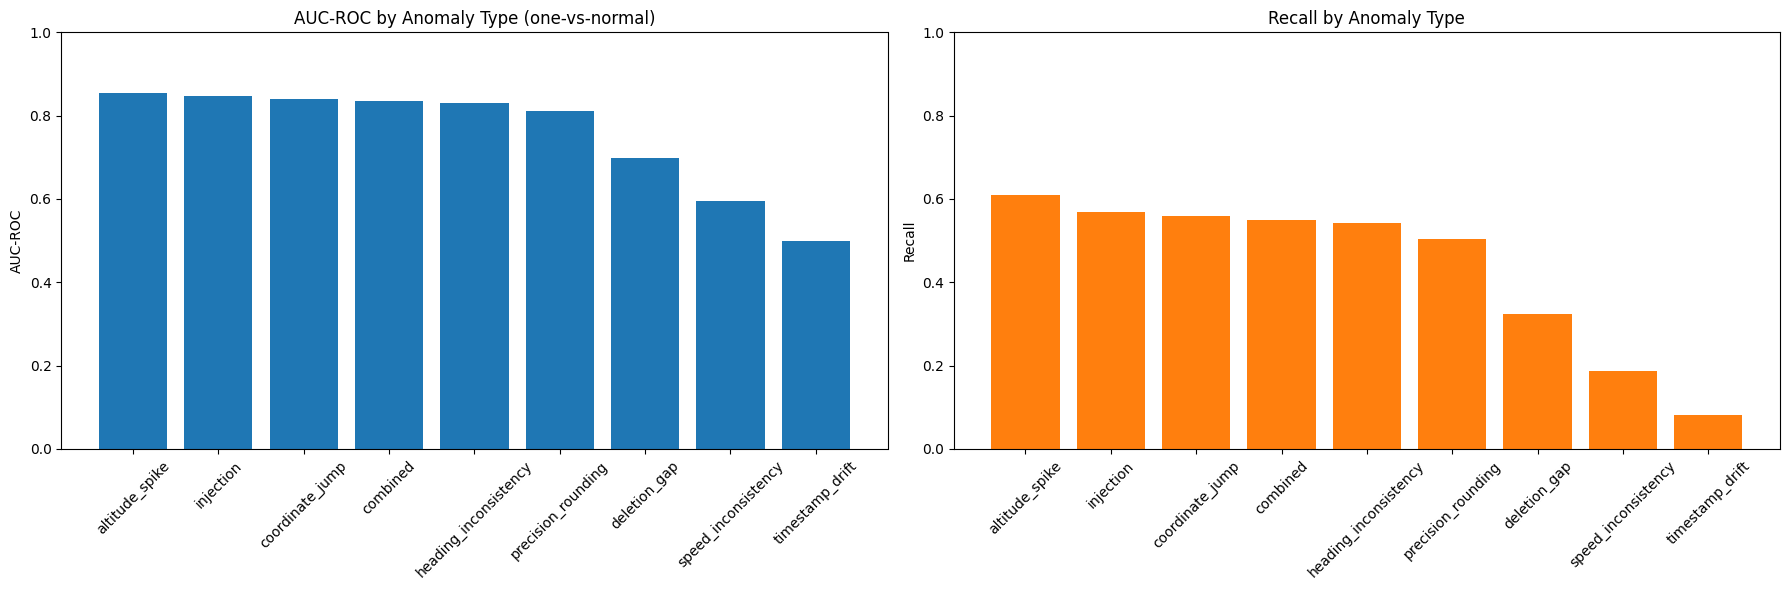

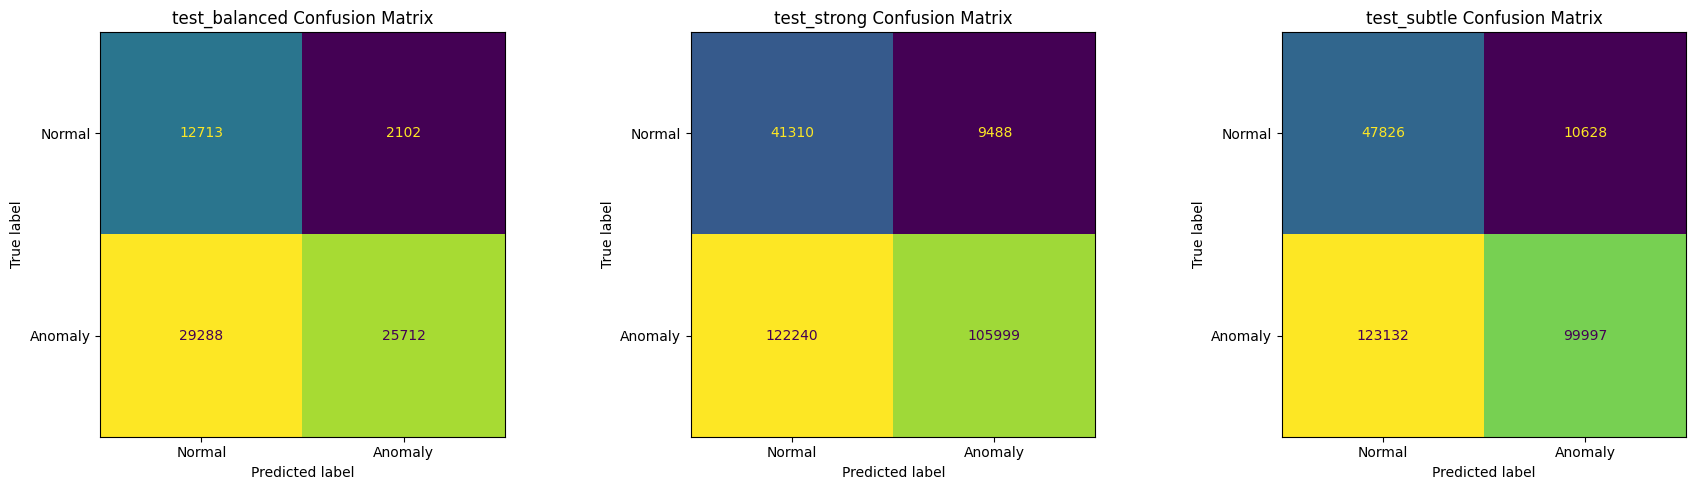

Saved figures:
- /Users/deepank/Downloads/AI-JEPA/outputs/champion_auc_recall_by_anomaly_type.png
- /Users/deepank/Downloads/AI-JEPA/outputs/champion_confusion_matrices_normal_vs_anomaly.png

Confusion matrix arrays:

test_balanced:
[[12713  2102]
 [29288 25712]]

test_strong:
[[ 41310   9488]
 [122240 105999]]

test_subtle:
[[ 47826  10628]
 [123132  99997]]


In [7]:
# 66) Plot + save AUC/Recall and confusion-matrix figures
from pathlib import Path
from sklearn.metrics import ConfusionMatrixDisplay

if "overall_type_df" not in globals() or "confusions" not in globals():
    raise RuntimeError("Run Cell 65 first.")

out_dir = Path(PROJECT_DIR) / "outputs"
out_dir.mkdir(parents=True, exist_ok=True)

plot_df = overall_type_df.sort_values("auc_roc", ascending=False).copy().reset_index(drop=True)

# Figure 1: AUC-ROC + Recall by anomaly type
fig1, axes = plt.subplots(1, 2, figsize=(18, 6))

axes[0].bar(plot_df["anomaly_type"], plot_df["auc_roc"], color="#1f77b4")
axes[0].set_title("AUC-ROC by Anomaly Type (one-vs-normal)")
axes[0].set_ylabel("AUC-ROC")
axes[0].set_ylim(0.0, 1.0)
axes[0].tick_params(axis="x", rotation=45)

axes[1].bar(plot_df["anomaly_type"], plot_df["recall"], color="#ff7f0e")
axes[1].set_title("Recall by Anomaly Type")
axes[1].set_ylabel("Recall")
axes[1].set_ylim(0.0, 1.0)
axes[1].tick_params(axis="x", rotation=45)

fig1.tight_layout()
auc_recall_path = out_dir / "champion_auc_recall_by_anomaly_type.png"
fig1.savefig(auc_recall_path, dpi=300, bbox_inches="tight")
plt.show()

# Figure 2: Confusion matrices (Normal vs Anomaly) per test split
fig2, cm_axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, split in enumerate(["test_balanced", "test_strong", "test_subtle"]):
    cm = confusions[split]
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Anomaly"])
    disp.plot(ax=cm_axes[idx], colorbar=False, values_format="d")
    cm_axes[idx].set_title(f"{split} Confusion Matrix")

fig2.tight_layout()
cm_path = out_dir / "champion_confusion_matrices_normal_vs_anomaly.png"
fig2.savefig(cm_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved figures:")
print(f"- {auc_recall_path}")
print(f"- {cm_path}")

print("\nConfusion matrix arrays:")
for split in ["test_balanced", "test_strong", "test_subtle"]:
    cm = confusions[split]
    print(f"\n{split}:\n{cm}")

Performance metrics by dataset:


,Dataset,AUC-ROC,Recall,F1,FAR
0,validation,0.679856,0.455305,0.607195,0.198802
1,test_balanced,0.733464,0.467491,0.620958,0.141883
2,test_strong,0.695928,0.464421,0.616765,0.186779
3,test_subtle,0.689963,0.448158,0.599226,0.181818


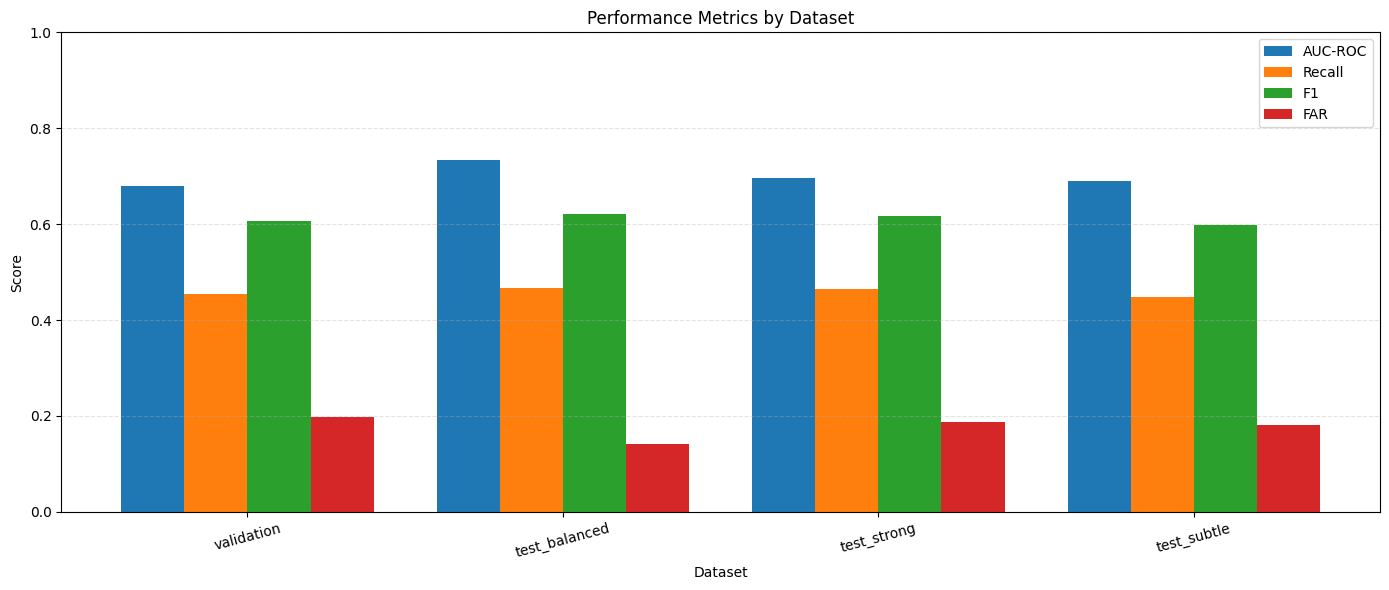

Saved: /Users/deepank/Downloads/AI-JEPA/outputs/champion_performance_metrics_by_dataset.png


In [9]:
# 67) Performance Metrics by Dataset (AUC-ROC, Recall, F1, FAR)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import roc_auc_score, confusion_matrix

required = ["val_lbl", "val_scores", "best_thr", "test_lbls", "split_scores", "split_preds"]
missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError(f"Missing required variables: {missing}. Run Cell 65 first.")

def compute_binary_metrics(y_true, y_pred, scores):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    far = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    auc = roc_auc_score(y_true, scores)
    return {
        "AUC-ROC": float(auc),
        "Recall": float(recall),
        "F1": float(f1),
        "FAR": float(far),
    }

# Validation predictions from calibrated threshold
val_pred = (val_scores >= best_thr).astype(int)

metrics_rows = []
metrics_rows.append({"Dataset": "validation", **compute_binary_metrics(val_lbl, val_pred, val_scores)})
for split in ["test_balanced", "test_strong", "test_subtle"]:
    metrics_rows.append({
        "Dataset": split,
        **compute_binary_metrics(test_lbls[split], split_preds[split], split_scores[split]),
    })

metrics_df = pd.DataFrame(metrics_rows)
print("Performance metrics by dataset:")
display(metrics_df)

# Grouped bar chart
plot_cols = ["AUC-ROC", "Recall", "F1", "FAR"]
x = np.arange(len(metrics_df))
width = 0.2

fig, ax = plt.subplots(figsize=(14, 6))
for i, col in enumerate(plot_cols):
    ax.bar(x + (i - 1.5) * width, metrics_df[col], width, label=col)

ax.set_title("Performance Metrics by Dataset")
ax.set_xlabel("Dataset")
ax.set_ylabel("Score")
ax.set_ylim(0.0, 1.0)
ax.set_xticks(x)
ax.set_xticklabels(metrics_df["Dataset"], rotation=15)
ax.legend(loc="best")
ax.grid(axis="y", linestyle="--", alpha=0.35)

plt.tight_layout()
out_dir = Path(PROJECT_DIR) / "outputs"
out_dir.mkdir(parents=True, exist_ok=True)
perf_plot_path = out_dir / "champion_performance_metrics_by_dataset.png"
fig.savefig(perf_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved: {perf_plot_path}")

/Users/deepank/Downloads/AI-JEPA/.venv/lib/python3.9/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: divide by zero encountered in matmul
  C = X.T @ X
/Users/deepank/Downloads/AI-JEPA/.venv/lib/python3.9/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: overflow encountered in matmul
  C = X.T @ X
/Users/deepank/Downloads/AI-JEPA/.venv/lib/python3.9/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: invalid value encountered in matmul
  C = X.T @ X
/Users/deepank/Downloads/AI-JEPA/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/deepank/Downloads/AI-JEPA/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/deepank/Downloads/AI-JEPA/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWa

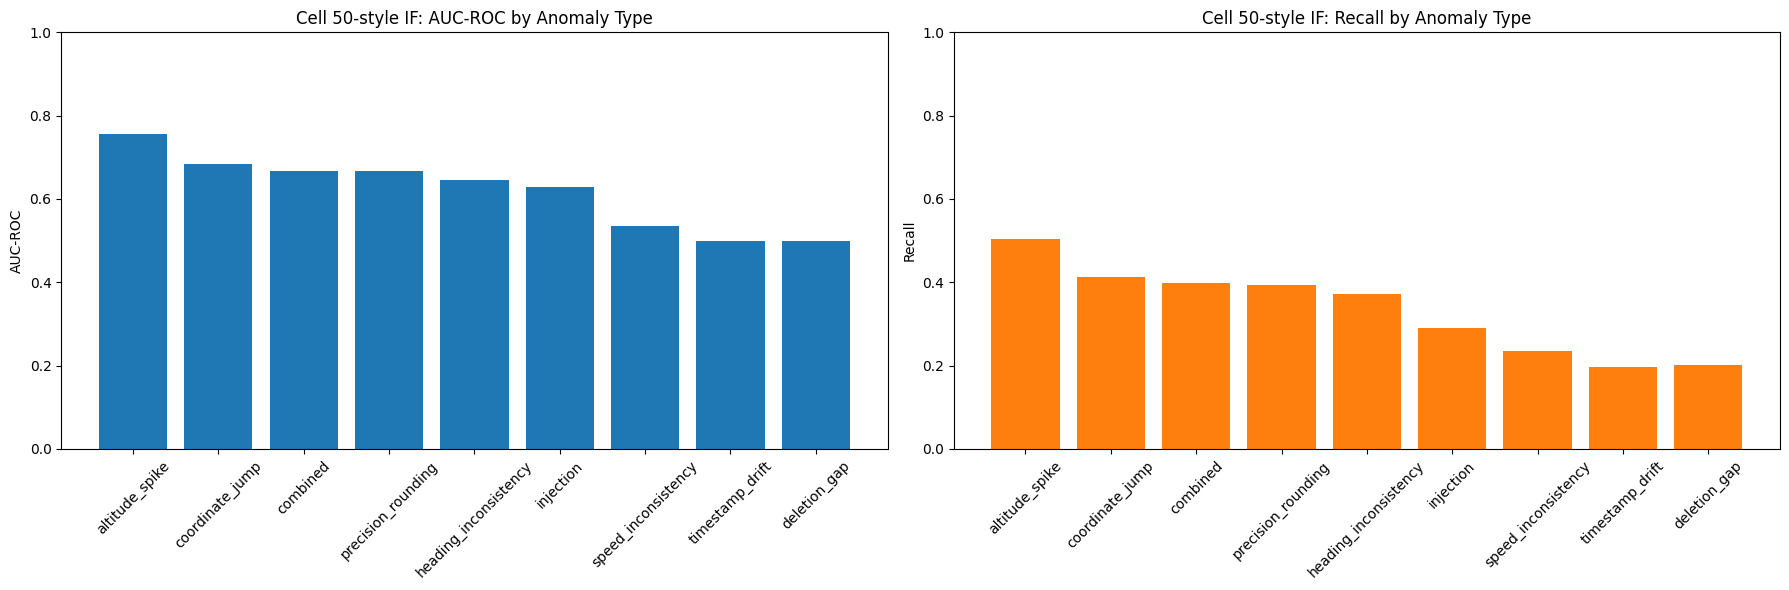

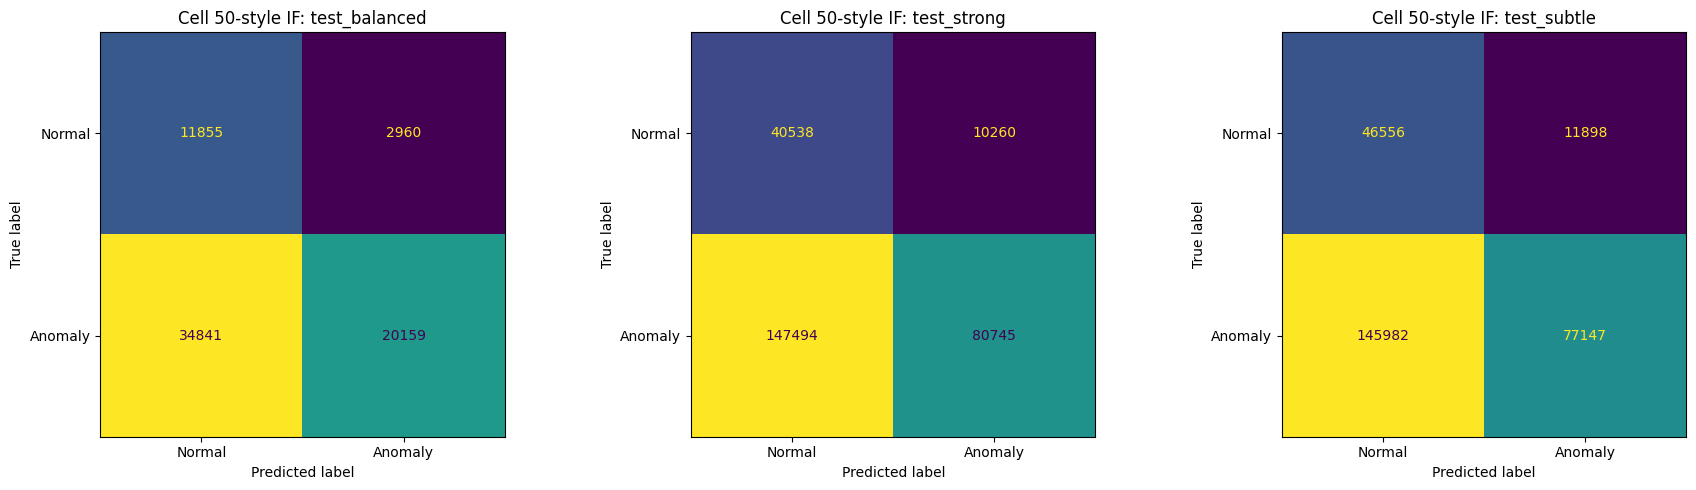

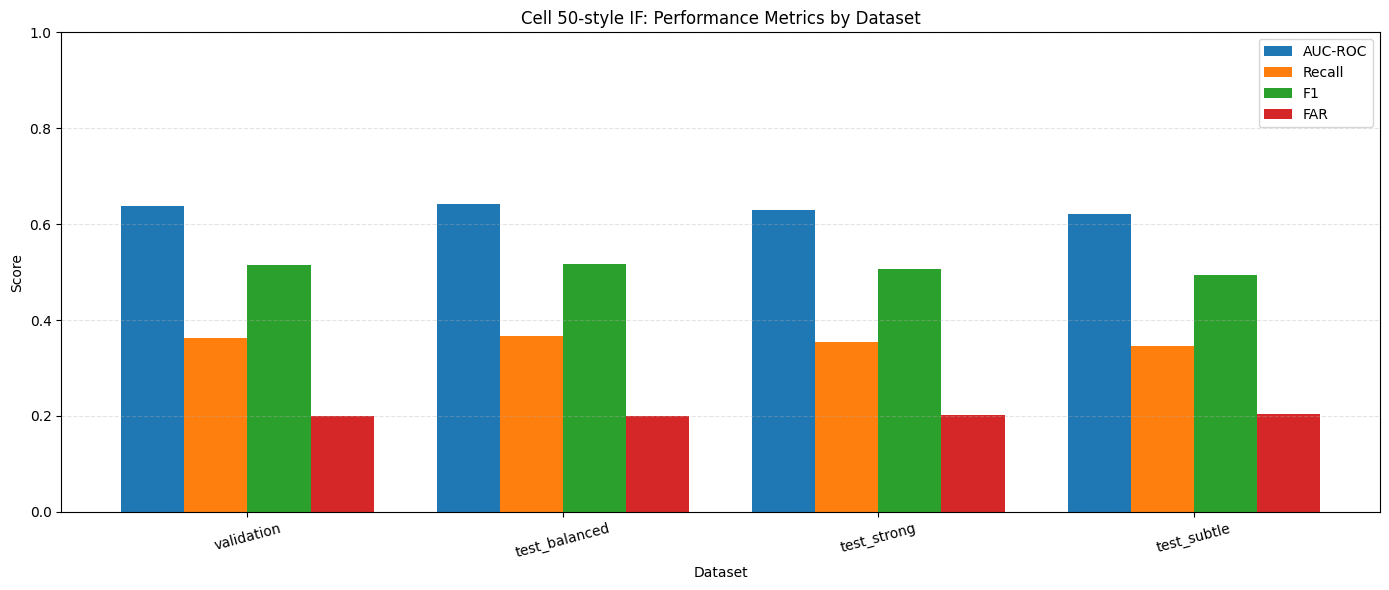

Calibrated threshold (IF): 0.444950

Performance metrics by dataset (Cell 50-style IF):


,Dataset,AUC-ROC,Recall,F1,FAR
0,validation,0.637803,0.362502,0.515315,0.198881
1,test_balanced,0.642187,0.366527,0.516110,0.199798
2,test_strong,0.630061,0.353774,0.505851,0.201976
3,test_subtle,0.622110,0.345751,0.494256,0.203545



Saved baseline graphs:
- /Users/deepank/Downloads/AI-JEPA/outputs/cell50_if_auc_recall_by_anomaly_type.png
- /Users/deepank/Downloads/AI-JEPA/outputs/cell50_if_confusion_matrices_normal_vs_anomaly.png
- /Users/deepank/Downloads/AI-JEPA/outputs/cell50_if_performance_metrics_by_dataset.png

Confusion matrices (Cell 50-style IF):

test_balanced:
[[11855  2960]
 [34841 20159]]

test_strong:
[[ 40538  10260]
 [147494  80745]]

test_subtle:
[[ 46556  11898]
 [145982  77147]]


In [10]:
# 68) Cell 50 baseline-style graphs (IF: pca=160, n_estimators=200, contamination=0.14)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

required = ["train_emb", "val_emb", "val_lbl", "test_embs", "test_lbls", "PROJECT_DIR"]
missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError(f"Missing variables {missing}. Run Cell 65 first.")

# Cell 50 baseline target config from guide
BASE_PCA = 160
BASE_N_EST = 200
BASE_CONT = 0.14
FAR_CAP = 0.20

# Scale + PCA
scaler_if = StandardScaler()
train_s_if = scaler_if.fit_transform(train_emb)
val_s_if = scaler_if.transform(val_emb)
test_s_if = {k: scaler_if.transform(v) for k, v in test_embs.items()}

n_comp_if = min(BASE_PCA, train_s_if.shape[1], train_s_if.shape[0] - 1)
pca_if = PCA(n_components=n_comp_if, random_state=42)
train_t_if = pca_if.fit_transform(train_s_if)
val_t_if = pca_if.transform(val_s_if)
test_t_if = {k: pca_if.transform(v) for k, v in test_s_if.items()}

# Isolation Forest baseline
if_base = IsolationForest(
    n_estimators=BASE_N_EST,
    contamination=BASE_CONT,
    random_state=42,
    n_jobs=-1,
)
if_base.fit(train_t_if)

# Validation threshold calibration (same style as Cell 50)
val_scores_if = -if_base.score_samples(val_t_if)
thr_grid = np.quantile(val_scores_if, np.linspace(0.65, 0.995, 140))


def _bin_metrics(y_true, y_pred, scores):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    far = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    auc = roc_auc_score(y_true, scores)
    return {"auc_roc": float(auc), "recall": float(recall), "f1": float(f1), "far": float(far)}

best_thr_if = None
best_obj_if = -1e9
for thr in thr_grid:
    val_pred_if = (val_scores_if >= thr).astype(int)
    vm = _bin_metrics(val_lbl, val_pred_if, val_scores_if)
    if vm["far"] <= FAR_CAP:
        obj = 2.2 * vm["recall"] + 0.9 * vm["f1"] + 0.4 * vm["auc_roc"]
        if obj > best_obj_if:
            best_obj_if = obj
            best_thr_if = float(thr)

if best_thr_if is None:
    best_thr_if = float(np.quantile(val_scores_if, 0.995))

# Predictions + scores on all splits
splits = ["validation", "test_balanced", "test_strong", "test_subtle"]
baseline_scores = {"validation": val_scores_if}
baseline_preds = {"validation": (val_scores_if >= best_thr_if).astype(int)}

for s in ["test_balanced", "test_strong", "test_subtle"]:
    sc = -if_base.score_samples(test_t_if[s])
    baseline_scores[s] = sc
    baseline_preds[s] = (sc >= best_thr_if).astype(int)

# ---------- Graph A: AUC-ROC / Recall by anomaly type ----------
rows = []
for s in ["test_balanced", "test_strong", "test_subtle"]:
    anom_types = np.load(PROJECT_DIR / "processed_data" / s / "anomaly_types.npy", allow_pickle=True).astype(str)
    y_true_s = test_lbls[s]
    y_pred_s = baseline_preds[s]
    sc_s = baseline_scores[s]

    normal_mask = anom_types == "normal"
    for t in sorted([x for x in np.unique(anom_types) if x != "normal"]):
        t_mask = anom_types == t
        support = int(t_mask.sum())
        recall_t = float((y_pred_s[t_mask] == 1).mean()) if support > 0 else np.nan

        pair_mask = normal_mask | t_mask
        y_bin = (anom_types[pair_mask] == t).astype(int)
        s_bin = sc_s[pair_mask]
        auc_t = float(roc_auc_score(y_bin, s_bin)) if len(np.unique(y_bin)) == 2 else np.nan

        rows.append({"split": s, "anomaly_type": t, "support": support, "auc_roc": auc_t, "recall": recall_t})

per_type_if_df = pd.DataFrame(rows)
overall_rows = []
for t, g in per_type_if_df.groupby("anomaly_type"):
    w = g["support"].to_numpy(dtype=float)
    auc_vals = g["auc_roc"].to_numpy(dtype=float)
    rec_vals = g["recall"].to_numpy(dtype=float)
    w_auc = np.nansum(auc_vals * w) / np.nansum(w) if np.nansum(w) > 0 else np.nan
    w_rec = np.nansum(rec_vals * w) / np.nansum(w) if np.nansum(w) > 0 else np.nan
    overall_rows.append({"anomaly_type": t, "support": int(np.nansum(w)), "auc_roc": w_auc, "recall": w_rec})

overall_if_df = pd.DataFrame(overall_rows).sort_values("auc_roc", ascending=False)

fig_a, ax_a = plt.subplots(1, 2, figsize=(18, 6))
ax_a[0].bar(overall_if_df["anomaly_type"], overall_if_df["auc_roc"], color="#1f77b4")
ax_a[0].set_title("Cell 50-style IF: AUC-ROC by Anomaly Type")
ax_a[0].set_ylabel("AUC-ROC")
ax_a[0].set_ylim(0, 1)
ax_a[0].tick_params(axis="x", rotation=45)

ax_a[1].bar(overall_if_df["anomaly_type"], overall_if_df["recall"], color="#ff7f0e")
ax_a[1].set_title("Cell 50-style IF: Recall by Anomaly Type")
ax_a[1].set_ylabel("Recall")
ax_a[1].set_ylim(0, 1)
ax_a[1].tick_params(axis="x", rotation=45)

fig_a.tight_layout()

# ---------- Graph B: Confusion matrices ----------
fig_b, cm_axes = plt.subplots(1, 3, figsize=(18, 5))
cm_map_if = {}
for i, s in enumerate(["test_balanced", "test_strong", "test_subtle"]):
    cm = confusion_matrix(test_lbls[s], baseline_preds[s], labels=[0, 1])
    cm_map_if[s] = cm
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Anomaly"])
    disp.plot(ax=cm_axes[i], colorbar=False, values_format="d")
    cm_axes[i].set_title(f"Cell 50-style IF: {s}")
fig_b.tight_layout()

# ---------- Graph C: Performance metrics by dataset ----------
def _row(ds, y_true, y_pred, sc):
    m = _bin_metrics(y_true, y_pred, sc)
    return {"Dataset": ds, "AUC-ROC": m["auc_roc"], "Recall": m["recall"], "F1": m["f1"], "FAR": m["far"]}

metrics_if_df = pd.DataFrame([
    _row("validation", val_lbl, baseline_preds["validation"], baseline_scores["validation"]),
    _row("test_balanced", test_lbls["test_balanced"], baseline_preds["test_balanced"], baseline_scores["test_balanced"]),
    _row("test_strong", test_lbls["test_strong"], baseline_preds["test_strong"], baseline_scores["test_strong"]),
    _row("test_subtle", test_lbls["test_subtle"], baseline_preds["test_subtle"], baseline_scores["test_subtle"]),
])

fig_c, ax_c = plt.subplots(figsize=(14, 6))
plot_cols = ["AUC-ROC", "Recall", "F1", "FAR"]
x = np.arange(len(metrics_if_df))
width = 0.2
for i, col in enumerate(plot_cols):
    ax_c.bar(x + (i - 1.5) * width, metrics_if_df[col], width, label=col)
ax_c.set_title("Cell 50-style IF: Performance Metrics by Dataset")
ax_c.set_xlabel("Dataset")
ax_c.set_ylabel("Score")
ax_c.set_ylim(0, 1)
ax_c.set_xticks(x)
ax_c.set_xticklabels(metrics_if_df["Dataset"], rotation=15)
ax_c.legend(loc="best")
ax_c.grid(axis="y", linestyle="--", alpha=0.35)
fig_c.tight_layout()

# Save all graphs
out_dir = Path(PROJECT_DIR) / "outputs"
out_dir.mkdir(parents=True, exist_ok=True)
if_auc_recall_path = out_dir / "cell50_if_auc_recall_by_anomaly_type.png"
if_cm_path = out_dir / "cell50_if_confusion_matrices_normal_vs_anomaly.png"
if_metrics_path = out_dir / "cell50_if_performance_metrics_by_dataset.png"

fig_a.savefig(if_auc_recall_path, dpi=300, bbox_inches="tight")
fig_b.savefig(if_cm_path, dpi=300, bbox_inches="tight")
fig_c.savefig(if_metrics_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Calibrated threshold (IF): {best_thr_if:.6f}")
print("\nPerformance metrics by dataset (Cell 50-style IF):")
display(metrics_if_df)

print("\nSaved baseline graphs:")
print(f"- {if_auc_recall_path}")
print(f"- {if_cm_path}")
print(f"- {if_metrics_path}")

print("\nConfusion matrices (Cell 50-style IF):")
for s in ["test_balanced", "test_strong", "test_subtle"]:
    print(f"\n{s}:\n{cm_map_if[s]}")

/Users/deepank/Downloads/AI-JEPA/.venv/lib/python3.9/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: divide by zero encountered in matmul
  C = X.T @ X
/Users/deepank/Downloads/AI-JEPA/.venv/lib/python3.9/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: overflow encountered in matmul
  C = X.T @ X
/Users/deepank/Downloads/AI-JEPA/.venv/lib/python3.9/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: invalid value encountered in matmul
  C = X.T @ X
/Users/deepank/Downloads/AI-JEPA/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/deepank/Downloads/AI-JEPA/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/deepank/Downloads/AI-JEPA/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWa

test_strong metrics across experiment variants:


,Variant,AUC,Recall,F1,FAR,threshold
0,Isolation Forest Baseline,0.630061,0.353279,0.505329,0.201898,0.445078
1,LOF Euclidean (Initial),0.684121,0.436411,0.591255,0.178865,1.235232
2,LOF Euclidean (v1 Tuned),0.683685,0.436748,0.591494,0.179791,1.233052
3,LOF Manhattan (Final Champion),0.695928,0.464421,0.616765,0.186779,1.230198


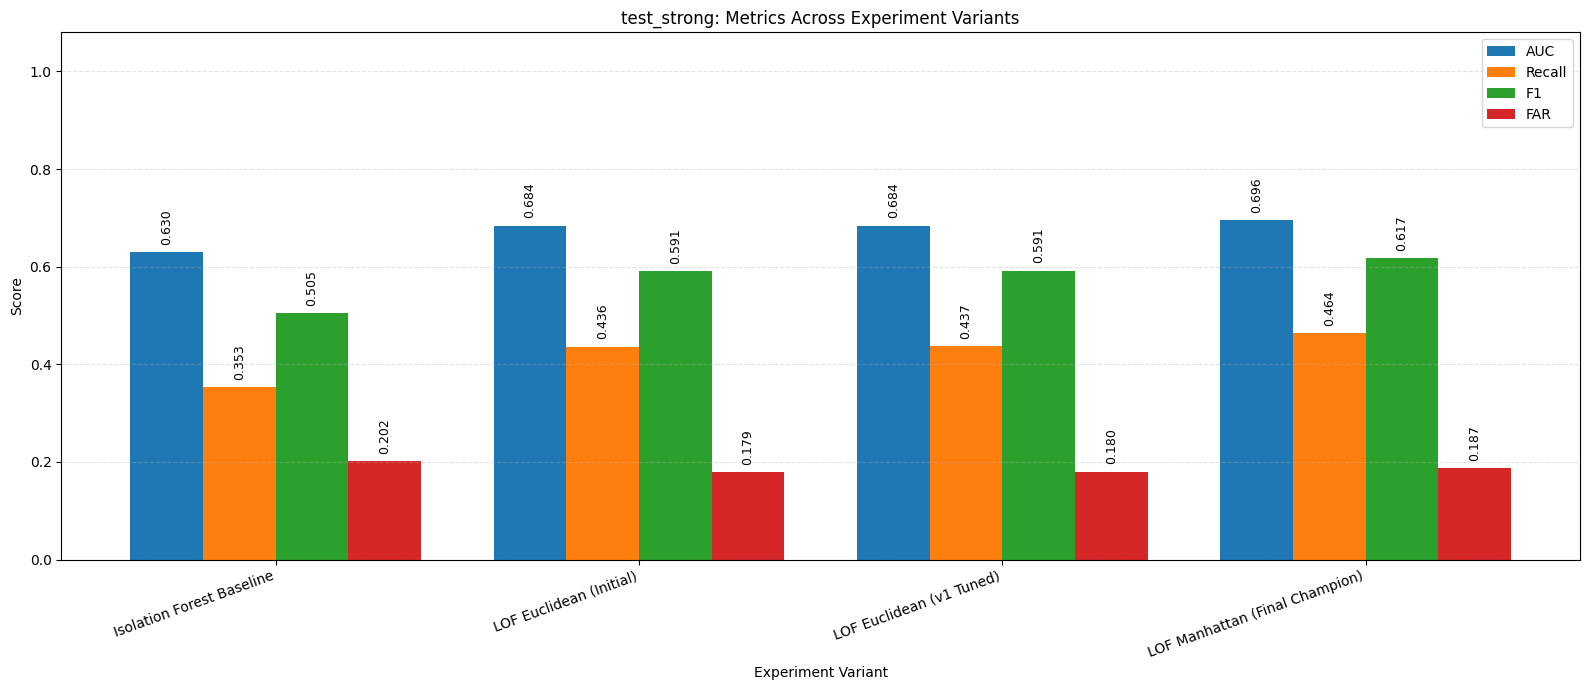

Saved: /Users/deepank/Downloads/AI-JEPA/outputs/final_experiment_variants_test_strong_metrics.png


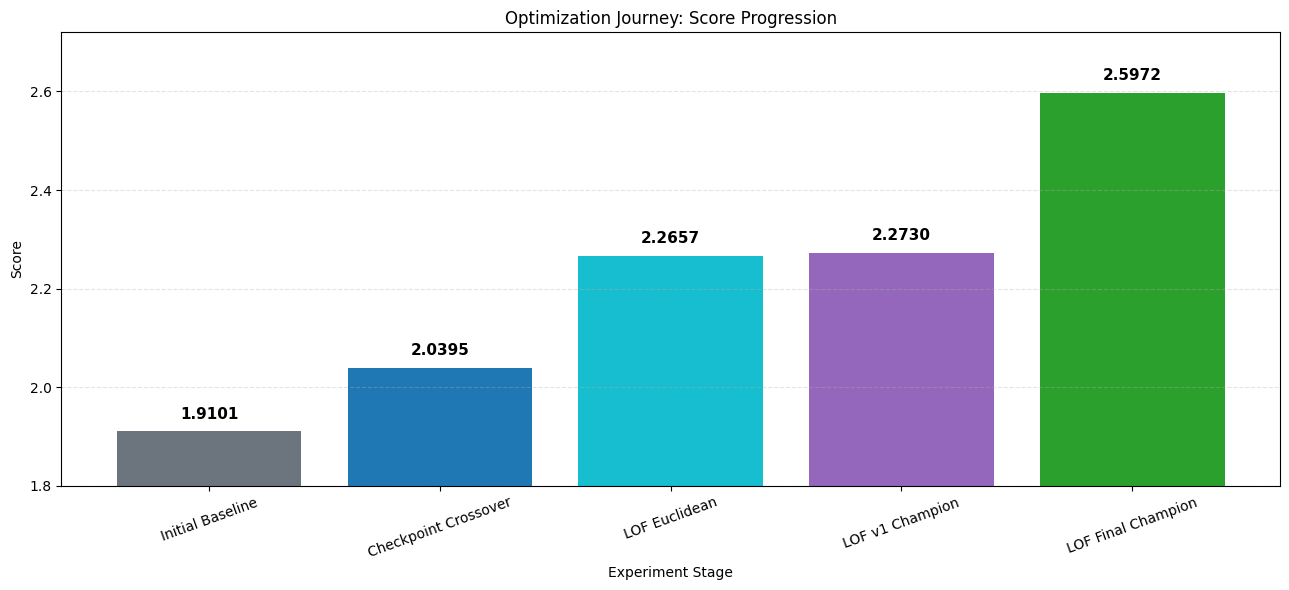

Saved: /Users/deepank/Downloads/AI-JEPA/outputs/final_score_progression_with_values.png


In [13]:
# 69) Test-strong comparison: all major experiment variants tried (+ score progression bars for presentation)

import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.ensemble import IsolationForest

from sklearn.neighbors import LocalOutlierFactor

from sklearn.preprocessing import StandardScaler

from sklearn.decomposition import PCA

from sklearn.metrics import roc_auc_score, confusion_matrix



required = ["train_emb", "val_emb", "val_lbl", "test_embs", "test_lbls", "PROJECT_DIR"]

missing = [name for name in required if name not in globals()]

if missing:

    raise RuntimeError(f"Missing variables {missing}. Run Cell 65 first.")



FAR_CAP = 0.20

SEED = 42





def _metrics(y_true, y_pred, scores):

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0

    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

    far = fp / (fp + tn) if (fp + tn) > 0 else 0.0

    auc = roc_auc_score(y_true, scores)

    return {"AUC": float(auc), "Recall": float(recall), "F1": float(f1), "FAR": float(far)}





def _calibrate_threshold(y_val, val_scores, kind="lof"):

    thr_grid = np.quantile(val_scores, np.linspace(0.55, 0.998, 260))

    best_thr, best_obj = None, -1e9

    for thr in thr_grid:

        pred = (val_scores >= thr).astype(int)

        m = _metrics(y_val, pred, val_scores)

        if m["FAR"] <= FAR_CAP:

            if kind == "if":

                obj = 2.2 * m["Recall"] + 0.9 * m["F1"] + 0.4 * m["AUC"]

            else:

                obj = 2.5 * m["Recall"] + 1.0 * m["F1"] + 0.25 * m["AUC"]

            if obj > best_obj:

                best_obj = obj

                best_thr = float(thr)

    if best_thr is None:

        best_thr = float(np.quantile(val_scores, 0.995))

    return best_thr





def _evaluate_variant(variant):

    scaler = StandardScaler()

    train_s = scaler.fit_transform(train_emb)

    val_s = scaler.transform(val_emb)

    test_s = scaler.transform(test_embs["test_strong"])



    pca_dim = variant["pca"]

    n_comp = min(pca_dim, train_s.shape[1], train_s.shape[0] - 1)

    pca = PCA(n_components=n_comp, random_state=SEED)

    train_t = pca.fit_transform(train_s)

    val_t = pca.transform(val_s)

    test_t = pca.transform(test_s)



    if variant["type"] == "iforest":

        det = IsolationForest(

            n_estimators=variant["n_estimators"],

            contamination=variant["contamination"],

            random_state=SEED,

            n_jobs=-1,

        )

        det.fit(train_t)

        val_scores = -det.score_samples(val_t)

        thr = _calibrate_threshold(val_lbl, val_scores, kind="if")

        test_scores = -det.score_samples(test_t)

    else:

        det = LocalOutlierFactor(

            n_neighbors=min(variant["k"], len(train_t) - 1),

            metric=variant["metric"],

            novelty=True,

        )

        det.fit(train_t)

        val_scores = -det.score_samples(val_t)

        thr = _calibrate_threshold(val_lbl, val_scores, kind="lof")

        test_scores = -det.score_samples(test_t)



    test_pred = (test_scores >= thr).astype(int)

    m = _metrics(test_lbls["test_strong"], test_pred, test_scores)

    m["Variant"] = variant["name"]

    m["threshold"] = float(thr)

    return m



# Major variants from optimization journey (clean names, no cell numbers)

variants = [

    {

        "name": "Isolation Forest Baseline",

        "type": "iforest",

        "pca": 160,

        "n_estimators": 200,

        "contamination": 0.14,

    },

    {

        "name": "LOF Euclidean (Initial)",

        "type": "lof",

        "pca": 160,

        "k": 20,

        "metric": "euclidean",

    },

    {

        "name": "LOF Euclidean (v1 Tuned)",

        "type": "lof",

        "pca": 128,

        "k": 20,

        "metric": "euclidean",

    },

    {

        "name": "LOF Manhattan (Final Champion)",

        "type": "lof",

        "pca": 124,

        "k": 22,

        "metric": "manhattan",

    },

]



rows = [_evaluate_variant(v) for v in variants]

variants_strong_df = pd.DataFrame(rows)



print("test_strong metrics across experiment variants:")

display(variants_strong_df[["Variant", "AUC", "Recall", "F1", "FAR", "threshold"]])



# Plot 1: test_strong metric comparison with value labels

plot_cols = ["AUC", "Recall", "F1", "FAR"]

x = np.arange(len(variants_strong_df))

width = 0.2



fig, ax = plt.subplots(figsize=(16, 7))

for i, col in enumerate(plot_cols):

    offsets = x + (i - 1.5) * width

    bars = ax.bar(offsets, variants_strong_df[col], width, label=col)

    for b in bars:

        h = b.get_height()

        ax.text(

            b.get_x() + b.get_width() / 2,

            h + 0.015,

            f"{h:.3f}",

            ha="center",

            va="bottom",

            fontsize=9,

            rotation=90,

        )



ax.set_title("test_strong: Metrics Across Experiment Variants")

ax.set_xlabel("Experiment Variant")

ax.set_ylabel("Score")

ax.set_ylim(0.0, 1.08)

ax.set_xticks(x)

ax.set_xticklabels(variants_strong_df["Variant"], rotation=20, ha="right")

ax.grid(axis="y", linestyle="--", alpha=0.35)

ax.legend(loc="best")

fig.tight_layout()



out_dir = Path(PROJECT_DIR) / "outputs"

out_dir.mkdir(parents=True, exist_ok=True)

variants_plot_path = out_dir / "final_experiment_variants_test_strong_metrics.png"

fig.savefig(variants_plot_path, dpi=300, bbox_inches="tight")



plt.show()

print(f"Saved: {variants_plot_path}")



# Plot 2: Optimization score progression (includes initial baseline 1.9101)

score_labels = [

    "Initial Baseline",

    "Checkpoint Crossover",

    "LOF Euclidean",

    "LOF v1 Champion",

    "LOF Final Champion",

]

score_values = [1.9101, 2.0395, 2.2657, 2.2730, 2.5972]



fig2, ax2 = plt.subplots(figsize=(13, 6))

bars2 = ax2.bar(score_labels, score_values, color=["#6c757d", "#1f77b4", "#17becf", "#9467bd", "#2ca02c"])



for b, v in zip(bars2, score_values):

    ax2.text(

        b.get_x() + b.get_width() / 2,

        v + 0.02,

        f"{v:.4f}",

        ha="center",

        va="bottom",

        fontsize=11,

        fontweight="bold",

    )



ax2.set_title("Optimization Journey: Score Progression")

ax2.set_xlabel("Experiment Stage")

ax2.set_ylabel("Score")

ax2.set_ylim(1.8, 2.72)

ax2.grid(axis="y", linestyle="--", alpha=0.35)

ax2.tick_params(axis="x", rotation=20)

fig2.tight_layout()



score_plot_path = out_dir / "final_score_progression_with_values.png"

fig2.savefig(score_plot_path, dpi=300, bbox_inches="tight")



plt.show()

print(f"Saved: {score_plot_path}")


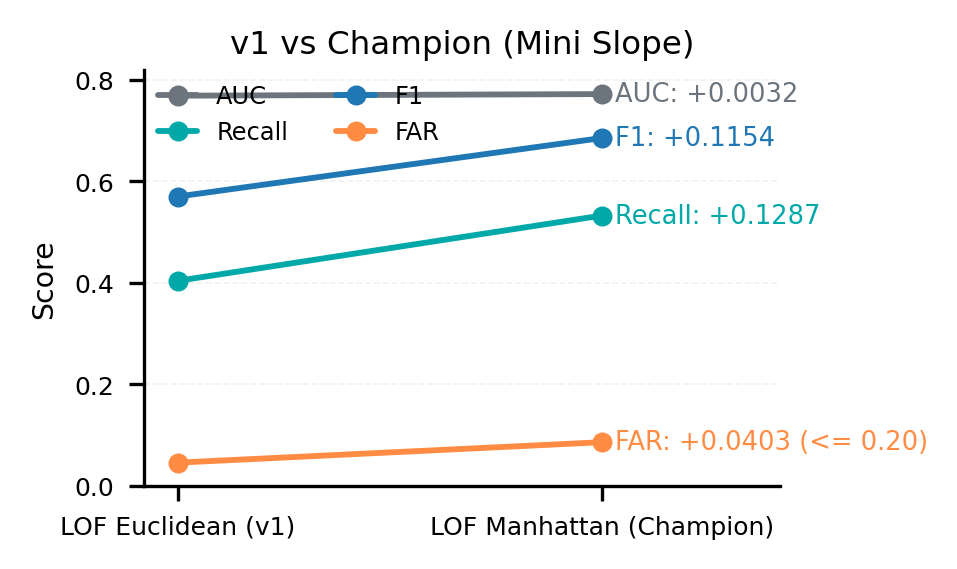

Saved: /Users/deepank/Downloads/AI-JEPA/outputs/mini_slope_lof_v1_vs_champion.png


In [14]:
# 70) Mini slope chart: LOF Euclidean (v1) vs LOF Manhattan (Champion)

import matplotlib.pyplot as plt

from pathlib import Path



if "PROJECT_DIR" not in globals():

    raise RuntimeError("Missing PROJECT_DIR. Run earlier setup cells first.")



# Exact values requested

points = ["LOF Euclidean (v1)", "LOF Manhattan (Champion)"]

metrics = {

    "AUC": {"before": 0.7687, "after": 0.7719, "color": "#6c757d"},

    "Recall": {"before": 0.4039, "after": 0.5326, "color": "#00a8a8"},

    "F1": {"before": 0.5700, "after": 0.6854, "color": "#1f77b4"},

    "FAR": {"before": 0.0457, "after": 0.0860, "color": "#ff8c42"},

}



fig, ax = plt.subplots(figsize=(3.2, 2.0), dpi=300)

x = [0, 1]



for name, d in metrics.items():

    y = [d["before"], d["after"]]

    delta = d["after"] - d["before"]

    ax.plot(

        x,

        y,

        color=d["color"],

        linewidth=1.4,

        marker="o",

        markersize=3.8,

        solid_capstyle="round",

        label=name,

    )



    # Right-side delta annotation

    if name == "FAR":

        label = f"{name}: +{delta:.4f} (<= 0.20)"

    else:

        label = f"{name}: +{delta:.4f}"



    ax.text(

        1.03,

        d["after"],

        label,

        color=d["color"],

        fontsize=6.2,

        va="center",

        ha="left",

    )



# Compact styling (clean/premium)

ax.set_xlim(-0.08, 1.42)

ax.set_ylim(0.00, 0.82)

ax.set_xticks(x)

ax.set_xticklabels(points, fontsize=6.2)

ax.set_ylabel("Score", fontsize=6.8)

ax.set_title("v1 vs Champion (Mini Slope)", fontsize=7.8, pad=4)

ax.grid(axis="y", linestyle="--", linewidth=0.4, alpha=0.18)

ax.tick_params(axis="y", labelsize=6.0)

ax.tick_params(axis="x", labelsize=6.0)

ax.spines["top"].set_visible(False)

ax.spines["right"].set_visible(False)



# Minimal legend for line identity

ax.legend(

    loc="upper left",

    fontsize=5.8,

    frameon=False,

    ncol=2,

    handlelength=1.6,

    borderaxespad=0.2,

)



fig.tight_layout()



out_dir = Path(PROJECT_DIR) / "outputs"

out_dir.mkdir(parents=True, exist_ok=True)

mini_slope_path = out_dir / "mini_slope_lof_v1_vs_champion.png"

fig.savefig(mini_slope_path, dpi=300, bbox_inches="tight")



plt.show()

print(f"Saved: {mini_slope_path}")